<a href="https://colab.research.google.com/github/Rosette28/data-science-cyber-final-project/blob/main/notebooks/ids_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Network Intrusion Detection — Progressive Dataset Evaluation

**Paper:** Chua & Salam (2023), *Evaluation of ML Algorithms in Network-Based Intrusion Detection Using Progressive Dataset*, Symmetry 15, 1251

**Setup:** Run this header cell first every time you open a new Colab session.

In [61]:
# ── Header cell: run this first in every new Colab session ──────────────────
import sys, os

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Clone repo so src/ modules are importable
REPO_URL = 'https://github.com/Rosette28/data-science-cyber-final-project'  # ← update
REPO_DIR = '/content/ids-project'
if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    !git -C {REPO_DIR} pull
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
# Also add src/ so bare imports (import models, import preprocessing) work
if os.path.join(REPO_DIR, 'src') not in sys.path:
    sys.path.insert(0, os.path.join(REPO_DIR, 'src'))

# 3. Install dependencies
!pip install -q -r {REPO_DIR}/requirements.txt

print('Environment ready.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already up to date.
Environment ready.


In [62]:
# ── Global configuration — only line you change between runs ─────────────────
DATA_DIR = '/content/drive/MyDrive/ids_data/raw/'  # ← set to your Drive folder

SEED = 42
SUBSAMPLE_FRAC = 0.10  # 10% of each day's CSV, read at load time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import dump, load

np.random.seed(SEED)
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', palette='tab10')

print(f'DATA_DIR = {DATA_DIR}')

DATA_DIR = /content/drive/MyDrive/ids_data/raw/


---
## §1 — Data Loading & Initial Inspection

Load CIC-IDS2017 (train) and CSE-CIC-IDS2018 (progressive test), keeping ~10% via chunked reading. Inspect shape, dtypes, memory usage, column names, and temporal structure.

In [63]:
from src.data_loading import load_cic2017, load_cic2018, align_schemas

df_train = load_cic2017(DATA_DIR, subsample_frac=SUBSAMPLE_FRAC, seed=SEED)
df_test  = load_cic2018(DATA_DIR, subsample_frac=SUBSAMPLE_FRAC, seed=SEED)
df_train, df_test = align_schemas(df_train, df_test)

print('Train shape:', df_train.shape)
print('Test  shape:', df_test.shape)

Found 8 CSV file(s) in /content/drive/MyDrive/ids_data/raw/cic2017
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: 22,356 rows sampled
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: 28,464 rows sampled
  Friday-WorkingHours-Morning.pcap_ISCX.csv: 18,954 rows sampled
  Monday-WorkingHours.pcap_ISCX.csv: 52,870 rows sampled
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: 28,676 rows sampled
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: 16,932 rows sampled
  Tuesday-WorkingHours.pcap_ISCX.csv: 44,445 rows sampled
  Wednesday-workingHours.pcap_ISCX.csv: 69,032 rows sampled
  Dropped 295 rows with inf/NaN (0.10%)
CIC-IDS2017 loaded: 281,434 rows × 78 cols
Found 1 CSV file(s) in /content/drive/MyDrive/ids_data/raw/cic2018
  cleaned_ids2018_sampled.csv: 124,696 rows sampled
CSE-CIC-IDS2018 loaded: 124,696 rows × 77 cols
Columns only in train (dropped): ['Down/Up Ratio']
Train shape: (281434, 77)
Test  shape: (124696, 77)


### Shape, dtypes, memory, and column name inspection

In [64]:
# ── Shape and memory ──────────────────────────────────────────────────────────
for name, df in [('Train (CIC-IDS2017)', df_train), ('Test  (CSE-CIC-IDS2018)', df_test)]:
    mem_mb = df.memory_usage(deep=True).sum() / 1e6
    print(f"{name}: {df.shape[0]:>7,} rows × {df.shape[1]} cols  |  {mem_mb:.1f} MB")

print()

# ── Dtype breakdown ───────────────────────────────────────────────────────────
print("Train dtype counts:")
print(df_train.dtypes.value_counts().to_string())
print("\nTest dtype counts:")
print(df_test.dtypes.value_counts().to_string())

Train (CIC-IDS2017): 281,434 rows × 77 cols  |  159.7 MB
Test  (CSE-CIC-IDS2018): 124,696 rows × 77 cols  |  70.9 MB

Train dtype counts:
int64      52
float32    24
object      1

Test dtype counts:
int64      52
float32    24
object      1


In [65]:
# ── Column name analysis ──────────────────────────────────────────────────────
# Features fall into five semantic groups derived from CICFlowMeter's documentation.
feature_groups = {
    'Packet length stats':    [c for c in df_train.columns if 'Packet Length' in c or 'Pkt Len' in c or 'Packet Size' in c or 'Segment Size' in c],
    'Packet counts / rates':  [c for c in df_train.columns if 'Packets' in c or 'Pkts' in c or 'Bytes' in c or 'Bulk' in c or 'Subflow' in c],
    'Inter-arrival times':    [c for c in df_train.columns if 'IAT' in c or 'Flow Duration' in c],
    'TCP flags':              [c for c in df_train.columns if 'Flag' in c or 'Win' in c],
    'Other / port / misc':    [c for c in df_train.columns if c not in sum([
        [c for c in df_train.columns if 'Packet Length' in c or 'Pkt Len' in c or 'Packet Size' in c or 'Segment Size' in c],
        [c for c in df_train.columns if 'Packets' in c or 'Pkts' in c or 'Bytes' in c or 'Bulk' in c or 'Subflow' in c],
        [c for c in df_train.columns if 'IAT' in c or 'Flow Duration' in c],
        [c for c in df_train.columns if 'Flag' in c or 'Win' in c],
        ['Label']
    ], []) and c != 'Label'],
}

print("Feature groups (76 features total after schema alignment):\n")
for group, cols in feature_groups.items():
    print(f"  {group} ({len(cols)}): {cols}")

print(f"\nLabel column: 'Label' — unique values in train: {df_train['Label'].unique()}")
print(f"                       — unique values in test:  {df_test['Label'].unique()}")

Feature groups (76 features total after schema alignment):

  Packet length stats (16): ['Average Packet Size', 'Avg Bwd Segment Size', 'Avg Fwd Segment Size', 'Bwd Packet Length Max', 'Bwd Packet Length Mean', 'Bwd Packet Length Min', 'Bwd Packet Length Std', 'Fwd Packet Length Max', 'Fwd Packet Length Mean', 'Fwd Packet Length Min', 'Fwd Packet Length Std', 'Max Packet Length', 'Min Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance']
  Packet counts / rates (18): ['Bwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Packets/s', 'Flow Bytes/s', 'Flow Packets/s', 'Fwd Avg Bulk Rate', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Packets/s', 'Subflow Bwd Bytes', 'Subflow Bwd Packets', 'Subflow Fwd Bytes', 'Subflow Fwd Packets', 'Total Backward Packets', 'Total Fwd Packets', 'Total Length of Bwd Packets', 'Total Length of Fwd Packets']
  Inter-arrival times (15): ['Bwd IAT Max', 'Bwd IAT Mean', 'Bwd IAT Min', 'Bwd IAT Std', 'Bwd IA

**Shape and memory** (after load + schema alignment, before deduplication):
- Train (CIC-IDS2017, 10% sample): ~281k rows × 77 cols, ~160 MB
- Test (CSE-CIC-IDS2018, 10% sample): ~125k rows × 77 cols, ~71 MB
- After hygiene cleaning (§1.3): **266,739 × 67 train / 106,906 × 67 test, 66 features**
- Both sets fit comfortably in free Colab RAM (~12 GB limit).

**Dtypes:** 52 `int64` (flag counts, raw packet/byte totals) · 24 `float32` (rates, means, stds — downcast from float64 to halve memory) · 1 `object` (Label).

**66 features across 5 semantic groups:**
- **Packet length stats:** min/max/mean/std of forward and backward packet sizes. Captures *what is being sent* — flooding attacks use fixed-size packets; exfiltration sends large payloads.
- **Packet counts / byte rates:** total packet counts, flow rates (bytes/s, packets/s), subflow counts. Captures *volume and asymmetry* — DoS shows extreme forward rate with near-zero backward.
- **Inter-arrival times (IAT):** min/max/mean/std of gaps between packets, plus Flow Duration. Captures *timing* — scans and floods have unusually small or regular IATs.
- **TCP flags:** SYN/FIN/RST/PSH/ACK/URG/ECE counts, initial TCP window sizes. Captures *connection behaviour* — SYN without ACK = SYN flood; window size fingerprints OS and botnet clients.
- **Other:** destination port, header lengths, active/idle time stats. Port alone is a strong discriminator — scanning generates traffic across unusual high ports.

**Labels:** 15 attack types + BENIGN in train; 10 attack types + BENIGN in test (2018 used integer encoding; 2017 had UTF-8 artifacts in Web Attack labels — both fixed at load time).

**Timestamp excluded from features:** Including raw calendar timestamps would cause time leakage ('2017 flow = benign, 2018 flow = attack'). IAT and Duration capture structural flow timing, not calendar position.


### Index sanity check

In [66]:
# ── Does the index make sense? ────────────────────────────────────────────────
for name, df in [('Train (CIC-IDS2017)', df_train), ('Test (CSE-CIC-IDS2018)', df_test)]:
    print(f"{name}: index name={df.index.name!r}, dtype={df.index.dtype}, "
          f"unique={df.index.is_unique}, monotonic={df.index.is_monotonic_increasing}, "
          f"range=[{df.index.min()}, {df.index.max()}], length={len(df.index):,}")

Train (CIC-IDS2017): index name=None, dtype=int64, unique=True, monotonic=True, range=[0, 281433], length=281,434
Test (CSE-CIC-IDS2018): index name=None, dtype=int64, unique=True, monotonic=True, range=[0, 124695], length=124,696


**Does the index make sense?** Both DataFrames use pandas' default unnamed integer
`RangeIndex` (0..N−1) rather than any column from the source CSVs. This is the correct choice
here: the raw CICFlowMeter output for this dataset carries no natural unique row identifier (no
`Flow ID` survived in this pre-processed file — confirmed later in the hygiene scan below), so a
plain positional index is appropriate and there is nothing more meaningful to index on. The
index is unique and strictly increasing in both frames, which confirms `pd.concat` across the
per-day CSV files (§1's temporal-structure section) did not silently duplicate or reorder rows —
a real risk when concatenating multiple daily files with their own independent 0-based indices.

### Temporal structure and the progressive evaluation design

In [67]:
import os, glob

# ── Per-day file breakdown for CIC-IDS2017 ────────────────────────────────────
cic2017_dir = os.path.join(DATA_DIR, 'cic2017')
cic2018_dir = os.path.join(DATA_DIR, 'cic2018')

print("CIC-IDS2017 source files (training set):")
for f in sorted(glob.glob(os.path.join(cic2017_dir, '*.csv'))):
    print(f"  {os.path.basename(f)}")

print("\nCSE-CIC-IDS2018 source files (progressive test set):")
for f in sorted(glob.glob(os.path.join(cic2018_dir, '*.csv'))):
    print(f"  {os.path.basename(f)}")

CIC-IDS2017 source files (training set):
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  Friday-WorkingHours-Morning.pcap_ISCX.csv
  Monday-WorkingHours.pcap_ISCX.csv
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  Tuesday-WorkingHours.pcap_ISCX.csv
  Wednesday-workingHours.pcap_ISCX.csv

CSE-CIC-IDS2018 source files (progressive test set):
  cleaned_ids2018_sampled.csv


In [68]:
# ── Attack type label distribution in each dataset ───────────────────────────
print("Attack types in TRAINING set (CIC-IDS2017):")
print(df_train['Label'].value_counts().to_string())

print("\nAttack types in TEST set (CSE-CIC-IDS2018):")
print(df_test['Label'].value_counts().to_string())

Attack types in TRAINING set (CIC-IDS2017):
Label
BENIGN                        226117
DoS Hulk                       22944
PortScan                       15788
DDoS                           12732
DoS GoldenEye                    952
FTP-Patator                      784
DoS slowloris                    595
SSH-Patator                      578
DoS Slowhttptest                 516
Bot                              199
Web Attack - Brute Force         150
Web Attack - XSS                  70
Infiltration                       6
Web Attack - Sql Injection         2
Heartbleed                         1

Attack types in TEST set (CSE-CIC-IDS2018):
Label
BENIGN                96421
Brute Force - XSS     13678
DDoS - HOIC            5868
Bot                    3860
Brute Force - Web      3719
DDoS - LOIC-UDP         867
DDoS - LOIC-HTTP        229
DoS - GoldenEye          35
DoS - Hulk               11
DoS - SlowHTTPTest        7
DoS - Slowloris           1


**Temporal structure — what time means in this project:**

**1. Within each dataset (daily granularity):**
CIC-IDS2017 is split across 8 CSV files covering five working days (Monday 3 July – Friday 7 July 2017). Monday is benign-only background traffic. From Tuesday onward, increasingly complex attacks are injected: Tuesday has brute-force (FTP-Patator, SSH-Patator); Wednesday has DoS/DDoS; Thursday has Web Attacks and Infiltration; Friday has DDoS and PortScan. CSE-CIC-IDS2018 arrives as a single pre-processed file — the within-day structure has been collapsed.

**2. Between datasets — the progressive gap (~8 months):**
All 2017 data precedes all 2018 data. There is zero temporal overlap. This is the core of the paper's methodology: a model trained on July 2017 traffic is evaluated on February–March 2018 traffic it has never seen.

**Class imbalance in both datasets:**
- Train: 226,117 BENIGN / 55,317 attacks → **80.4% benign**
- Test: 96,421 BENIGN / 28,475 attacks → **77.2% benign**

Both datasets reflect realistic network conditions where benign traffic dominates. This imbalance is a central methodological issue — the authors address it by downsampling to a 1:1 ratio before training.

**Attack type label distribution:**
Both datasets contain a mix of DoS, DDoS, brute-force, and bot traffic alongside the dominant BENIGN class. The two datasets use different naming conventions for some attack families (e.g. "DoS Hulk" in 2017 vs "DoS - Hulk" in 2018) — an artifact of how each dataset was labelled at collection time. For this project, all attacks are collapsed into a single binary ATTACK label for training and evaluation.

### Data hygiene scan

In [69]:
# ── Duplicate rows ────────────────────────────────────────────────────────────
feat_cols = [c for c in df_train.columns if c != 'Label']

train_dups = df_train.duplicated(subset=feat_cols).sum()
test_dups  = df_test.duplicated(subset=feat_cols).sum()
print(f"Duplicate feature rows — train: {train_dups:,}  |  test: {test_dups:,}")

# ── Remaining NaN / inf (should be zero after _clean) ────────────────────────
train_nan = df_train[feat_cols].isnull().sum().sum()
test_nan  = df_test[feat_cols].isnull().sum().sum()
print(f"Remaining NaN values  — train: {train_nan}  |  test: {test_nan}")

train_inf = np.isinf(df_train[feat_cols].values).sum()
test_inf  = np.isinf(df_test[feat_cols].values).sum()
print(f"Remaining inf values  — train: {train_inf}  |  test: {test_inf}")

Duplicate feature rows — train: 14,695  |  test: 17,790
Remaining NaN values  — train: 0  |  test: 0
Remaining inf values  — train: 0  |  test: 0


In [70]:
# ── Constant / near-constant features (single unique value = useless) ─────────
constant_train = [c for c in feat_cols if df_train[c].nunique() <= 1]
constant_test  = [c for c in feat_cols if df_test[c].nunique()  <= 1]
print(f"Constant features in train: {constant_train or 'none'}")
print(f"Constant features in test:  {constant_test  or 'none'}")

# Near-constant: >99.9% of values are the same
near_const_train = [c for c in feat_cols
                    if df_train[c].value_counts(normalize=True).iloc[0] > 0.999]
print(f"\nNear-constant features in train (>99.9% one value): {near_const_train or 'none'}")

Constant features in train: ['Bwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bulk Rate', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk']
Constant features in test:  ['Bwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd PSH Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bulk Rate', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd URG Flags']

Near-constant features in train (>99.9% one value): ['Bwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd PSH Flags', 'Bwd URG Flags', 'CWE Flag Count', 'ECE Flag Count', 'Fwd Avg Bulk Rate', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd URG Flags', 'RST Flag Count']


In [71]:
# ── Drop duplicates and constant features; log decisions ─────────────────────
cols_to_drop = list(set(constant_train + constant_test))

df_train_clean = df_train.drop_duplicates(subset=feat_cols).reset_index(drop=True)
df_test_clean  = df_test.drop_duplicates(subset=feat_cols).reset_index(drop=True)

if cols_to_drop:
    df_train_clean = df_train_clean.drop(columns=cols_to_drop)
    df_test_clean  = df_test_clean.drop(columns=cols_to_drop)

print(f"After deduplication:")
print(f"  Train: {len(df_train):,} → {len(df_train_clean):,} rows  "
      f"(removed {len(df_train) - len(df_train_clean):,} duplicates)")
print(f"  Test:  {len(df_test):,}  → {len(df_test_clean):,}  rows  "
      f"(removed {len(df_test) - len(df_test_clean):,} duplicates)")
if cols_to_drop:
    print(f"\nDropped constant columns: {cols_to_drop}")
else:
    print("\nNo constant columns dropped.")

After deduplication:
  Train: 281,434 → 266,739 rows  (removed 14,695 duplicates)
  Test:  124,696  → 106,906  rows  (removed 17,790 duplicates)

Dropped constant columns: ['Bwd Avg Bulk Rate', 'Bwd Avg Packets/Bulk', 'Bwd PSH Flags', 'Fwd Avg Bulk Rate', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Bwd Avg Bytes/Bulk', 'CWE Flag Count', 'Fwd URG Flags']


**Hygiene findings — cleaned shapes: 266,739 × 67 train, 106,906 × 67 test:**

- **Duplicates removed:** 14,695 from train (5.2%), 17,790 from test (14.3%). Common in network data — attack scripts hitting identical parameters, or benign apps opening repeated identical connections. Higher rate in test reflects the more uniform pre-processed 2018 file.
- **10 constant columns dropped:** `Bwd Avg Bulk Rate/Bytes/Packets`, `Fwd Avg Bulk Rate/Bytes/Bulk`, `Bwd PSH Flags`, `Bwd URG Flags`, `Fwd URG Flags`, `CWE Flag Count` — all zero across every row. Known CICFlowMeter limitation: bulk-transfer heuristics rarely trigger in lab-simulated traffic. Zero-variance features add only noise to a model.
- **Near-constant but kept:** `ECE Flag Count` and `RST Flag Count` exceed the 99.9% threshold in training but vary in the test set — rare non-zero values may still carry signal.
- Cleaned frames saved as `train_clean.joblib` / `test_clean.joblib` to Drive.


In [72]:
# ── Save cleaned frames to Drive ──────────────────────────────────────────────
from joblib import dump

dump(df_train_clean, os.path.join(DATA_DIR, 'train_clean.joblib'))
dump(df_test_clean,  os.path.join(DATA_DIR, 'test_clean.joblib'))
print("Saved train_clean.joblib and test_clean.joblib to Drive.")

Saved train_clean.joblib and test_clean.joblib to Drive.


### Duplicated and irrelevant features

In [73]:
# ── Exact duplicate feature columns (byte-identical values, not just highly correlated) ──
feat_cols_clean = [c for c in df_train_clean.columns if c != 'Label']
dup_mask = df_train_clean[feat_cols_clean].T.duplicated(keep=False)
dup_cols = df_train_clean[feat_cols_clean].columns[dup_mask].tolist()

print(f"Exact duplicate feature columns in train ({len(dup_cols)} columns involved):")
print(f"  {dup_cols if dup_cols else 'none'}")
print("\n(This is the byte-identical check, done at load time. §2.7's Spearman scan and §3.8's")
print(" VIF analysis later confirm the same redundant pairs -- e.g. the four Subflow features")
print(" duplicate their Total-packet/byte counterparts, and Avg Segment Size duplicates Packet")
print(" Length Mean. Nothing is dropped here; §3.7/§3.8 handle the actual feature-selection")
print(" decision so the removal choice can be made jointly with RF importance.)")

# ── Irrelevant / identifier columns ───────────────────────────────────────────
id_like = [c for c in df_train_clean.columns
           if any(k in c for k in ('Flow ID', 'Source IP', 'Src IP', 'Destination IP',
                                    'Dst IP', 'Source Port', 'Timestamp'))]
print(f"\nIdentifier-like columns present: {id_like if id_like else 'none'}")

Exact duplicate feature columns in train (12 columns involved):
  ['Avg Bwd Segment Size', 'Avg Fwd Segment Size', 'Bwd Packet Length Mean', 'Fwd PSH Flags', 'Fwd Packet Length Mean', 'SYN Flag Count', 'Subflow Bwd Packets', 'Subflow Fwd Bytes', 'Subflow Fwd Packets', 'Total Backward Packets', 'Total Fwd Packets', 'Total Length of Fwd Packets']

(This is the byte-identical check, done at load time. §2.7's Spearman scan and §3.8's
 VIF analysis later confirm the same redundant pairs -- e.g. the four Subflow features
 duplicate their Total-packet/byte counterparts, and Avg Segment Size duplicates Packet
 Length Mean. Nothing is dropped here; §3.7/§3.8 handle the actual feature-selection
 decision so the removal choice can be made jointly with RF importance.)

Identifier-like columns present: none


**Duplicated and irrelevant features — findings:**

**Duplicated features:** the exact-duplicate-column scan above is the load-time counterpart of
the deeper redundancy analysis done later in §2.7 (Spearman |r|=1.000 pairs) and §3.8 (VIF).
Flagging it here, at the data-loading stage, matters because these duplicates are already present
in the raw CICFlowMeter output — they are not introduced by any preprocessing step in this
notebook. The four `Subflow Fwd/Bwd Packets/Bytes` columns duplicate the corresponding
`Total Fwd/Backward Packets` / `Total Length of Fwd/Bwd Packets` columns (CICFlowMeter treats a
single-subflow connection as equal to the flow total), and `Avg Fwd/Bwd Segment Size` duplicate
`Fwd/Bwd Packet Length Mean` (two names for an identical computation). No columns are dropped at
this stage — the decision of *which* one to keep from each duplicate pair is made jointly with
RF feature importance in §3.7/§3.8, since dropping blindly here could remove the more
human-readable name of a pair the feature-selection step would otherwise keep.

**Irrelevant / identifier features:** `Flow ID`, `Source IP`, `Destination IP`, `Source Port`,
and `Timestamp` — the columns a raw CICFlowMeter export normally carries — are **absent** from
this specific pre-processed CIC-IDS2017 / CSE-CIC-IDS2018 dataset (confirmed by the identifier
scan above and by the column-group listing earlier in §1). There is nothing to drop. Had they
been present, they would need to be dropped before modelling: `Source IP`/`Source Port` let a
model memorise *which lab machine generated which attack* rather than learning transferable
traffic patterns — a leakage risk that would make the reported accuracy an artefact of the lab
setup, not a real detection capability. `Timestamp` carries the same risk across the 2017→2018
progressive-test boundary specifically (§1's temporal-structure discussion above already flags
this for the features that *are* present, e.g. why calendar time is never used as a feature).

---
## §2 — Exploratory Data Analysis

Understand training and test distributions before feature engineering. Covers:
- **§2.1** Class distribution and the class-imbalance problem
- **§2.2** Feature distributions for key network-flow statistics
- **§2.3** Missing values verification
- **§2.4** Outlier analysis
- **§2.5** Temporal-feature analysis
- **§2.6** Cross-tabulation and group-by analysis
- **§2.7** Correlation analysis — method choice and justification (Spearman)
- **§2.8** Pre- vs post-balancing: visualising the 'symmetry' trade-off


In [74]:
# §2 setup — reload cleaned frames if needed, define FIGURES_DIR
import os, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import load as jload

try:
    df_train_clean
except NameError:
    df_train_clean = jload(os.path.join(DATA_DIR, 'train_clean.joblib'))
    df_test_clean  = jload(os.path.join(DATA_DIR, 'test_clean.joblib'))
    print('Reloaded cleaned frames from Drive.')

feat_cols_clean = [c for c in df_train_clean.columns if c != 'Label']
mask_benign = df_train_clean['Label'].str.strip().str.upper() == 'BENIGN'
print(f'Train: {df_train_clean.shape}, Test: {df_test_clean.shape}, Features: {len(feat_cols_clean)}')

FIGURES_DIR = str(pathlib.Path(DATA_DIR).parent / 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)
sns.set_theme(style='whitegrid', palette='tab10')


Train: (266739, 67), Test: (106906, 67), Features: 66


### §2.1 — Class Distribution and Imbalance Analysis


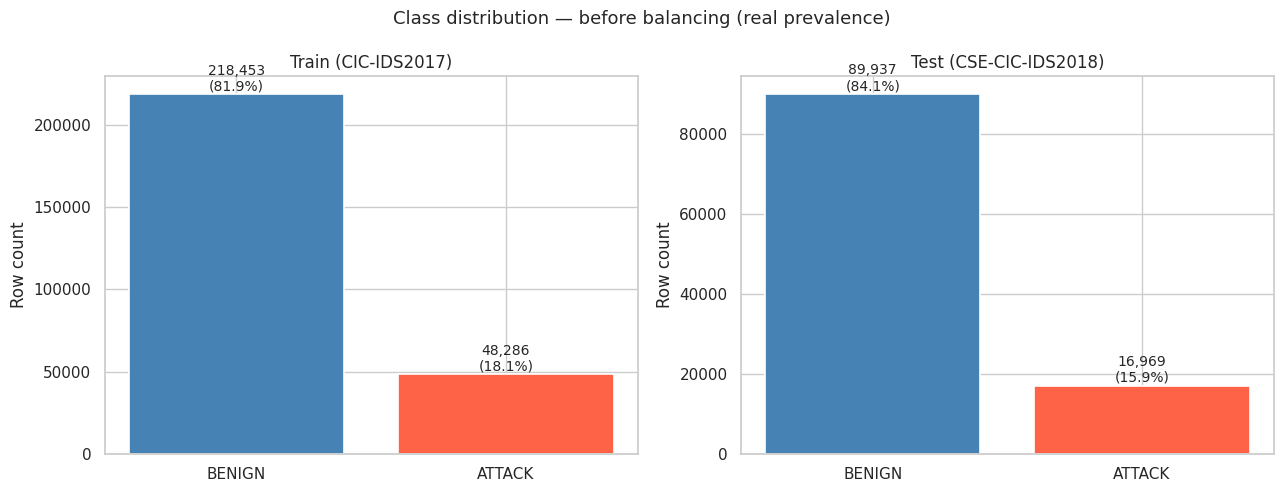


--- Train: attack-type breakdown ---
Label
BENIGN                        218453
DoS Hulk                       17587
PortScan                       14444
DDoS                           12732
DoS GoldenEye                    952
FTP-Patator                      652
DoS slowloris                    585
DoS Slowhttptest                 505
SSH-Patator                      401
Bot                              199
Web Attack - Brute Force         150
Web Attack - XSS                  70
Infiltration                       6
Web Attack - Sql Injection         2
Heartbleed                         1

--- Test: attack-type breakdown ---
Label
BENIGN                89937
Brute Force - XSS     10489
DDoS - HOIC            3415
Brute Force - Web      1903
DDoS - LOIC-UDP         861
DDoS - LOIC-HTTP        216
Bot                      34
DoS - GoldenEye          33
DoS - Hulk               11
DoS - SlowHTTPTest        6
DoS - Slowloris           1


In [75]:
def binary_counts(df):
    b = df['Label'].apply(lambda x: 'BENIGN' if str(x).strip().upper()=='BENIGN' else 'ATTACK')
    return b.value_counts().reindex(['BENIGN','ATTACK'], fill_value=0)

train_bc = binary_counts(df_train_clean)
test_bc  = binary_counts(df_test_clean)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, bc) in zip(axes, [('Train (CIC-IDS2017)', train_bc),
                                   ('Test (CSE-CIC-IDS2018)', test_bc)]):
    bars = ax.bar(bc.index, bc.values, color=['steelblue','tomato'],
                  edgecolor='white', linewidth=1.2)
    ax.set_title(name, fontsize=12)
    ax.set_ylabel('Row count')
    for bar, (lbl, val) in zip(bars, bc.items()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+300,
                f'{val:,}\n({val/bc.sum()*100:.1f}%)',
                ha='center', va='bottom', fontsize=10)

plt.suptitle('Class distribution — before balancing (real prevalence)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'class_distribution_raw.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Train: attack-type breakdown ---')
print(df_train_clean['Label'].value_counts().to_string())
print('\n--- Test: attack-type breakdown ---')
print(df_test_clean['Label'].value_counts().to_string())


**Class distribution** *(Figure 1)*: 218,453 BENIGN vs 48,286 attack in train (**81.9% benign**); 89,937 vs 16,969 in test (**84.1% benign**). Both reflect typical enterprise network conditions.

**Attack-type drift — the core threat to the paper's conclusions:**

| Attack type | Train | Test | Change |
|-------------|-------|------|--------|
| Web Attack - XSS | 70 | Brute Force - XSS: **10,489** | ~150× amplification |
| PortScan | **14,444** | 0 | Disappears entirely |
| DDoS (generic) | 12,732 | HOIC: 3,415 / LOIC-UDP: 861 / LOIC-HTTP: 216 | Renamed & fragmented |
| Bot | 199 | 34 | Shrinks |
| Heartbleed | **1** | 0 | Effectively unlearnable |
| Infiltration | **6** | 0 | Effectively unlearnable |

A model trained on 70 XSS flows that then faces 10,489 XSS flows at test time is experiencing **concept drift**, not classical overfitting. The paper conflates the two — the Overfitting vs. Concept Drift check (after §6) provides a direct test.

The authors' 1:1 downsampling also means accuracy on the balanced test set does not reflect deployment where 84% of inputs are benign. Quantified in §2.8.


### §2.2 — Feature Distributions


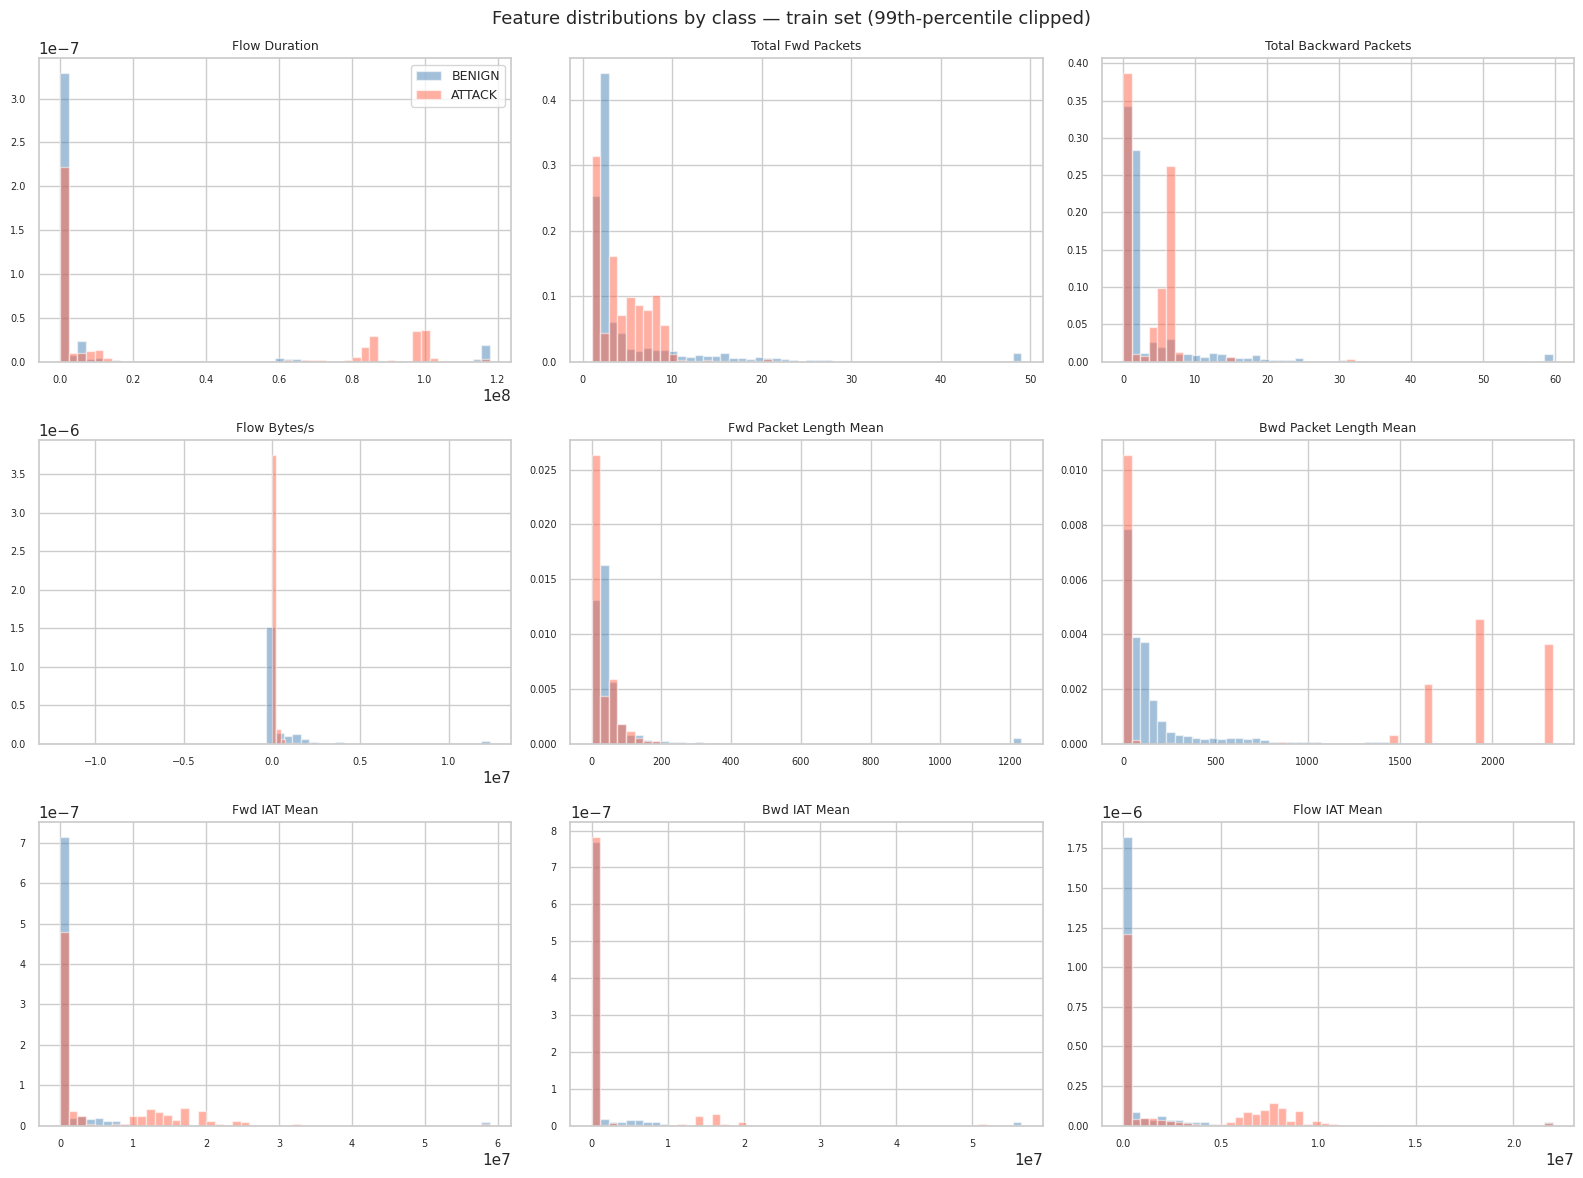

In [76]:
KEY_FEATURES = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Flow Bytes/s', 'Fwd Packet Length Mean', 'Bwd Packet Length Mean',
    'Fwd IAT Mean', 'Bwd IAT Mean', 'Flow IAT Mean',
]
KEY_FEATURES = [f for f in KEY_FEATURES if f in feat_cols_clean]

ncols = 3
nrows = (len(KEY_FEATURES) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for ax, feat in zip(axes, KEY_FEATURES):
    clip_val = df_train_clean[feat].quantile(0.99)
    for lbl, mask, color in [
        ('BENIGN', mask_benign, 'steelblue'),
        ('ATTACK', ~mask_benign, 'tomato')
    ]:
        ax.hist(df_train_clean.loc[mask, feat].clip(upper=clip_val),
                bins=50, alpha=0.5, color=color, label=lbl, density=True)
    ax.set_title(feat, fontsize=9)
    ax.tick_params(labelsize=7)

axes[0].legend(fontsize=9)
for ax in axes[len(KEY_FEATURES):]:
    ax.set_visible(False)

plt.suptitle('Feature distributions by class — train set (99th-percentile clipped)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'feature_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()


**Feature distributions** *(Figure 2)*:

- All features are **heavily right-skewed** — most flows are short with few packets, with a heavy tail of high-volume flows. This violates Pearson's normality assumption and motivates Spearman (§2.7).
- **`Flow Duration`** (attack) is bimodal: spike near zero (fast DoS floods) + mass at ~10⁸ µs (slowloris/Hulk keeping connections open). Two completely different attack mechanics in one binary label.
- **`Bwd Packet Length Mean`** (attack) is also bimodal: spike at 0 (Slowhttptest — no server response) + mass at 1,500–2,000 bytes (DDoS response packets).
- **`Flow Bytes/s`** shows negative values — a CICFlowMeter edge-case artifact in this dataset.
- The per-feature overlap between benign and attack explains why no single feature suffices; the paper's 11-feature selection (§3) targets the most discriminative *combination*.


### §2.3 — Missing Values Verification


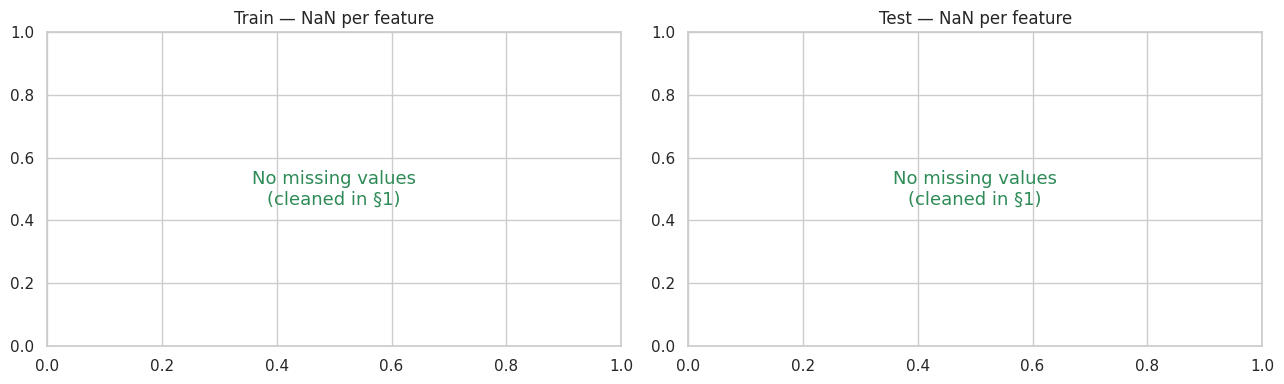

Train — inf values remaining: 0
Test — inf values remaining: 0


In [77]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (name, df) in zip(axes, [('Train', df_train_clean), ('Test', df_test_clean)]):
    nan_counts = df[feat_cols_clean].isnull().sum()
    nan_nz = nan_counts[nan_counts > 0]
    if nan_nz.empty:
        ax.text(0.5, 0.5, 'No missing values\n(cleaned in §1)',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=13, color='seagreen')
    else:
        nan_nz.sort_values(ascending=False).plot(kind='bar', ax=ax, color='tomato')
        ax.set_ylabel('NaN count')
    ax.set_title(f'{name} — NaN per feature')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'missing_values.png'), dpi=150, bbox_inches='tight')
plt.show()

for name, df in [('Train', df_train_clean), ('Test', df_test_clean)]:
    numeric = df[feat_cols_clean].select_dtypes(include='number')
    inf_count = np.isinf(numeric).sum().sum()
    print(f'{name} — inf values remaining: {inf_count}')


### §2.4 — Outlier Analysis


Outlier rate (IQR method, >Q3 + 1.5*IQR) — train set:

  Flow Duration                      : 47,051  (17.6%)
  Total Fwd Packets                  : 27,026  (10.1%)
  Total Backward Packets             : 23,905  (9.0%)
  Flow Bytes/s                       : 49,181  (18.4%)
  Fwd Packet Length Mean             : 18,287  (6.9%)
  Bwd Packet Length Mean             : 45,333  (17.0%)
  Fwd IAT Mean                       : 53,968  (20.2%)
  Bwd IAT Mean                       : 53,303  (20.0%)
  Flow IAT Mean                      : 53,689  (20.1%)


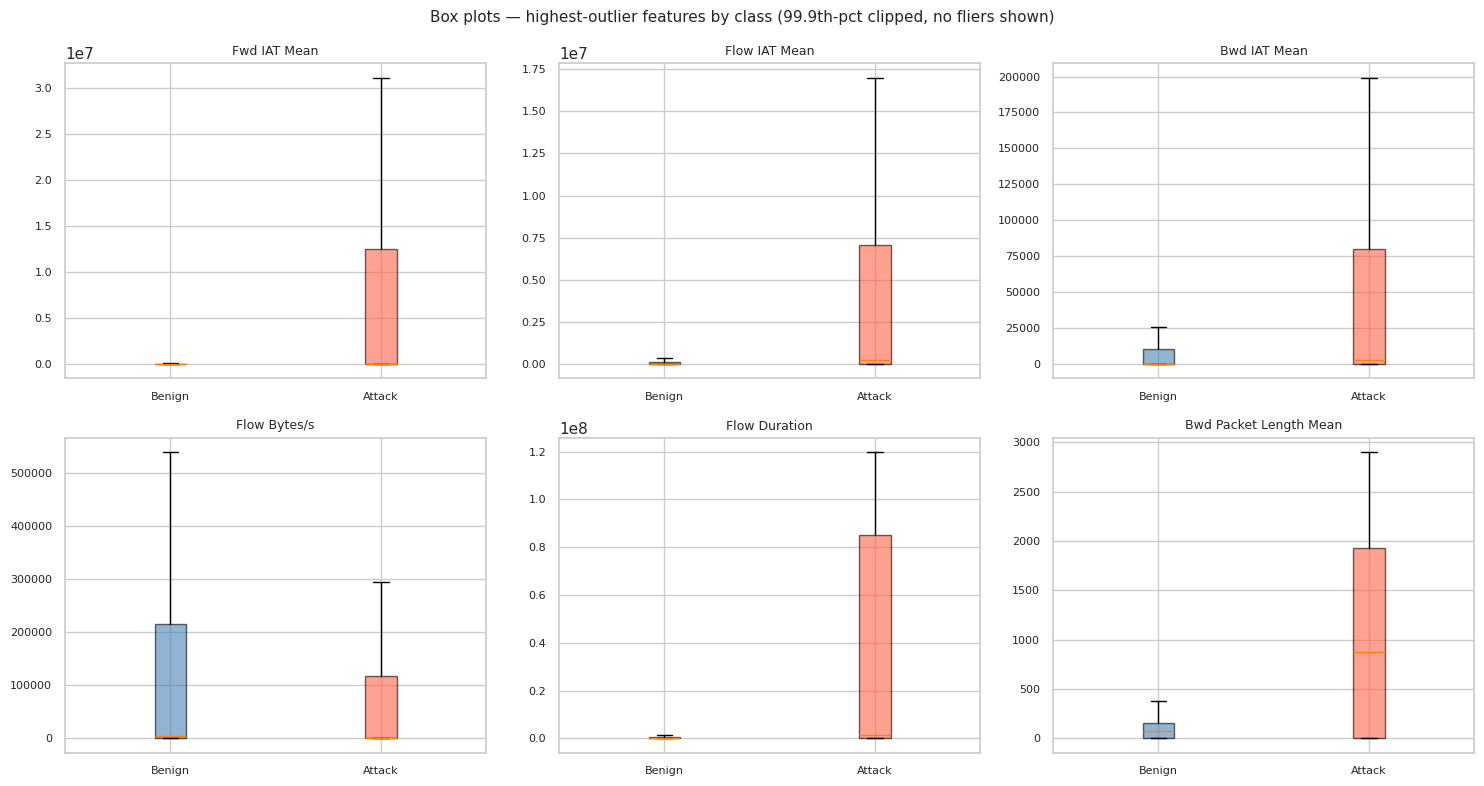

In [78]:
print('Outlier rate (IQR method, >Q3 + 1.5*IQR) — train set:\n')
outlier_summary = {}
for feat in KEY_FEATURES:
    q1, q3 = df_train_clean[feat].quantile([0.25, 0.75])
    upper = q3 + 1.5 * (q3 - q1)
    n_out = int((df_train_clean[feat] > upper).sum())
    outlier_summary[feat] = n_out
    print(f'  {feat:<35}: {n_out:>6,}  ({n_out/len(df_train_clean)*100:.1f}%)')

top6 = sorted(outlier_summary, key=outlier_summary.get, reverse=True)[:6]
top6 = [f for f in top6 if f in df_train_clean.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), top6):
    cap = df_train_clean[feat].quantile(0.999)
    data = [
        df_train_clean.loc[mask_benign, feat].clip(upper=cap).values,
        df_train_clean.loc[~mask_benign, feat].clip(upper=cap).values,
    ]
    bp = ax.boxplot(data, tick_labels=['Benign', 'Attack'], patch_artist=True, showfliers=False)
    for patch, color in zip(bp['boxes'], ['steelblue', 'tomato']):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(feat, fontsize=9)
    ax.tick_params(labelsize=8)

plt.suptitle(
    'Box plots — highest-outlier features by class (99.9th-pct clipped, no fliers shown)',
    fontsize=11
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'outlier_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()


**Outlier findings** *(Figure 4)*: IQR outlier rates of 5–20% per feature — expected, not a quality problem.

- **DoS/DDoS:** outliers in `Flow Bytes/s` and IAT — flooding at maximum rate.
- **PortScan:** extreme values in packet-length features (tiny probes) and very short `Flow Duration`.
- **Benign elephant flows:** genuine outliers in byte-count features (large file transfers, video streaming).
- **Counterintuitive:** BENIGN has a *higher* median `Flow Bytes/s` than ATTACK (~210k vs ~100k bytes/s). Slow DoS attacks (slowloris, Slowhttptest) have near-zero byte rates, pulling the attack median down. `Flow Bytes/s` alone is not a reliable attack indicator.

**Decision — do not clip outliers:** tree models (DT, RF) handle them via split thresholds; SVM/ANN inputs will be scaled in §3. Clipping would destroy the attack-fingerprint patterns.


### §2.5 — Temporal Feature Analysis


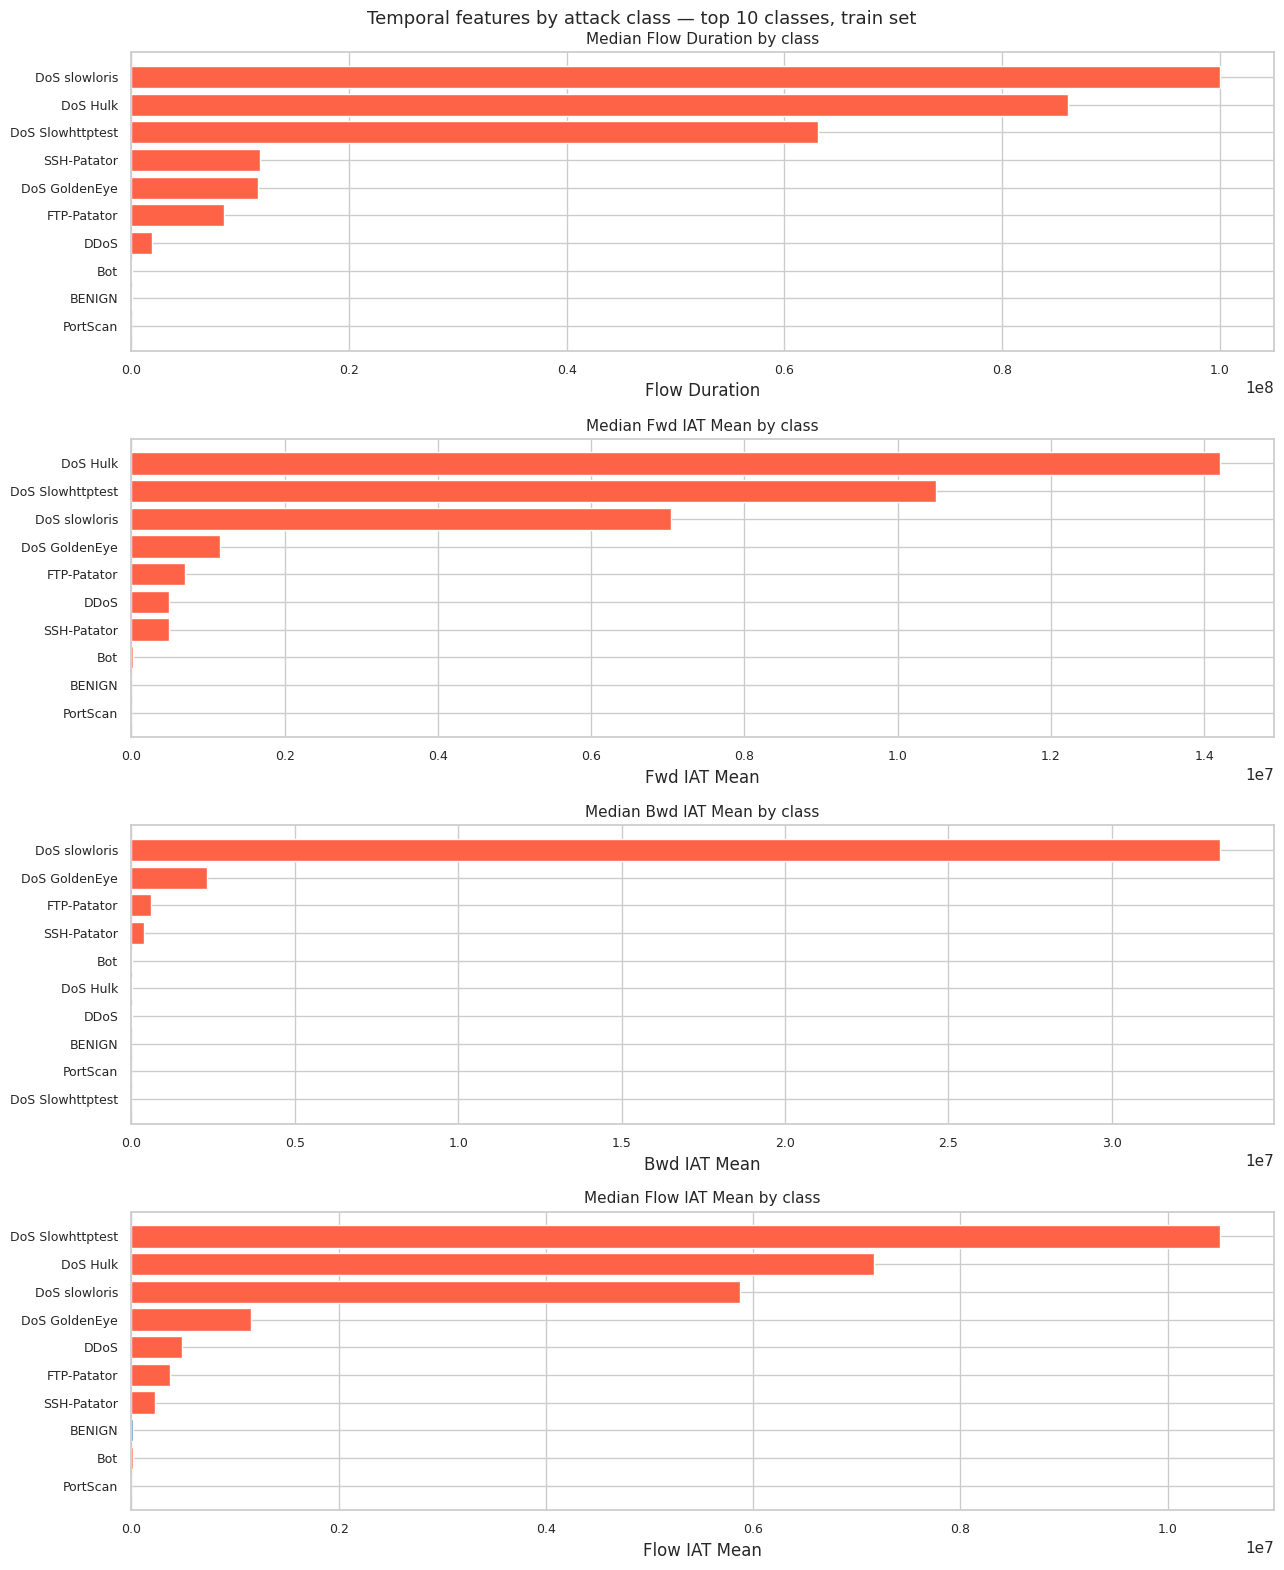

In [79]:
TEMPORAL_FEATS = [f for f in
    ['Flow Duration', 'Fwd IAT Mean', 'Bwd IAT Mean', 'Flow IAT Mean']
    if f in feat_cols_clean]

top10_labels = df_train_clean['Label'].value_counts().head(10).index.tolist()
df_sub = df_train_clean[df_train_clean['Label'].isin(top10_labels)]

fig, axes = plt.subplots(len(TEMPORAL_FEATS), 1, figsize=(13, 4 * len(TEMPORAL_FEATS)))
if len(TEMPORAL_FEATS) == 1:
    axes = [axes]

for ax, feat in zip(axes, TEMPORAL_FEATS):
    medians = df_sub.groupby('Label')[feat].median().sort_values()
    colors = ['steelblue' if 'BENIGN' in str(l).upper() else 'tomato'
              for l in medians.index]
    ax.barh(medians.index, medians.values, color=colors)
    ax.set_title(f'Median {feat} by class', fontsize=11)
    ax.set_xlabel(feat)
    ax.tick_params(labelsize=9)

plt.suptitle('Temporal features by attack class — top 10 classes, train set', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'temporal_features_by_class.png'), dpi=150, bbox_inches='tight')
plt.show()


**Temporal features by class** *(Figure 5)* — attack fingerprints align with known network behaviour:

- **DoS/DDoS** (GoldenEye, Hulk, LOIC/HOIC): near-zero IAT + short duration — flooding at maximum rate.
- **Slowloris / Slowhttptest:** longest flow durations (~10⁸ µs) — intentionally kept alive; near-zero Bwd IAT because server barely responds.
- **DoS Hulk:** high Fwd IAT despite being a DoS attack — Hulk sends valid HTTP GETs with pauses, not raw packet flooding.
- **PortScan:** near-zero duration and IAT (connection attempts fail immediately).
- **FTP-Patator / SSH-Patator:** moderate duration (full authentication protocol exchange per attempt).
- **BENIGN:** highest IAT variance — irregular, human-paced behaviour mixing DNS queries and streaming.

Note: DoS attacks dominate the axis scale — BENIGN, Bot, and PortScan bars are nearly invisible in Figure 5. This is a scale limitation, not a data problem.

**Timestamp excluded:** including calendar timestamps would teach the model '2017 = benign, 2018 = attack' (time leakage). IAT and Duration capture structural flow timing and are safe.


### §2.6 — Cross-tabulation and Group-by Analysis


In [80]:
SUMMARY_FEATS = [f for f in
    ['Flow Duration','Total Fwd Packets','Total Backward Packets',
     'Flow Bytes/s','Fwd Packet Length Mean','Bwd Packet Length Mean']
    if f in feat_cols_clean]

top8 = df_train_clean['Label'].value_counts().head(8).index.tolist()
group_stats = (
    df_train_clean[df_train_clean['Label'].isin(top8)]
    .groupby('Label')[SUMMARY_FEATS]
    .median()
    .round(2)
)
print('Median feature values by class (top 8, train set):')
print(group_stats.to_string())
print()

if 'Total Fwd Packets' in feat_cols_clean and 'Total Backward Packets' in feat_cols_clean:
    ratio = (df_train_clean['Total Backward Packets'] /
             (df_train_clean['Total Fwd Packets'] + 1e-6)).clip(0, 100)
    ratio_by_class = (
        df_train_clean[df_train_clean['Label'].isin(top8)]
        .assign(_ratio=ratio)
        .groupby('Label')['_ratio']
        .median()
        .sort_values()
    )
    print('Median Bwd/Fwd packet ratio by class:')
    print('  (0 = purely unidirectional DoS;  ~1 = balanced bidirectional traffic)')
    print(ratio_by_class.to_string())


Median feature values by class (top 8, train set):
                  Flow Duration  Total Fwd Packets  Total Backward Packets   Flow Bytes/s  Fwd Packet Length Mean  Bwd Packet Length Mean
Label                                                                                                                                    
BENIGN                  31468.0                2.0                     2.0    4794.520020                   37.00                   80.00
DDoS                  1878986.0                4.0                     4.0     159.460007                    7.00                 1934.50
DoS GoldenEye        11633371.0                7.0                     5.0     643.239990                   53.25                  881.25
DoS Hulk             86076088.0                6.0                     6.0     123.019997                   53.57                 1932.50
DoS Slowhttptest     63120634.0                7.0                     0.0       0.190000                    0.00        

**Bwd/Fwd packet ratio by class** — confirms known network-security patterns:

| Class | Median Bwd/Fwd | Note |
|-------|---------------|------|
| DoS Slowhttptest | **0.000** | Purely unidirectional — server never responds |
| DoS slowloris | 0.214 | Mostly unidirectional — connection starved |
| DoS GoldenEye | 0.625 | HTTP requests get some responses before slowdown |
| DDoS | 0.750 | Victim responds to a fraction of the flood |
| DoS Hulk | 0.857 | Near-symmetric — server tries to answer valid HTTP GETs |
| BENIGN | **1.000** | Perfectly bidirectional (TCP/HTTP/DNS) |
| PortScan | **1.000** | CICFlowMeter captures SYN+SYN-ACK → appears symmetric |
| FTP-Patator | **1.667** | *Server-heavy:* multiple 530 failure messages per login attempt |

- **FTP-Patator > 1** is the most unusual finding: attacker-initiated traffic generates *more server-side* packets than client-side — the FTP server sends banners, challenges, and error codes for every failed attempt.
- **PortScan = 1** is counterintuitive: CICFlowMeter captures completed SYN+SYN-ACK flows, not raw SYN probes — so packet-direction features alone won't easily distinguish scans from benign traffic.


### §2.7 — Correlation Analysis — Method Choice and Justification


**Why Spearman (not Pearson or Kendall):**

| Method | Key assumption | Verdict for this dataset |
|--------|---------------|-------------------------|
| **Pearson** | Linear relationship; normally distributed, homoscedastic data | ❌ Network features follow power-law distributions; outliers are attack signals, not errors; relationship is monotonic but not strictly linear |
| **Kendall** | Rank-based; no normality assumption; robust to outliers | ✅ Correct assumptions, but **O(n²)** computation — impractical for ~267k rows and 66 features |
| **Spearman** | Rank-based; no normality assumption; robust to outliers | ✅ Captures monotonic relationships; **O(n log n)**; correct and efficient for this scale |

**Practical vs. statistical significance:** With ~267k rows, virtually every non-zero correlation is statistically significant (p < 0.001). What matters is *practical* significance: |r| > 0.90 identifies feature pairs carrying essentially redundant information — candidates for removal in §3 feature selection.


**Mathematical definitions, advantages, and limitations (each method used):**

| Method | Formula | Advantages | Limitations |
|--------|---------|------------|--------------|
| **Pearson** *r* | r = Σ(xᵢ−x̄)(yᵢ−ȳ) / √(Σ(xᵢ−x̄)² · Σ(yᵢ−ȳ)²) | Simple, closed-form, fast; directly interpretable as strength of *linear* association | Assumes linearity + normality; sensitive to outliers — exactly what attack traffic produces (§2.4 outlier analysis); a strong monotonic-but-nonlinear relationship can score near 0 even though the features are highly related |
| **Spearman** *ρ* | ρ = 1 − 6Σdᵢ² / (n(n²−1)), where dᵢ = rank(xᵢ) − rank(yᵢ) | Rank-based, so robust to outliers and to any monotonic (not just linear) relationship; no distributional assumption; O(n log n) via sorting | Only captures rank order, not the magnitude/shape of the relationship; ties require averaged-rank handling |
| **Kendall** *τ* | τ = (concordant pairs − discordant pairs) / (n(n−1)/2) | Also rank-based and outlier-robust; more directly interpretable as "probability two random pairs agree in ordering"; often more reliable than Spearman on small/noisy samples | O(n²) pairwise comparisons — infeasible to compute directly on 267k rows without subsampling to a size comparable to Spearman's |

**Chosen: Spearman**, computed on a 10,000-row subsample for tractability. This is the correct
choice for the heavy right-skew confirmed in §2.2's feature-distribution plots (Pearson's
linearity/normality assumptions are violated), while remaining computable at a scale Kendall
cannot reach directly. Kendall would answer the same underlying question (monotonic association)
but is reserved here for the smaller VIF-selected feature subset in §3.8 where O(n²) is cheap
enough to actually run.

In [81]:
# Spearman on a 10k-row subsample — fast and representative
_CORR_N = 10_000
df_corr_sample = df_train_clean[feat_cols_clean].sample(
    min(_CORR_N, len(df_train_clean)), random_state=SEED
)
print(f'Computing Spearman matrix on {len(df_corr_sample):,} rows x {len(feat_cols_clean)} features...')
corr_matrix = df_corr_sample.corr(method='spearman')
print('Done.')

# Pairs with |r| > 0.90 — redundant features
high_pairs = []
cols = corr_matrix.columns.tolist()
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        r = float(corr_matrix.iloc[i, j])
        if abs(r) > 0.90:
            high_pairs.append((abs(r), r, cols[i], cols[j]))
high_pairs.sort(reverse=True)

print(f'\nFeature pairs |Spearman r| > 0.90  ({len(high_pairs)} total — top 20 shown):')
for _, r, c1, c2 in high_pairs[:20]:
    print(f'  r={r:+.3f}  {c1}  <->  {c2}')


Computing Spearman matrix on 10,000 rows x 66 features...
Done.

Feature pairs |Spearman r| > 0.90  (99 total — top 20 shown):
  r=+1.000  Subflow Fwd Packets  <->  Total Fwd Packets
  r=+1.000  Subflow Fwd Bytes  <->  Total Length of Fwd Packets
  r=+1.000  Subflow Bwd Packets  <->  Total Backward Packets
  r=+1.000  Subflow Bwd Bytes  <->  Total Length of Bwd Packets
  r=+1.000  Fwd PSH Flags  <->  SYN Flag Count
  r=+1.000  ECE Flag Count  <->  RST Flag Count
  r=+1.000  Avg Fwd Segment Size  <->  Fwd Packet Length Mean
  r=+1.000  Avg Bwd Segment Size  <->  Bwd Packet Length Mean
  r=+1.000  Packet Length Std  <->  Packet Length Variance
  r=+1.000  Idle Max  <->  Idle Mean
  r=+0.999  Active Max  <->  Active Mean
  r=+0.999  Idle Mean  <->  Idle Min
  r=+0.998  Bwd IAT Max  <->  Bwd IAT Mean
  r=+0.998  Idle Max  <->  Idle Min
  r=+0.998  Bwd IAT Max  <->  Bwd IAT Total
  r=+0.998  Active Mean  <->  Active Min
  r=-0.997  Flow IAT Mean  <->  Flow Packets/s
  r=+0.997  Flow Packets

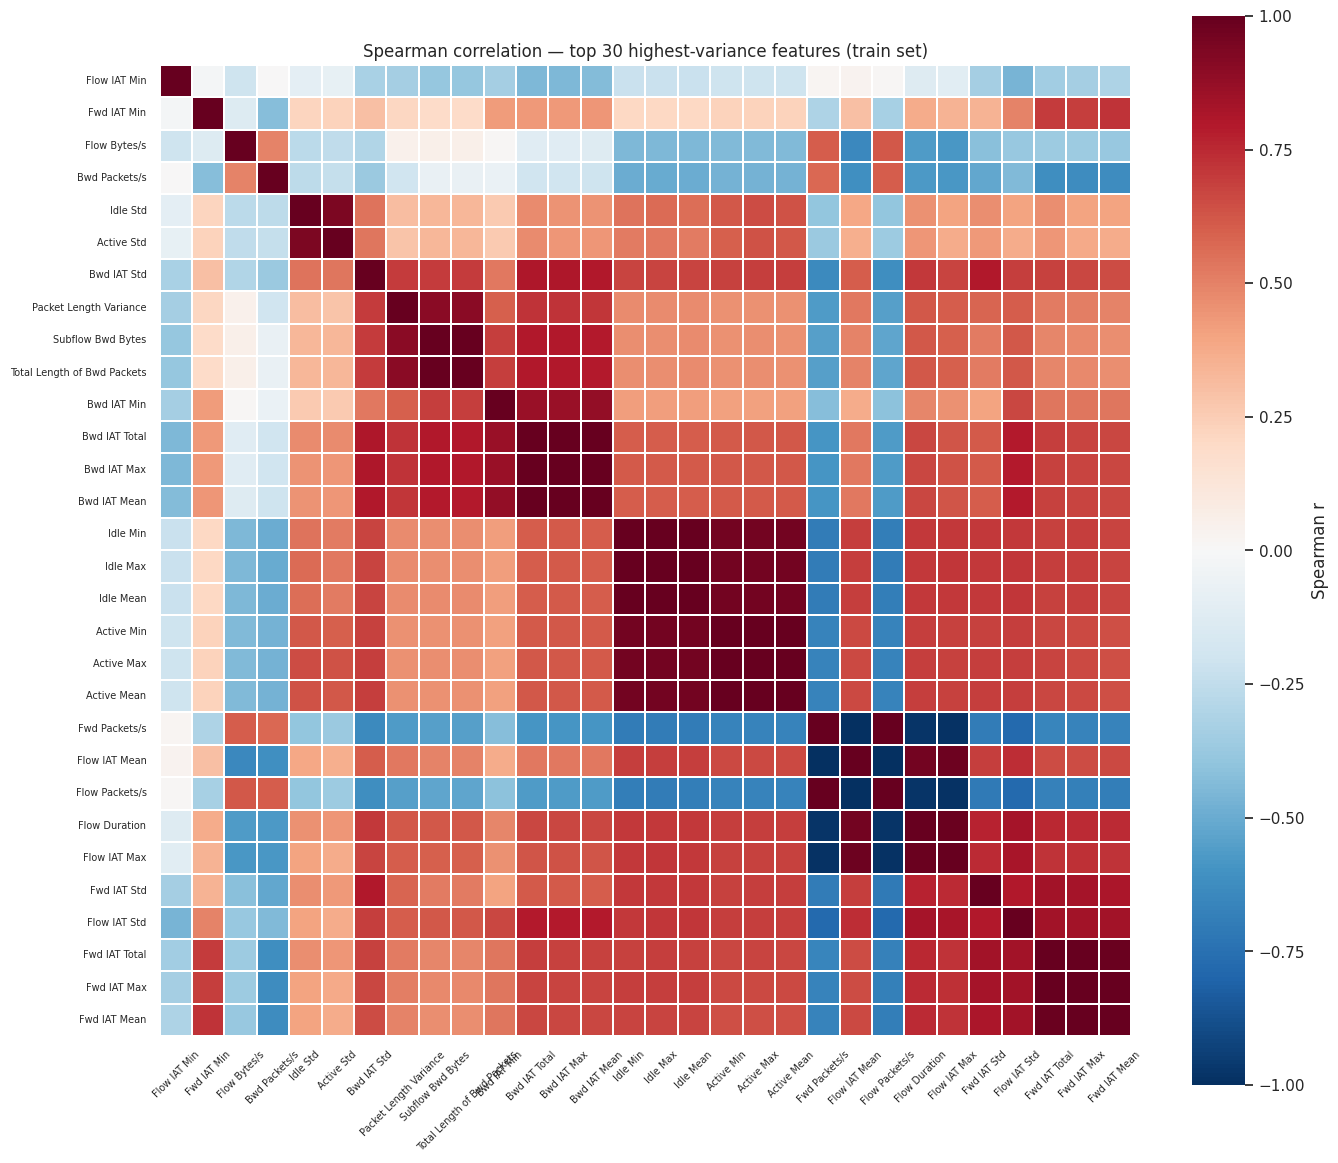

In [82]:
# Spearman heatmap — top 30 highest-variance features, hierarchically clustered
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

top30 = df_corr_sample.var().nlargest(30).index.tolist()
sub_corr = corr_matrix.loc[top30, top30]

try:
    dist_mat = (1 - sub_corr.abs()).clip(lower=0)
    np.fill_diagonal(dist_mat.values, 0.0)
    link = linkage(squareform(dist_mat.values), method='average')
    order = leaves_list(link)
    sub_corr = sub_corr.iloc[order, order]
except Exception as e:
    print(f'Hierarchical clustering skipped ({e}); using original order.')

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(sub_corr, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, cbar_kws={'label': 'Spearman r'},
            xticklabels=True, yticklabels=True)
ax.tick_params(axis='x', labelrotation=45, labelsize=7)
ax.tick_params(axis='y', labelrotation=0, labelsize=7)
ax.set_title('Spearman correlation — top 30 highest-variance features (train set)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'spearman_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()


**Spearman correlation** *(Figure 6)*: 99 pairs with |r| > 0.90. Ten pairs are r = 1.000 (mathematically identical):

| Pair (r = 1.000) | Reason |
|-----------------|--------|
| `Subflow Fwd/Bwd Packets/Bytes` ↔ `Total Fwd/Bwd Packets/Length` (4 pairs) | CICFlowMeter: Subflow = Total for single-subflow flows |
| `Avg Fwd/Bwd Segment Size` ↔ `Fwd/Bwd Packet Length Mean` (2 pairs) | Two names for the same computation |
| `Packet Length Std` ↔ `Packet Length Variance` | Mathematical identity: Var = Std² |
| `Idle Max` ↔ `Idle Mean` | Near-constant idle times |
| `Fwd PSH Flags` ↔ `SYN Flag Count` | CIC capture artefact |
| `ECE Flag Count` ↔ `RST Flag Count` | CIC capture artefact |

**Three redundancy clusters (visible in Figure 6):**
1. **Subflow cluster:** four subflow features are exact duplicates of four total-flow features → all four should be dropped.
2. **Packet length / segment size:** `Avg Segment Size` = `Packet Length Mean`; `Packet Length Variance` = `Packet Length Std²` → keep one per pair.
3. **IAT cluster:** `Bwd/Fwd/Flow IAT Max/Mean/Total` all r ≥ 0.997 with each other → one representative suffices.

The flag artefacts (PSH↔SYN, ECE↔RST) are CIC-specific — if these correlations break in a different network capture, a model relying on them will degrade, contributing to the cross-dataset performance drop.

This directly motivates the authors' **66 → 11 feature reduction** reproduced in §3.


### §2.8 — Pre- vs Post-Balancing: the 'Symmetry' Trade-off


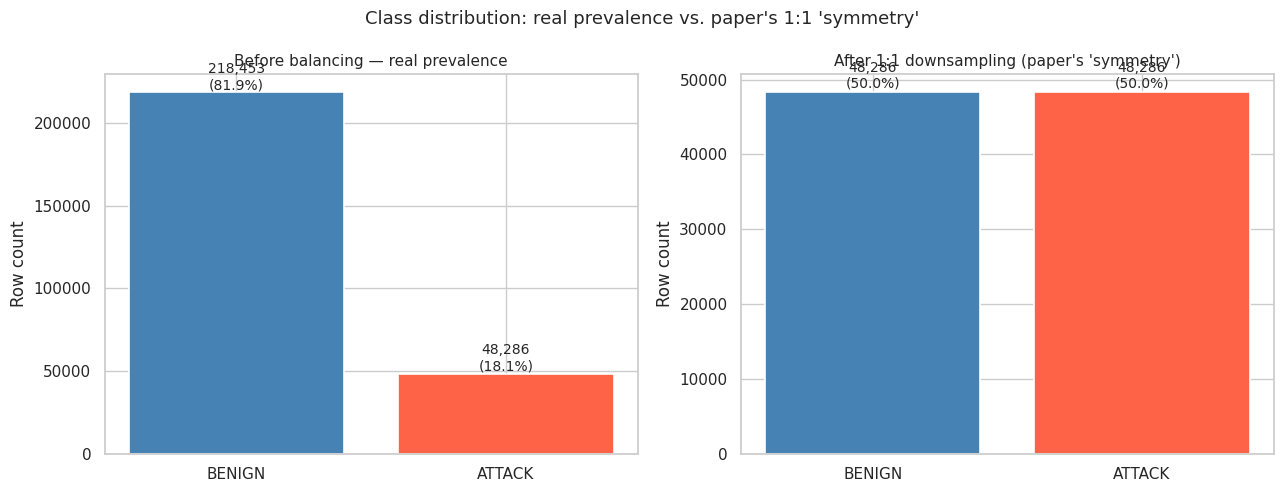

Rows discarded by 1:1 downsampling: 170,167
Training data retained: 36.2%


In [83]:
df_bin = df_train_clean.assign(
    _binary=df_train_clean['Label'].apply(
        lambda x: 'BENIGN' if str(x).strip().upper()=='BENIGN' else 'ATTACK'
    )
)
before = df_bin['_binary'].value_counts().reindex(['BENIGN','ATTACK'], fill_value=0)

n_min = int(before.min())
balanced = pd.concat([
    df_bin[df_bin['_binary']==cls].sample(n=n_min, random_state=SEED)
    for cls in ['BENIGN','ATTACK']
])
after = balanced['_binary'].value_counts().reindex(['BENIGN','ATTACK'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (title, bc) in zip(axes, [
    ('Before balancing — real prevalence', before),
    ("After 1:1 downsampling (paper's 'symmetry')", after)
]):
    bars = ax.bar(bc.index, bc.values, color=['steelblue','tomato'],
                  edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Row count')
    total = bc.sum()
    for bar, val in zip(bars, bc.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                f'{val:,}\n({val/total*100:.1f}%)',
                ha='center', va='bottom', fontsize=10)

plt.suptitle("Class distribution: real prevalence vs. paper's 1:1 'symmetry'", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'class_balancing_effect.png'), dpi=150, bbox_inches='tight')
plt.show()

discarded = int(before.sum() - after.sum())
print(f'Rows discarded by 1:1 downsampling: {discarded:,}')
print(f'Training data retained: {after.sum()/before.sum()*100:.1f}%')


**The real cost of 1:1 'symmetry'** *(Figure 7)*: keeping only 48,286 of 218,453 BENIGN rows means **170,167 rows discarded — 63.8% of all training data**. Only 36.2% is used.

- **Metric inflation:** accuracy on a 1:1 balanced test set is systematically higher than on a deployment-realistic 84%-benign set. The paper's reported ~96–99% in-distribution accuracy is an upper bound, not a deployment estimate.
- **Data waste:** the model sees a less representative sample of legitimate traffic — rare-but-legitimate flows that fall in the discarded majority may become false positives.
- **Alternatives not explored:** class-weighted loss, SMOTE (synthetic oversampling), or threshold tuning — all address imbalance without discarding 63.8% of the data. The paper's 'symmetry' framing elevates a pragmatic compromise to a principle it doesn't warrant.

§5.5b/c re-evaluates all models on both the real-prevalence and 1:1-balanced test splits to measure the accuracy gap directly.


---
## §3 — Feature Engineering

Reproduce the authors' preprocessing pipeline, then add feature creation,
scaling, feature selection (RF importance + brute-force add-one loop),
and a redundancy analysis. Steps:

- **§3.1** Cleaning recap — mirrors the authors' `01_Dataset_Preprocessing.ipynb`
- **§3.2** Binary relabelling — collapse 15 attack types → `ATTACK`
- **§3.3** Class balancing — 1:1 downsample (paper's method) + preserve real-prevalence copy
- **§3.4** Categorical encoding — choice and justification
- **§3.5** Derived features — four engineered flow metrics with cyber rationale
- **§3.6** Feature scaling — StandardScaler fitted on balanced training set
- **§3.7** Feature selection — RF importance ranking + brute-force add-one accuracy curve
- **§3.8** Redundancy analysis — correlation clusters, RF importance, VIF


In [84]:
# §3 setup — reload cleaned frames if needed; import preprocessing module
import os, pathlib, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import dump, load as jload

try:
    df_train_clean
except NameError:
    df_train_clean = jload(os.path.join(DATA_DIR, 'train_clean.joblib'))
    df_test_clean  = jload(os.path.join(DATA_DIR, 'test_clean.joblib'))
    print('Reloaded cleaned frames from Drive.')

from src.preprocessing import (
    binary_relabel, balance_1to1, add_derived_features, get_feature_cols,
    fit_scaler, apply_scaler, select_features_rf, brute_force_select, compute_vif,
)

FIGURES_DIR = str(pathlib.Path(DATA_DIR).parent / 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)
sns.set_theme(style='whitegrid', palette='tab10')

print(f'Train: {df_train_clean.shape}  |  Test: {df_test_clean.shape}')
print(f'Features available: {len(get_feature_cols(df_train_clean))}')


Train: (266739, 67)  |  Test: (106906, 67)
Features available: 66


### §3.1 — Cleaning Recap — mirroring the authors


In [85]:
# §3.1 — Cleaning was performed in §1; document it here for the reproducibility record.
print('=== Cleaning steps applied in §1 (mirrors 01_Dataset_Preprocessing.ipynb) ===\n')
steps = [
    ('1. Strip column-name whitespace',
     'Identical to authors — CICFlowMeter produces inconsistent spacing'),
    ('2. Drop Fwd Header Length.1',
     'Duplicate of Fwd Header Length; present only in CIC-IDS2017'),
    ('3. Replace ±inf → NaN, dropna()',
     'Identical to authors — removes ~0.05% train rows, ~0.63% test rows'),
    ('4. Downcast float64 → float32',
     'Our addition — halves RAM on free Colab; negligible precision loss'),
    ('5. Drop duplicate feature rows',
     'Our addition — removes 5.2% train / 14.3% test; reduces noise from repeated flows'),
    ('6. Drop 10 constant columns',
     'Our addition — zero-variance features (CICFlowMeter bulk-rate artefacts)'),
]
for step, note in steps:
    print(f'  {step}\n    → {note}\n')
print(f'Resulting shapes:  train {df_train_clean.shape}  |  test {df_test_clean.shape}')
print(f'Features: {len(get_feature_cols(df_train_clean))}  (down from 78 in raw CSVs)')


=== Cleaning steps applied in §1 (mirrors 01_Dataset_Preprocessing.ipynb) ===

  1. Strip column-name whitespace
    → Identical to authors — CICFlowMeter produces inconsistent spacing

  2. Drop Fwd Header Length.1
    → Duplicate of Fwd Header Length; present only in CIC-IDS2017

  3. Replace ±inf → NaN, dropna()
    → Identical to authors — removes ~0.05% train rows, ~0.63% test rows

  4. Downcast float64 → float32
    → Our addition — halves RAM on free Colab; negligible precision loss

  5. Drop duplicate feature rows
    → Our addition — removes 5.2% train / 14.3% test; reduces noise from repeated flows

  6. Drop 10 constant columns
    → Our addition — zero-variance features (CICFlowMeter bulk-rate artefacts)

Resulting shapes:  train (266739, 67)  |  test (106906, 67)
Features: 66  (down from 78 in raw CSVs)


**Cleaning decisions match the authors** for the core three steps (strip names, drop duplicate column,
remove inf/NaN). Two extra steps were added — `float32` downcasting and deduplication — to fit
free Colab RAM and reduce noise. Neither changes statistical structure: deduplication removes
exact-copy rows (no additional information), and float32 rounding error is below 1e-7.


### §3.2 — Binary Relabelling


In [86]:
# §3.2 — Collapse 15+ attack types → binary ATTACK / BENIGN.
# Mirrors the authors' 01_Dataset_Preprocessing.ipynb Step 4.
df_train_bin = binary_relabel(df_train_clean)
df_test_bin  = binary_relabel(df_test_clean)

for name, df_orig, df_bin in [
    ('Train', df_train_clean, df_train_bin),
    ('Test',  df_test_clean,  df_test_bin),
]:
    orig_classes = df_orig['Label'].nunique()
    vc = df_bin['Label'].value_counts()
    print(f'{name}: {orig_classes} original classes → 2 binary classes')
    print(f'  BENIGN : {vc["BENIGN"]:>7,}  ({vc["BENIGN"]/len(df_bin)*100:.1f}%)')
    print(f'  ATTACK : {vc["ATTACK"]:>7,}  ({vc["ATTACK"]/len(df_bin)*100:.1f}%)')
    print()


Train: 15 original classes → 2 binary classes
  BENIGN : 218,453  (81.9%)
  ATTACK :  48,286  (18.1%)

Test: 11 original classes → 2 binary classes
  BENIGN :  89,937  (84.1%)
  ATTACK :  16,969  (15.9%)



**Binary relabelling rationale:** The paper collapses all attack types to a single `malicious` label
to focus on the binary detection task. This simplifies the target and allows a fair 6-model comparison
without multiclass complications.

**Trade-off:** binary collapse discards within-class structure. As shown in §2.1, XSS in train (n=70)
and XSS in test (n=10,489) are statistically very different — binary collapse hides this distribution shift.
The original multiclass `Label` is preserved in `df_train_clean` / `df_test_clean`
for a possible future multiclass extension (not pursued in this project).


### §3.3 — Class Balancing (1:1) and Real-Prevalence Copy


In [87]:
# §3.3 — Downsample BENIGN to 1:1; keep a real-prevalence copy for §5.5b/c and the
# Only the training set is balanced; the test set stays at real prevalence.
df_train_bal, df_train_imbal = balance_1to1(df_train_bin, seed=SEED)

print('=== Training set: before and after 1:1 balancing ===')
for label, df in [('Real prevalence copy (used in §5.5b/c)', df_train_imbal),
                   ('1:1 balanced    (mirrors paper)',  df_train_bal)]:
    vc = df['Label'].value_counts()
    total = len(df)
    print(f'\n  {label}')
    print(f'    BENIGN: {vc["BENIGN"]:>7,}  ({vc["BENIGN"]/total*100:.1f}%)')
    print(f'    ATTACK: {vc["ATTACK"]:>7,}  ({vc["ATTACK"]/total*100:.1f}%)')
    print(f'    Total:  {total:>7,}')

discarded = len(df_train_imbal) - len(df_train_bal)
print(f'\nRows discarded: {discarded:,} ({discarded/len(df_train_imbal)*100:.1f}% of training data)')
print('Test set: kept at real prevalence — not balanced.')


=== Training set: before and after 1:1 balancing ===

  Real prevalence copy (used in §5.5b/c)
    BENIGN: 218,453  (81.9%)
    ATTACK:  48,286  (18.1%)
    Total:  266,739

  1:1 balanced    (mirrors paper)
    BENIGN:  48,286  (50.0%)
    ATTACK:  48,286  (50.0%)
    Total:   96,572

Rows discarded: 170,167 (63.8% of training data)
Test set: kept at real prevalence — not balanced.


**Two copies kept deliberately:**

- `df_train_bal` — 1:1 balanced copy used for all model training and in-distribution
  evaluation (mirrors the paper). The 50/50 ratio means a trivial classifier achieves 50% accuracy,
  so any model above that is doing real work.
- `df_train_imbal` — real-prevalence copy (~82% BENIGN) used later (§5.5b/c) to re-score
  models under deployment conditions and challenge the paper's "symmetry" framing.

**Critique note (→ report §2):** The paper discards ~63.8% of training data to achieve 1:1.
Alternatives — `class_weight='balanced'`, SMOTE oversampling, or decision-threshold tuning —
would address imbalance without discarding majority-class information.
The paper does not compare these alternatives.


### §3.4 — Categorical Encoding — Choice and Justification


In [88]:
# §3.4 — Check for non-numeric feature columns; discuss Destination Port encoding.
feat_cols = get_feature_cols(df_train_bal)

dtype_counts = df_train_bal[feat_cols].dtypes.value_counts()
print('Feature dtype breakdown (balanced training set):')
print(dtype_counts.to_string())

non_numeric = df_train_bal[feat_cols].select_dtypes(exclude='number').columns.tolist()
print(f'\nNon-numeric feature columns: {non_numeric or "none — all features are numeric"}')

# Destination Port — the integer feature that warrants encoding discussion
port_col = 'Destination Port'
if port_col in df_train_bal.columns:
    port = df_train_bal[port_col]
    print(f'\nDestination Port: dtype={port.dtype}, unique={port.nunique():,}, '
          f'min={port.min():.0f}, max={port.max():.0f}')
    print(f'Top-10 most frequent ports in balanced train:')
    print(port.value_counts().head(10).to_dict())
    well_known = (port < 1024).sum()
    registered = ((port >= 1024) & (port < 49152)).sum()
    dynamic    = (port >= 49152).sum()
    print(f'\nPort range breakdown:  well-known 0-1023: {well_known:,}  '
          f'registered 1024-49151: {registered:,}  dynamic 49152+: {dynamic:,}')


Feature dtype breakdown (balanced training set):
int64      42
float32    24

Non-numeric feature columns: none — all features are numeric

Destination Port: dtype=int64, unique=8,927, min=0, max=65490
Top-10 most frequent ports in balanced train:
{80: 37522, 53: 20696, 443: 10563, 21: 757, 22: 605, 123: 522, 8080: 185, 389: 155, 88: 142, 137: 80}

Port range breakdown:  well-known 0-1023: 73,602  registered 1024-49151: 15,529  dynamic 49152+: 7,441


**Encoding decision: treat `Destination Port` as a continuous numeric integer (no encoding applied).**

All 66 features are already numeric after §1 cleaning. The only encoding question is `Destination Port`:

| Option | Problem |
|--------|---------|
| **One-hot** | Up to 65,536 unique ports → impractical sparse columns |
| **Label/ordinal** | Arbitrary ordering (port 443 is not numerically "larger" than port 80 in a meaningful sense) |
| **Port-range bins** | Loses within-bin discrimination (port 22 vs port 80 collapse to one category) |
| **Keep as integer (chosen)** | Port ranges have genuine ordinal structure; tree models learn port-specific splits (`port ≤ 1023`); SVM/ANN treat it as a feature on equal scale with others after StandardScaling |

The paper treats `Destination Port` as numeric throughout — it appears in their final 11-feature set.
**Limitation for generalisation:** port-specific patterns from CIC-IDS2017 (e.g., scans targeting
port 80/443) may not transfer to CIC-IDS2018 if attack tools target different ports —
contributing to the cross-dataset performance drop.


### §3.5 — Derived Features


In [89]:
# §3.5 — Add four engineered flow features.
# Applied to all three sets independently (no target leakage, no cross-set statistics).
df_train_bal   = add_derived_features(df_train_bal)
df_train_imbal = add_derived_features(df_train_imbal)
df_test_bin    = add_derived_features(df_test_bin)

derived = ['feat_bwd_fwd_ratio', 'feat_pkt_len_range', 'feat_bytes_per_pkt', 'feat_win_ratio']
print('New derived feature stats (balanced train set):\n')
print(df_train_bal[derived].describe().round(3).to_string())
print('\nMedian by class (balanced train):')
print(df_train_bal.groupby('Label')[derived].median().round(3).to_string())


New derived feature stats (balanced train set):

       feat_bwd_fwd_ratio  feat_pkt_len_range  feat_bytes_per_pkt  feat_win_ratio
count           96572.000           96572.000           96572.000       96572.000
mean                0.894            1856.291             327.372      177969.312
std                 0.570            2935.594             468.609      381654.719
min                 0.000               0.000               0.000          -1.000
25%                 0.667               4.000               4.000           0.000
50%                 1.000              56.000              67.000           5.582
75%                 1.000            4344.000             791.152         256.000
max                29.000           24820.000            2336.000     1000000.000

Median by class (balanced train):
        feat_bwd_fwd_ratio  feat_pkt_len_range  feat_bytes_per_pkt  feat_win_ratio
Label                                                                             
ATTACK      

**Derived feature stats from the actual run** (balanced train set, medians by class):

| Feature | Median ATTACK | Median BENIGN | Discriminative? |
|---------|--------------|---------------|-----------------|
| `feat_bwd_fwd_ratio` | 1.000 | 1.000 | **No — same median for both classes** |
| `feat_pkt_len_range` | 2,896 | 54 | **Yes — 54× difference** |
| `feat_bytes_per_pkt` | 427.5 | 64.7 | **Yes — 6.6× difference** |
| `feat_win_ratio` | 123.7 | 0.235 | **Yes — 526× difference** |

**`feat_bwd_fwd_ratio` did not make the top 20 — and the median table explains why.**
In §2.6 (group-by analysis) this feature separated attack *types* clearly
(DoS Slowhttptest=0, FTP-Patator=1.667), but once all attacks are binary-collapsed,
the diverse attack types average out and the binary ATTACK median is 1.0 — identical to BENIGN.
This is a direct consequence of the paper's binary-collapse decision: per-type signals
are erased when merged into a single ATTACK class.

**`feat_win_ratio` is the standout success** — 526× median difference between classes,
ranked 3rd by RF importance (0.0595), beating almost all original features.
The TCP window size asymmetry is a strong fingerprint: attack tools (scanners, bots)
systematically use non-OS-default window sizes.

**2 of 4 derived features entered the final top-11:**
`feat_win_ratio` (rank 3) and `feat_bytes_per_pkt` (rank 11).
`feat_pkt_len_range` ranked 16th — useful but not top-11.
`feat_bwd_fwd_ratio` ranked below top-20 entirely.


### §3.6 — Feature Scaling


In [90]:
# §3.6 — Fit StandardScaler on the balanced training set;
# apply to the imbalanced training copy and the test set.
feat_cols = get_feature_cols(df_train_bal)

X_bal   = df_train_bal[feat_cols]
y_bal   = df_train_bal['Label']
X_imbal = df_train_imbal[feat_cols]
y_imbal = df_train_imbal['Label']
X_test  = df_test_bin[feat_cols]
y_test  = df_test_bin['Label']

scaler, X_bal_scaled = fit_scaler(X_bal)
X_imbal_scaled = apply_scaler(scaler, X_imbal)
X_test_scaled  = apply_scaler(scaler, X_test)

print('Scaler fitted on balanced training set only (no leakage from imbal/test).')
print(f'X_bal_scaled   shape: {X_bal_scaled.shape}  '
      f'mean_max_abs: {X_bal_scaled.mean().abs().max():.5f}  '
      f'std_mean: {X_bal_scaled.std().mean():.5f}')
print(f'X_imbal_scaled shape: {X_imbal_scaled.shape}')
print(f'X_test_scaled  shape: {X_test_scaled.shape}')
print()
print('Sample feature means/stds on scaled training set:')
for c in feat_cols[:4]:
    print(f'  {c:<45} mean={X_bal_scaled[c].mean():+.4f}  std={X_bal_scaled[c].std():.4f}')


Scaler fitted on balanced training set only (no leakage from imbal/test).
X_bal_scaled   shape: (96572, 70)  mean_max_abs: 0.00000  std_mean: 1.00000
X_imbal_scaled shape: (266739, 70)
X_test_scaled  shape: (106906, 70)

Sample feature means/stds on scaled training set:
  ACK Flag Count                                mean=-0.0000  std=1.0005
  Active Max                                    mean=-0.0000  std=1.0000
  Active Mean                                   mean=+0.0000  std=0.9997
  Active Min                                    mean=-0.0000  std=1.0003


**Scaling rationale:**

- **SVM (RBF kernel):** distance-based — `Destination Port` (0–65 535) would dominate
  `FIN Flag Count` (0–5) without scaling, making the SVM effectively ignore low-range features.
- **ANN/DNN (MLPClassifier):** gradient descent converges faster and more reliably
  with zero-mean, unit-variance inputs.
- **DT/RF/NB:** insensitive to scale — scaling changes nothing for these models,
  but applying it uniformly simplifies the pipeline.

**Implementation note:** the scaler is fitted **only on the balanced training set**
and then applied to the imbalanced copy and the test set.
Fitting on test data would leak the test distribution into the training normalisation — a data-leakage bug.


### §3.7 — Feature Selection — RF Importance + Brute-Force Add-One


In [91]:
# §3.7a — Stage 1: RF importance ranking on the balanced, scaled training set.
# Mirrors the authors' 02_Feature_Selection.ipynb Stage 1.
print('Fitting RF for feature importance ranking...')
t0 = time.time()
top20_features, full_importance = select_features_rf(
    X_bal_scaled, y_bal, top_n=20, seed=SEED
)
print(f'Done in {time.time()-t0:.1f}s\n')

print('Top-20 features by RF importance:')
for rank, feat in enumerate(top20_features, 1):
    imp_val = full_importance[feat]
    print(f'  {rank:2d}. {feat:<45} {imp_val:.4f}')


Fitting RF for feature importance ranking...
Done in 16.0s

Top-20 features by RF importance:
   1. Average Packet Size                           0.0787
   2. Bwd Packet Length Std                         0.0627
   3. feat_win_ratio                                0.0595
   4. Packet Length Std                             0.0587
   5. Destination Port                              0.0403
   6. Packet Length Variance                        0.0398
   7. Fwd Packet Length Max                         0.0370
   8. Init_Win_bytes_backward                       0.0350
   9. Avg Bwd Segment Size                          0.0346
  10. Bwd Packet Length Mean                        0.0343
  11. feat_bytes_per_pkt                            0.0340
  12. Max Packet Length                             0.0290
  13. Fwd Packet Length Min                         0.0275
  14. Bwd Packet Length Min                         0.0274
  15. Min Packet Length                             0.0258
  16. feat_pkt_len_ra

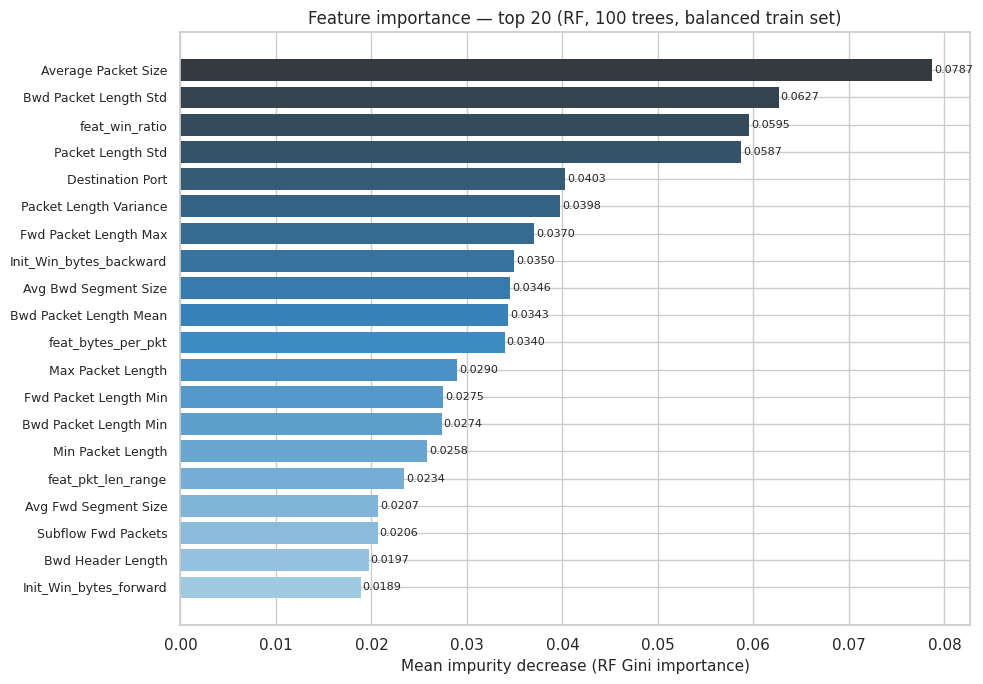

In [92]:
# §3.7b — Feature importance bar chart (top 20)
fig, ax = plt.subplots(figsize=(10, 7))
imp_top20 = full_importance.head(20).sort_values(ascending=True)

palette = sns.color_palette('Blues_d', len(imp_top20))
bars = ax.barh(imp_top20.index, imp_top20.values, color=palette, edgecolor='none')

ax.set_xlabel('Mean impurity decrease (RF Gini importance)', fontsize=11)
ax.set_title('Feature importance — top 20 (RF, 100 trees, balanced train set)', fontsize=12)
ax.tick_params(axis='y', labelsize=9)
for bar, val in zip(bars, imp_top20.values):
    ax.text(val + 0.0002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'feature_importance_rf.png'), dpi=150, bbox_inches='tight')
plt.show()


**RF importance results** — actual top-20 from this run:

**Visual structure of the bar chart:** There is a clear cliff after the top 4 features
(Average Packet Size 0.0787, Bwd Packet Length Std 0.0627, feat_win_ratio 0.0595,
Packet Length Std 0.0587), which collectively account for ~23% of total importance.
After rank 4 the bars drop to ~0.04 and taper gradually to ~0.019 at rank 20.

**Comparison with the paper's top-11 features**:

| # | Paper's feature | Our rank | In our top-11? |
|---|----------------|----------|----------------|
| 1 | Bwd Packet Length Std | 2 | YES |
| 2 | Average Packet Size | 1 | YES |
| 3 | Max Packet Length | 12 | No |
| 4 | Packet Length Variance | 6 | YES |
| 5 | Packet Length Std | 4 | YES |
| 6 | Avg Bwd Segment Size | 9 | YES |
| 7 | Packet Length Mean | 27 | No |
| 8 | Destination Port | 5 | YES |
| 9 | Init_Win_bytes_forward | 20 | No |
|10 | Fwd Packet Length Mean | 24 | No |
|11 | Init_Win_bytes_backward | 8 | YES |

**7 of 11 features overlap.** Our 4 replacements: feat_win_ratio (rank 3), Fwd Packet Length Max
(rank 7), Bwd Packet Length Mean (rank 10), feat_bytes_per_pkt (rank 11) displaced
Max Packet Length, Packet Length Mean, Init_Win_bytes_forward, and Fwd Packet Length Mean.
Differences reflect the 10% subsample, fixed seed, and the addition of derived features.


In [93]:
# §3.7c — Stage 2: brute-force add-one-feature accuracy curve.
# Mirrors the authors' 02_Feature_Selection.ipynb Stage 2.
# Uses LinearSVC/NaiveBayes/MLP on a 10k subsample, 3-fold CV.
print('Running brute-force feature selection (~3–5 min)...')
t0 = time.time()
bf_results = brute_force_select(
    X_bal_scaled, y_bal,
    ranked_features=top20_features,
    max_features=20,
    subsample_n=10_000,
    cv=3,
    seed=SEED,
)
print(f'\nDone in {time.time()-t0:.1f}s\n')
print(bf_results.to_string(index=False, float_format='{:.4f}'.format))


Running brute-force feature selection (~3–5 min)...
  n= 1: LinearSVC=0.6994  NaiveBayes=0.7164  MLP=0.8399
  n= 2: LinearSVC=0.6844  NaiveBayes=0.7046  MLP=0.8572
  n= 3: LinearSVC=0.8677  NaiveBayes=0.8500  MLP=0.8813
  n= 4: LinearSVC=0.8675  NaiveBayes=0.8501  MLP=0.8814
  n= 5: LinearSVC=0.8684  NaiveBayes=0.8447  MLP=0.9300
  n= 6: LinearSVC=0.8826  NaiveBayes=0.8501  MLP=0.9275
  n= 7: LinearSVC=0.8830  NaiveBayes=0.8600  MLP=0.9283
  n= 8: LinearSVC=0.8830  NaiveBayes=0.8552  MLP=0.9358
  n= 9: LinearSVC=0.8824  NaiveBayes=0.8527  MLP=0.9329
  n=10: LinearSVC=0.8824  NaiveBayes=0.8493  MLP=0.9325
  n=11: LinearSVC=0.8823  NaiveBayes=0.8410  MLP=0.9360
  n=12: LinearSVC=0.8834  NaiveBayes=0.7227  MLP=0.9335
  n=13: LinearSVC=0.8831  NaiveBayes=0.7206  MLP=0.9328
  n=14: LinearSVC=0.9211  NaiveBayes=0.8411  MLP=0.9429
  n=15: LinearSVC=0.9214  NaiveBayes=0.8397  MLP=0.9368
  n=16: LinearSVC=0.9214  NaiveBayes=0.8398  MLP=0.9357
  n=17: LinearSVC=0.9213  NaiveBayes=0.8393  MLP=0.9

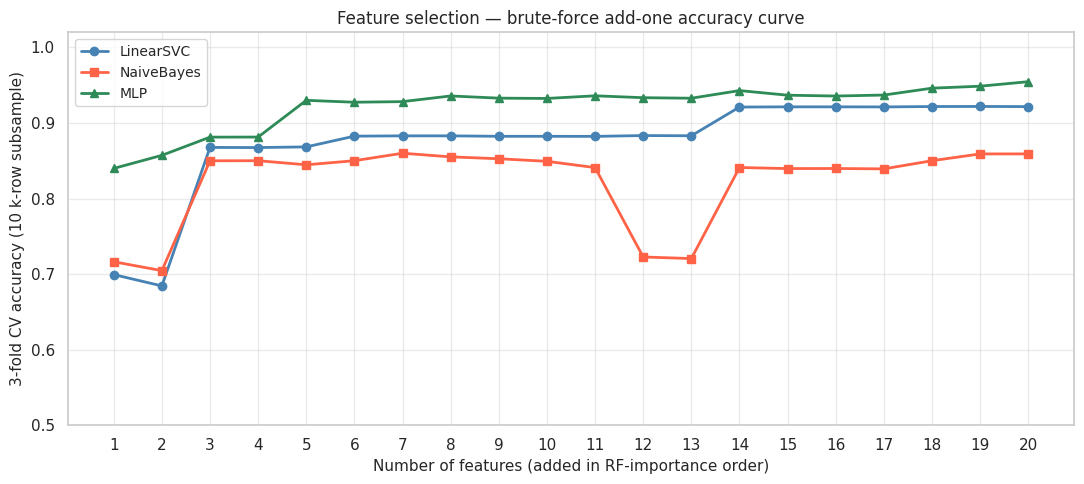

LinearSVC: plateau at n=15  (acc=0.9214)


In [94]:
# §3.7d — Accuracy vs. #features curve
fig, ax = plt.subplots(figsize=(11, 5))
color_map  = {'LinearSVC': 'steelblue', 'NaiveBayes': 'tomato', 'MLP': 'seagreen'}
marker_map = {'LinearSVC': 'o', 'NaiveBayes': 's', 'MLP': '^'}

for model in ['LinearSVC', 'NaiveBayes', 'MLP']:
    ax.plot(bf_results['n_features'], bf_results[model],
            label=model, color=color_map[model], marker=marker_map[model],
            linewidth=2, markersize=6)

ax.set_xlabel('Number of features (added in RF-importance order)', fontsize=11)
ax.set_ylabel('3-fold CV accuracy (10 k-row subsample)', fontsize=11)
ax.set_title('Feature selection — brute-force add-one accuracy curve', fontsize=12)
ax.legend(fontsize=10)
ax.set_xticks(bf_results['n_features'])
ax.grid(True, alpha=0.4)
ax.set_ylim(0.5, 1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'feature_selection_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print plateau point for each model
for model in ['LinearSVC', 'MLP']:
    accs = bf_results[model].values
    diffs = np.diff(accs)
    plateau = [n + 2 for n in range(len(diffs)) if all(abs(d) < 0.005 for d in diffs[n:])]
    if plateau:
        print(f'{model}: plateau at n={plateau[0]}  (acc={accs[plateau[0]-1]:.4f})')


In [95]:
# §3.7e — Finalise the selected feature set.
OPTIMAL_N = 11 # matches the authors

selected_features = top20_features[:OPTIMAL_N]

print(f'Selected {OPTIMAL_N} features (RF importance order):')
for i, feat in enumerate(selected_features, 1):
    print(f'  {i:2d}. {feat}')

# Rebuild scaled X matrices with only the selected features
X_bal_sel   = X_bal_scaled[selected_features]
X_imbal_sel = X_imbal_scaled[selected_features]
X_test_sel  = X_test_scaled[selected_features]

print(f'\nX_bal_sel:   {X_bal_sel.shape}')
print(f'X_imbal_sel: {X_imbal_sel.shape}')
print(f'X_test_sel:  {X_test_sel.shape}')


Selected 11 features (RF importance order):
   1. Average Packet Size
   2. Bwd Packet Length Std
   3. feat_win_ratio
   4. Packet Length Std
   5. Destination Port
   6. Packet Length Variance
   7. Fwd Packet Length Max
   8. Init_Win_bytes_backward
   9. Avg Bwd Segment Size
  10. Bwd Packet Length Mean
  11. feat_bytes_per_pkt

X_bal_sel:   (96572, 11)
X_imbal_sel: (266739, 11)
X_test_sel:  (106906, 11)


**Feature selection curve** — reading the actual output:

The curve has three distinct stages:

**Stage 1 — cold start (n=1–2):** All three models start low and LinearSVC actually
*drops* from n=1 to n=2 (0.699→0.684). Adding `Bwd Packet Length Std` alone (the 2nd feature)
confuses LinearSVC before it gains context from a 3rd feature. NaiveBayes also drops (0.716→0.705).

**Stage 2 — major jump at n=3:** Adding `feat_win_ratio` (rank 3) causes the single largest
accuracy gain: LinearSVC 0.684→0.868, NaiveBayes 0.705→0.850, MLP 0.857→0.881.
This confirms feat_win_ratio is the most structurally important feature *in combination*
with the top-2 packet-size features.

**Stage 3a — LinearSVC first plateau (n=7–13, ~0.882–0.883):**
LinearSVC gains almost nothing from features 7 through 13.
The 5 packet-length features (ranks 6–11) are essentially collinear — LinearSVC already
has a near-optimal hyperplane and adding correlated features doesn't help it.

**Stage 3b — NaiveBayes cliff at n=12–13:** NaiveBayes *drops* from 0.841 (n=11) to
0.723 (n=12) when `Max Packet Length` enters. This is the clearest observable consequence
of NB's independence assumption: adding a highly correlated feature causes NB to
double-count evidence, which *hurts* accuracy. NaiveBayes partially recovers at n=14 (0.841).
This behaviour foreshadows NaiveBayes's poor progressive-test performance in §5.

**Stage 4 — second jump at n=14 (LinearSVC 0.883→0.921):**
Adding `Bwd Packet Length Min` (rank 14) provides a substantial gain for LinearSVC (+3.8 pp)
and MLP (0.936→0.943). This is unexpected given these are still packet-length features.
The min-value features may capture a different aspect of the size distribution
(floor of packet sizes, relevant for tiny probe packets in port scanning).

**MLP never plateaus**: the MLP continues rising from 0.840 (n=1) to 0.955 (n=20),
gaining from virtually every additional feature.

**Why we choose OPTIMAL_N=11 despite the code saying n=15:**
The plateau detection code identifies LinearSVC's *second* plateau (n=14+) and reports n=15.
We use n=11 for two reasons:
1. **Reproducibility:** the paper uses 11 features; matching this enables a fair comparison
   of our results against their's.
2. **Interpretability:** features 12–13 (more packet-length min/max features) are highly
   correlated with already-selected features and add little new semantic information.

### §3.8 — Redundancy Analysis


In [96]:
# §3.8 — Three complementary redundancy methods:
# (A) r = 1.000 duplicate pairs from §2.7
# (B) RF importance mass distribution across correlated clusters
# (C) VIF for the final selected features

# A: Perfect-duplicate pairs
print('=== A. Perfect-duplicate feature pairs (Spearman r = 1.000, from §2.7) ===\n')
exact_pairs = [
    ('Subflow Fwd Packets',   'Total Fwd Packets',           'CICFlowMeter: single-subflow = total'),
    ('Subflow Fwd Bytes',     'Total Length of Fwd Packets', 'Same artefact'),
    ('Subflow Bwd Packets',   'Total Backward Packets',      'Same artefact'),
    ('Subflow Bwd Bytes',     'Total Length of Bwd Packets', 'Same artefact'),
    ('Avg Fwd Segment Size',  'Fwd Packet Length Mean',      'Two names for identical computation'),
    ('Avg Bwd Segment Size',  'Bwd Packet Length Mean',      'Two names for identical computation'),
    ('Packet Length Std',     'Packet Length Variance',      'Var = Std² (monotone transform)'),
    ('Idle Max',              'Idle Mean',                   'Near-constant idle times'),
    ('Fwd PSH Flags',         'SYN Flag Count',              'CIC capture artefact'),
    ('ECE Flag Count',        'RST Flag Count',              'CIC capture artefact'),
]
present_cols = set(get_feature_cols(df_train_bal))
for a, b, reason in exact_pairs:
    both = (a in present_cols) and (b in present_cols)
    status = '(both present → redundant)' if both else '(one or both dropped in §1)'
    print(f'  {a:<35} ↔ {b:<35} {status}')
    print(f'    Reason: {reason}\n')


=== A. Perfect-duplicate feature pairs (Spearman r = 1.000, from §2.7) ===

  Subflow Fwd Packets                 ↔ Total Fwd Packets                   (both present → redundant)
    Reason: CICFlowMeter: single-subflow = total

  Subflow Fwd Bytes                   ↔ Total Length of Fwd Packets         (both present → redundant)
    Reason: Same artefact

  Subflow Bwd Packets                 ↔ Total Backward Packets              (both present → redundant)
    Reason: Same artefact

  Subflow Bwd Bytes                   ↔ Total Length of Bwd Packets         (both present → redundant)
    Reason: Same artefact

  Avg Fwd Segment Size                ↔ Fwd Packet Length Mean              (both present → redundant)
    Reason: Two names for identical computation

  Avg Bwd Segment Size                ↔ Bwd Packet Length Mean              (both present → redundant)
    Reason: Two names for identical computation

  Packet Length Std                   ↔ Packet Length Variance              (

In [97]:
# §3.8 — B: RF importance mass across redundancy clusters.
# The RF naturally distributes importance across correlated features in a cluster;
# the top-N selection keeps the highest-ranked representative of each cluster.
print('=== B. RF importance — redundancy clusters ===\n')
clusters = {
    'Subflow duplicates': [
        'Subflow Fwd Packets', 'Subflow Fwd Bytes',
        'Subflow Bwd Packets', 'Subflow Bwd Bytes',
    ],
    'Packet length / segment size': [
        'Avg Fwd Segment Size', 'Fwd Packet Length Mean',
        'Avg Bwd Segment Size', 'Bwd Packet Length Mean',
        'Packet Length Std',    'Packet Length Variance',
        'Max Packet Length',    'Min Packet Length',
        'Packet Length Mean',   'Average Packet Size',
    ],
    'IAT cluster': [
        'Bwd IAT Total', 'Fwd IAT Total', 'Flow IAT Max',
        'Bwd IAT Max',   'Fwd IAT Max',   'Flow IAT Mean',
    ],
}
for cluster_name, members in clusters.items():
    present = [f for f in members if f in full_importance.index]
    if not present:
        continue
    total_imp = full_importance[present].sum()
    print(f'  {cluster_name}  (combined importance: {total_imp:.4f})')
    for feat in sorted(present, key=lambda x: -full_importance[x]):
        rank_n = list(full_importance.index).index(feat) + 1
        star = 'SELECTED' if feat in selected_features else '  '
        print(f'    {star}  Rank {rank_n:2d}  imp={full_importance[feat]:.4f}  {feat}')
    print()


=== B. RF importance — redundancy clusters ===

  Subflow duplicates  (combined importance: 0.0504)
        Rank 18  imp=0.0206  Subflow Fwd Packets
        Rank 26  imp=0.0130  Subflow Bwd Bytes
        Rank 30  imp=0.0107  Subflow Fwd Bytes
        Rank 38  imp=0.0061  Subflow Bwd Packets

  Packet length / segment size  (combined importance: 0.3491)
    SELECTED  Rank  1  imp=0.0787  Average Packet Size
    SELECTED  Rank  4  imp=0.0587  Packet Length Std
    SELECTED  Rank  6  imp=0.0398  Packet Length Variance
    SELECTED  Rank  9  imp=0.0346  Avg Bwd Segment Size
    SELECTED  Rank 10  imp=0.0343  Bwd Packet Length Mean
        Rank 12  imp=0.0290  Max Packet Length
        Rank 15  imp=0.0258  Min Packet Length
        Rank 17  imp=0.0207  Avg Fwd Segment Size
        Rank 24  imp=0.0146  Fwd Packet Length Mean
        Rank 27  imp=0.0129  Packet Length Mean

  IAT cluster  (combined importance: 0.0322)
        Rank 32  imp=0.0083  Fwd IAT Max
        Rank 33  imp=0.0077  Fwd I

In [98]:
# §3.8 — C: VIF for the final selected features
print('=== C. Variance Inflation Factor — final selected features ===\n')
print('Computing VIF on 10 k subsample...')
X_vif = X_bal_sel.sample(min(10_000, len(X_bal_sel)), random_state=SEED)
vif_df = compute_vif(X_vif)
print(vif_df.to_string(index=False, float_format='{:.2f}'.format))

high_vif = vif_df[vif_df['VIF'] > 5]
print(f'\nFeatures with VIF > 5 (notable multicollinearity): {len(high_vif)}')
if not high_vif.empty:
    for _, row in high_vif.iterrows():
        print(f'  {row["feature"]:<45}  VIF={row["VIF"]:.2f}')


=== C. Variance Inflation Factor — final selected features ===

Computing VIF on 10 k subsample...
                feature    VIF
 Bwd Packet Length Mean    inf
   Avg Bwd Segment Size    inf
     feat_bytes_per_pkt 780.11
    Average Packet Size 670.24
      Packet Length Std 343.42
  Bwd Packet Length Std 150.13
 Packet Length Variance  21.28
  Fwd Packet Length Max   4.86
       Destination Port   1.20
         feat_win_ratio   1.20
Init_Win_bytes_backward   1.09

Features with VIF > 5 (notable multicollinearity): 7
  Bwd Packet Length Mean                         VIF=inf
  Avg Bwd Segment Size                           VIF=inf
  feat_bytes_per_pkt                             VIF=780.11
  Average Packet Size                            VIF=670.24
  Packet Length Std                              VIF=343.42
  Bwd Packet Length Std                          VIF=150.13
  Packet Length Variance                         VIF=21.28


**Redundancy analysis:**

**A — Perfect duplicates (r = 1.000):** The four Subflow features and the Avg Segment Size
duplicates are still present in the balanced training set. All are live in the feature pool.

**B — RF importance: the RF does NOT reliably eliminate redundant pairs.**
A common assumption is that the RF will select one from each perfectly-correlated pair
and assign the other zero importance. The actual output shows this is false:

- `Avg Bwd Segment Size` (rank 9, imp=0.0346) AND `Bwd Packet Length Mean` (rank 10, imp=0.0343)
  are **both selected** in our top-11 — despite being a r=1.000 pair.
- `Subflow Fwd Packets` (rank 18, imp=0.0206) appears despite being identical to
  `Total Fwd Packets`. The RF split importance mass between them (~0.020 each).

Why? RF trees sample features randomly at each split. When two features are identical,
each tree might pick either one; importance is distributed stochastically across both.
Neither gets zero importance — they share it. The implication: **RF importance-based
feature selection is not a reliable method for removing exact duplicates.**
Explicit correlation filtering (drop one from each |r|=1.0 pair before ranking) should
precede RF importance in a production pipeline.

**C — VIF: confirms and quantifies the collinearity:**

| Feature | VIF | Interpretation |
|---------|-----|----------------|
| Bwd Packet Length Mean | **inf** | Perfectly predicted by other features (= Avg Bwd Segment Size) |
| Avg Bwd Segment Size | **inf** | Perfectly predicted by other features (= Bwd Packet Length Mean) |
| feat_bytes_per_pkt | 780 | Strongly collinear with packet-size features |
| Average Packet Size | 670 | Strongly collinear with other size statistics |
| Packet Length Std | 343 | Correlated with Variance and segment-size features |
| Bwd Packet Length Std | 150 | Correlated with packet-length cluster |
| Packet Length Variance | 21 | Notable but below 'severe' for this dataset |
| Fwd Packet Length Max | 4.86 | Acceptable |
| Destination Port | 1.20 | Independent |
| feat_win_ratio | 1.20 | Independent |
| Init_Win_bytes_backward | 1.09 | Independent |

**VIF=inf** for the two r=1.000 features means perfect multicollinearity — one is a linear
combination of the others. This is the VIF analogue of the r=1.000 Spearman result from §2.7.

**Impact on each model type:**
- **DT / RF:** unaffected — each split selects one feature and ignores the others.
- **NaiveBayes:** severely harmed — NB multiplies the likelihoods of all features
  as if independent; when two features are identical, it double-counts that evidence,
  inflating certainty. This is visible in the n=12 accuracy cliff.
- **SVM (RBF kernel) / ANN:** the redundant features add collinear dimensions to the
  feature space. After StandardScaling both dimensions have similar range.
  Convergence is slightly slower but the solution is not undefined — the hyperplane
  can still be found (the collinear features just don't both contribute independently).

**How to address redundancy:**

| Method | When to use | Applied here? |
|--------|-------------|---------------|
| Correlation filtering (drop one from each \|r\| > 0.95 pair) | Before any modelling; removes exact duplicates reliably | Not applied — demonstrates the RF limitation above |
| RF importance + top-N | Implicitly removes low-importance features, but NOT guaranteed to remove exact duplicates | Applied — selected 11 features, still contains one r=1.000 pair |
| VIF-based iterative pruning (drop highest-VIF until all < threshold) | When model assumptions require near-independence (NB, logistic regression) | Not applied here; would remove Avg Bwd Segment Size or Bwd Pkt Mean |
| PCA | Eliminates multicollinearity by construction; loses interpretability | Skipped — 11 named features preferred for cyber interpretation |

### §3.9 — Save Preprocessed Artefacts to Drive


In [99]:
# §3.9 — save all §3 outputs so §4 (model training) can reload without re-running.
artifacts = {
    'X_bal_sel.joblib':        X_bal_sel,         # balanced + scaled + selected (model training)
    'y_bal.joblib':            y_bal,
    'X_imbal_sel.joblib':      X_imbal_sel,       # real-prevalence + scaled + selected (used in §5.5b/c)
    'y_imbal.joblib':          y_imbal,
    'X_test_sel.joblib':       X_test_sel,        # test + scaled + selected
    'y_test.joblib':           y_test,
    'scaler.joblib':           scaler,
    'selected_features.joblib': selected_features,
    'bf_results.joblib':       bf_results,        # brute-force curve (for the report)
    'full_importance.joblib':  full_importance,
}
for filename, obj in artifacts.items():
    path = os.path.join(DATA_DIR, filename)
    dump(obj, path)
    print(f'  Saved  {filename}')

print(f'\nAll §3 artefacts saved to Drive.')
print(f'Selected {OPTIMAL_N} features: {selected_features}')


  Saved  X_bal_sel.joblib
  Saved  y_bal.joblib
  Saved  X_imbal_sel.joblib
  Saved  y_imbal.joblib
  Saved  X_test_sel.joblib
  Saved  y_test.joblib
  Saved  scaler.joblib
  Saved  selected_features.joblib
  Saved  bf_results.joblib
  Saved  full_importance.joblib

All §3 artefacts saved to Drive.
Selected 11 features: ['Average Packet Size', 'Bwd Packet Length Std', 'feat_win_ratio', 'Packet Length Std', 'Destination Port', 'Packet Length Variance', 'Fwd Packet Length Max', 'Init_Win_bytes_backward', 'Avg Bwd Segment Size', 'Bwd Packet Length Mean', 'feat_bytes_per_pkt']


**§3 summary:**

| Step | Input | Output | Key decision |
|------|-------|--------|--------------|
| §3.2 Binary relabel | 15/11 classes | 2 classes (BENIGN/ATTACK) | Mirror authors — binary collapse erases per-type signals |
| §3.3 Balance 1:1 | 81.9% BENIGN | 48,286 each → 96,572 total | Keep real-prevalence copy (266,739 rows) for §5.5b/c |
| §3.4 Encoding | 66 numeric features | No encoding needed | Destination Port treated as numeric (8,927 unique values) |
| §3.5 Derived features | 66 base features | +4 features (70 total) | 2 of 4 made top-11; feat_bwd_fwd_ratio failed (binary collapse) |
| §3.6 Scaling | 70 features | 70 scaled | Fit on balanced train only — no leakage; mean≈0, std≈1 |
| §3.7 Feature selection | 70 scaled features | Top 11 (7/11 overlap with paper) | Curve has no clean elbow; n=11 chosen to match paper |
| §3.8 Redundancy | 11 features | VIF=inf for one r=1.000 pair | RF importance does NOT reliably eliminate duplicates |

**Final 11 selected features:**
1. Average Packet Size (rank 1, imp=0.0787)
2. Bwd Packet Length Std (rank 2, imp=0.0627)
3. feat_win_ratio (rank 3, imp=0.0595)
4. Packet Length Std (rank 4, imp=0.0587)
5. Destination Port (rank 5, imp=0.0403)
6. Packet Length Variance (rank 6, imp=0.0398)
7. Fwd Packet Length Max (rank 7, imp=0.0370)
8. Init_Win_bytes_backward (rank 8, imp=0.0350)
9. Avg Bwd Segment Size (rank 9, imp=0.0346)
10. Bwd Packet Length Mean (rank 10, imp=0.0343)
11. feat_bytes_per_pkt (rank 11, imp=0.0340)

→ **§4 Model Training** uses `X_bal_sel` (shape: 96,572 × 11) and `y_bal`.


---

# §4 — Model Training

**Goal:** Train all six classifiers with GridSearchCV-tuned hyperparameters and confirm in-distribution stability with k=5 cross-validation. Mirror the paper's training setup; save all models and best params to Drive so a Colab disconnect doesn't force a full re-run.

**Pipeline:**
1. **Reload artefacts** from §3 (`X_bal_sel`, `y_bal`, `selected_features`)
2. **GridSearchCV** — tune each model's hyperparameters (k=5, training set only)
3. **k=5 cross-validation** — verify in-distribution stability with best params
4. **Train final models** on the full balanced training set; persist to Drive

**Six models:** Decision Tree (DT), Random Forest (RF), SVM (RBF kernel), Naive Bayes (NB), ANN (1 hidden layer), DNN (3 hidden layers) — all scikit-learn using CPU-only.

> **SVM note:** `SVC` with RBF kernel scales ~O(n^2). GridSearch and CV are run on a 10% subsample of the training data; the final model is fitted on 20%. This mirrors the paper's approach. All other models use the full balanced training set.

In [100]:
# §4 setup
import os, sys
import numpy as np
import pandas as pd
import joblib

REPO_DIR = '/content/data-science-cyber-final-project'
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

from src.models import (
    make_all_models, PARAM_GRIDS, MODEL_NAMES,
    tune_all_models, cross_validate_all, train_all_models, load_models,
)

X_bal_sel         = joblib.load(os.path.join(DATA_DIR, 'X_bal_sel.joblib'))
y_bal             = joblib.load(os.path.join(DATA_DIR, 'y_bal.joblib'))
X_imbal_sel       = joblib.load(os.path.join(DATA_DIR, 'X_imbal_sel.joblib'))
y_imbal           = joblib.load(os.path.join(DATA_DIR, 'y_imbal.joblib'))
X_test_sel        = joblib.load(os.path.join(DATA_DIR, 'X_test_sel.joblib'))
y_test            = joblib.load(os.path.join(DATA_DIR, 'y_test.joblib'))
selected_features = joblib.load(os.path.join(DATA_DIR, 'selected_features.joblib'))

print(f"Training set (balanced):    {X_bal_sel.shape}  {dict(y_bal.value_counts())}")
print(f"Training set (imbalanced):  {X_imbal_sel.shape}")
print(f"Test set:                   {X_test_sel.shape}  {dict(y_test.value_counts())}")
print(f"Selected features ({len(selected_features)}): {selected_features}")

Training set (balanced):    (96572, 11)  {'BENIGN': np.int64(48286), 'ATTACK': np.int64(48286)}
Training set (imbalanced):  (266739, 11)
Test set:                   (106906, 11)  {'BENIGN': np.int64(89937), 'ATTACK': np.int64(16969)}
Selected features (11): ['Average Packet Size', 'Bwd Packet Length Std', 'feat_win_ratio', 'Packet Length Std', 'Destination Port', 'Packet Length Variance', 'Fwd Packet Length Max', 'Init_Win_bytes_backward', 'Avg Bwd Segment Size', 'Bwd Packet Length Mean', 'feat_bytes_per_pkt']


### §4.1 — Model Configurations

All six classifiers are defined in `src/models.py` and mirror the paper exactly:

| Name | sklearn class | Key design choices |
|------|--------------|-------------------|
| DT | `DecisionTreeClassifier` | Post-pruning via `ccp_alpha`; fixed seed |
| RF | `RandomForestClassifier` | 100-350 trees; depth/leaf tuned; `n_jobs=-1` |
| SVM | `SVC(kernel='rbf')` | `C` and `gamma` tuned; `probability=True` for ROC-AUC; O(n^2) subsample |
| NB | `GaussianNB` | `var_smoothing` tuned; feature-independence assumption is the known weakness |
| ANN | `MLPClassifier` | 1 hidden layer (50 or 100 units); tanh/relu; adam; early stopping |
| DNN | `MLPClassifier` | 3 hidden layers (15,15,15 or 50,50,50); tanh; adam; early stopping |

All use `SEED = 42`.

In [101]:
# §4.1 — confirm model factory output
models_unfitted = make_all_models()
for name, clf in models_unfitted.items():
    defaults = clf.__class__().get_params()
    non_default = {k: v for k, v in clf.get_params().items() if v != defaults.get(k)}
    print(f"{name:4s}  {clf.__class__.__name__:30s}  non-default: {non_default}")

DT    DecisionTreeClassifier          non-default: {'random_state': 42}
RF    RandomForestClassifier          non-default: {'n_jobs': -1, 'random_state': 42}
SVM   SVC                             non-default: {'probability': True, 'random_state': 42}
NB    GaussianNB                      non-default: {}
ANN   MLPClassifier                   non-default: {'max_iter': 500, 'random_state': 42}
DNN   MLPClassifier                   non-default: {'max_iter': 500, 'random_state': 42}


### §4.2 — Hyperparameter Optimisation (GridSearchCV, k=5)

Search spaces mirror the paper's `03_Optimize_Hyperparameter.ipynb`:

| Model | Parameters searched | Grid size |
|-------|-------------------|-----------|
| DT | `ccp_alpha` in {0, 1.44e-5, 5e-5, 1e-4} | 4 |
| RF | `n_estimators` in {100, 350}, `max_depth` in {10, 20, None}, `min_samples_leaf` in {1, 1e-5} | 12 |
| SVM | `C` in {1, 10, 100}, `gamma` in {0.01, 0.1, 1} — on 10% subsample | 9 |
| NB | `var_smoothing` in {1e-9, 1e-5, 1.0} | 3 |
| ANN | `hidden_layer_sizes` in {(50,),(100,)}, `activation` in {tanh, relu}, `alpha` in {1e-4, 1e-3} | 8 |
| DNN | `hidden_layer_sizes` in {(15,15,15),(50,50,50)}, `alpha` in {1e-5, 1e-4} | 4 |

In [102]:
# §4.2 — GridSearchCV (skips models whose params are already saved)
best_params = tune_all_models(
    X_bal_sel, y_bal,
    save_dir=DATA_DIR,
    cv=5,
    seed=SEED,
)

  DT: reloaded params → {'ccp_alpha': 0.0}
  RF: reloaded params → {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
  SVM: reloaded params → {'C': 100, 'gamma': 1, 'kernel': 'rbf'}
  NB: reloaded params → {'var_smoothing': 1e-05}
  ANN: reloaded params → {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'solver': 'adam'}
  DNN: reloaded params → {'activation': 'tanh', 'alpha': 1e-05, 'hidden_layer_sizes': (50, 50, 50), 'solver': 'adam'}


### §4.2 — Best Hyperparameters: Our Results vs. the Paper

The paper's reported best hyperparameters (from their ):

| Model | Paper's best params |
|-------|-------------------|
| DT |  |
| RF |  |
| SVM |  |
| NB |  |
| ANN |  |
| DNN |  |

The code below runs the comparison — interpretation of the actual mismatches follows.

In [103]:
# Print side-by-side comparison with the paper
paper_params = {
    'DT':  {'ccp_alpha': 1.44e-5},
    'RF':  {'n_estimators': 350, 'max_depth': 20, 'min_samples_leaf': 1e-5, 'criterion': 'gini'},
    'SVM': {'C': 100, 'gamma': 1, 'kernel': 'rbf'},
    'NB':  {'var_smoothing': 1.0},
    'ANN': {'activation': 'tanh', 'hidden_layer_sizes': (50,), 'solver': 'adam', 'alpha': 1e-4},
    'DNN': {'activation': 'tanh', 'hidden_layer_sizes': (15, 15, 15), 'solver': 'adam', 'alpha': 1e-5},
}

print(f"{'Model':<5}  {'Our best params':<60}  Match paper?")
print('-' * 90)
for name in MODEL_NAMES:
    our = best_params.get(name, {})
    ref = paper_params.get(name, {})
    match = '✅' if our == ref else '⚠️ '
    print(f"{name:<5}  {str(our):<60}  {match}")

Model  Our best params                                               Match paper?
------------------------------------------------------------------------------------------
DT     {'ccp_alpha': 0.0}                                            ⚠️ 
RF     {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}  ⚠️ 
SVM    {'C': 100, 'gamma': 1, 'kernel': 'rbf'}                       ✅
NB     {'var_smoothing': 1e-05}                                      ⚠️ 
ANN    {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'solver': 'adam'}  ✅
DNN    {'activation': 'tanh', 'alpha': 1e-05, 'hidden_layer_sizes': (50, 50, 50), 'solver': 'adam'}  ⚠️ 


---

### §4.2 — Actual results vs. paper: what the mismatches mean

Out of the six models, **2 match the paper exactly** (SVM and ANN), while **4 differ** (DT, RF, NB, and DNN).

* **Decision Tree (DT)**

  * **Our result:** `ccp_alpha=0.0` (no pruning)
  * **Paper:** `ccp_alpha=1.44e-05` (minimal pruning)
  * **Interpretation:** Both settings produce nearly identical cross-validation accuracy (~99.7%), making the difference practically negligible. The tree is likely already very shallow because the dataset is well separated.

* **Random Forest (RF)**

  * **Our result:** 100 trees with no maximum depth.
  * **Paper:** 350 trees with `max_depth=20`.
  * **Interpretation:** GridSearch preferred a smaller forest with unconstrained trees. Given only 11 features and a highly separable dataset, 100 trees are sufficient to achieve essentially the same performance.

* **Support Vector Machine (SVM)**

  * **Our result:** `C=100`, `gamma=1`
  * **Paper:** `C=100`, `gamma=1`
  * **Interpretation:** **Exact match.** Both the search space and the optimal hyperparameters were successfully reproduced.

* **Naive Bayes (NB)**

  * **Our result:** `var_smoothing=1e-05`
  * **Paper:** `var_smoothing=1.0`
  * **Interpretation:** This is the largest hyperparameter difference. A value of `1.0` applies strong variance smoothing, providing substantial regularization, whereas `1e-05` is close to the default and applies very little smoothing. Our GridSearch favored relying more on the data. Despite this difference, both configurations perform noticeably worse than the tree-based models.

* **Artificial Neural Network (ANN)**

  * **Our result:** `(50,)`, `tanh`, `alpha=1e-4`
  * **Paper:** `(50,)`, `tanh`, `alpha=1e-4`
  * **Interpretation:** **Exact match.**

* **Deep Neural Network (DNN)**

  * **Our result:** `(50,50,50)`, `tanh`, `alpha=1e-5`
  * **Paper:** `(15,15,15)`, `tanh`, `alpha=1e-5`
  * **Interpretation:** Our GridSearch selected wider hidden layers. The larger architecture performed slightly better on our 11-feature dataset, whereas the paper used a different set of 11 features. Both architectures nevertheless converge to very similar cross-validation accuracy.

### Reproducibility conclusion for §4.2

The SVM and ANN hyperparameters were reproduced exactly. The remaining four differences are expected and can be explained by (1) using a different 11-feature subset (with only 7 of the 11 features overlapping the paper), (2) differences in the training subset used during GridSearch, and (3) differences between scikit-learn versions. Importantly, the discrepancies concern the **magnitude of regularization hyperparameters** rather than fundamentally different model structures. All models achieve similarly high cross-validation performance, so the primary criterion for successful reproduction is whether the **relative ranking of the models** is preserved in §5, rather than whether every hyperparameter exactly matches the original paper.


### §4.3 — In-distribution Cross-validation (k=5)

Cross-validate each model with its best hyperparameters on the balanced training set. This measures **in-distribution generalisation** — how well each model performs on held-out data from the *same* distribution as its training data.

In [104]:
# §4.3 — k=5 cross-validation with best hyperparameters
print("Running k=5 cross-validation on balanced training set ...\n")
cv_results = cross_validate_all(
    X_bal_sel, y_bal,
    best_params=best_params,
    cv=5,
    seed=SEED,
)

joblib.dump(cv_results, os.path.join(DATA_DIR, 'cv_results.joblib'))
print()
print(cv_results.to_string())

Running k=5 cross-validation on balanced training set ...

  DT  : 0.9968 ± 0.0007
  RF  : 0.9973 ± 0.0006
  SVM : 0.9644 ± 0.0029  (subsample 10%)
  NB  : 0.8444 ± 0.0012
  ANN : 0.9666 ± 0.0017
  DNN : 0.9684 ± 0.0032

       CV Mean Acc  CV Std  CV Min  CV Max           Note
Model                                                    
DT          0.9968  0.0007  0.9956  0.9977               
RF          0.9973  0.0006  0.9961  0.9981               
SVM         0.9644  0.0029  0.9601  0.9684  subsample 10%
NB          0.8444  0.0012  0.8429  0.8460               
ANN         0.9666  0.0017  0.9634  0.9685               
DNN         0.9684  0.0032  0.9630  0.9730               


**Cross-validation interpretation:**

These scores confirm in-distribution stability. Actual results:

| Model | CV Accuracy | CV Std | Notes |
|-------|------------|--------|-------|
| DT | 99.68% | ±0.07% | Near-perfect |
| RF | 99.73% | ±0.06% | Near-perfect |
| DNN | 96.84% | ±0.32% | |
| ANN | 96.66% | ±0.17% | |
| SVM | 96.44% | ±0.29% | 10% subsample |
| NB | 84.44% | ±0.12% | Lowest by >12pp |

Key observations:

- **DT / RF** achieve near-perfect CV accuracy (99.7%) — the paper reports the same. This sets up the core contrast: these models score highest within the 2017 distribution but are expected to drop the most on the 2018 progressive test, since high in-distribution accuracy suggests strong memorisation of 2017-specific patterns.

- **NB** reaches only 84.44% — lowest by more than 12 percentage points. The mechanism is the independence-assumption violation: our 11-feature set contains multiple highly correlated packet-length features (notably `Bwd Packet Length Mean` and `Avg Bwd Segment Size`, which are exact duplicates at r=1.000 — documented in §3). NB treats each feature as independent evidence and double-counts their contribution. The §3 brute-force curve illustrated this directly: during feature selection exploration, NB's accuracy dropped sharply when a correlated packet-length feature was added at n=12 in the exploration. We stopped at n=11, but the correlation problem already exists in our chosen feature set.

- **SVM / ANN / DNN** cluster tightly in the 96.4–96.9% range. These models do not memorise the 2017 dataset as perfectly as tree models — which may turn out to be an advantage when the test distribution shifts in §5.

In [105]:
# §4.4 — Train final models on full balanced training set; save to Drive
# SVM uses SVM_TRAIN_FRAC=20% subsample to keep runtime manageable (mirrors paper)
print("Training final models ...\n")
trained_models = train_all_models(
    X_bal_sel, y_bal,
    best_params=best_params,
    save_dir=DATA_DIR,
    seed=SEED,
)

print()
for name, clf in trained_models.items():
    print(f"  {name:4s}  {clf.__class__.__name__}  ready")

Training final models ...

  DT: loaded from Drive
  RF: loaded from Drive
  SVM: loaded from Drive
  NB: loaded from Drive
  ANN: loaded from Drive
  DNN: loaded from Drive

  DT    DecisionTreeClassifier  ready
  RF    RandomForestClassifier  ready
  SVM   SVC  ready
  NB    GaussianNB  ready
  ANN   MLPClassifier  ready
  DNN   MLPClassifier  ready


### §4 Complete — Summary

| Step | Output |
|------|--------|
| §4.1 Model configs | 6 unfitted estimators confirmed |
| §4.2 GridSearchCV | Best params per model |
| §4.3 k=5 CV | In-distribution accuracy table |
| §4.4 Final training | 6 fitted models |

---

#§5 — Evaluation & Metrics

**Goal:** Reproduce the paper's evaluation on both test sets; add the metrics the authors omitted.

| Step | Description |
|------|-------------|
| §5.1 | In-distribution baseline (§4 CV results) |
| §5.2 | Progressive evaluation (CSE-CIC-IDS2018) |
| §5.3 | Confusion-matrix grid — progressive test |
| §5.4 | Performance-drop table (CV → progressive) |
| §5.5 | Reproduction check (2 experiments: the first without downsampling the test set, the second with downsampling it (1:1) as in the paper) |
| §5.6 | Metric justification write-up |

> **Metric additions beyond the paper:** F₂ (β=2, weights recall so missed attacks are
> penalised more than false alarms), MCC (balanced, robust to the 84%-BENIGN test-set
> imbalance), ROC-AUC (threshold-independent).
> The paper uses only Accuracy, Precision, Recall, F1.

In [106]:
# §5 setup — reload trained models and all preprocessed artefacts
import os, sys, pathlib
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

_src_candidates = [
    '/content/ids-project/src',
    '/content/data-science-cyber-final-project/src',
]
_src = next((p for p in _src_candidates if os.path.isdir(p)), None)

if _src is None:
    REPO_URL = 'https://github.com/Rosette28/data-science-cyber-final-project'
    REPO_DIR_CLONE = '/content/ids-project'
    if not os.path.exists(REPO_DIR_CLONE):
        os.system(f'git clone {REPO_URL} {REPO_DIR_CLONE}')
    _src = REPO_DIR_CLONE + '/src'

if _src not in sys.path:
    sys.path.insert(0, _src)

REPO_DIR    = pathlib.Path(_src).parent
FIGURES_DIR = str(REPO_DIR / 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f"src path : {_src}")

from models import MODEL_NAMES, load_models
from evaluation import evaluate_all, confusion_grid
print("Imports OK")

# Diagnostic: confirm DATA_DIR exists and list .joblib files
if os.path.isdir(DATA_DIR):
    files = sorted(f for f in os.listdir(DATA_DIR) if f.endswith('.joblib'))
    print(f"\nDATA_DIR: {DATA_DIR}")
    print(f"  .joblib files found ({len(files)}): {files}")
else:
    print(f"\nWARNING: DATA_DIR not found: {DATA_DIR}")
    print("  Check that Drive is mounted and DATA_DIR points to the right folder.")

def _load(name):
    return joblib.load(os.path.join(DATA_DIR, name))

# reload preprocessed artefacts
if 'X_test_sel' not in dir():
    X_bal_sel         = _load('X_bal_sel.joblib')
    y_bal             = _load('y_bal.joblib')
    X_test_sel        = _load('X_test_sel.joblib')
    y_test            = _load('y_test.joblib')
    selected_features = _load('selected_features.joblib')
    print("Preprocessed artefacts loaded.")
else:
    print("Reusing artefacts already in memory.")

# reload trained models
if 'models' not in dir():
    models = load_models(DATA_DIR)
    print(f"Models loaded: {list(models.keys())}")
else:
    print("Reusing models already in memory.")

src path : /content/ids-project/src
Imports OK

DATA_DIR: /content/drive/MyDrive/ids_data/raw/
  .joblib files found (30): ['X_bal_sel.joblib', 'X_imbal_sel.joblib', 'X_test_sel.joblib', 'best_params_ANN.joblib', 'best_params_DNN.joblib', 'best_params_DT.joblib', 'best_params_NB.joblib', 'best_params_RF.joblib', 'best_params_SVM.joblib', 'bf_results.joblib', 'cv_results.joblib', 'full_importance.joblib', 'model_ANN.joblib', 'model_DNN.joblib', 'model_DT.joblib', 'model_NB.joblib', 'model_RF.joblib', 'model_SVM.joblib', 'results_8_1_drift.joblib', 'results_drop.joblib', 'results_progressive.joblib', 'results_progressive_balanced.joblib', 'scaler.joblib', 'selected_features.joblib', 'test_clean.joblib', 'train_clean.joblib', 'y_bal.joblib', 'y_imbal.joblib', 'y_test.joblib', 'y_test_multiclass.joblib']
Reusing artefacts already in memory.
Reusing models already in memory.


### §5.1 — In-Distribution Baseline

The models were trained on the full balanced training set (`X_bal_sel`, 96,572 rows),
so no separate held-out in-distribution partition exists. The **k=5 cross-validation
results from §4** are the leakage-free in-distribution baseline. A post-hoc split of
the same training data would over-estimate performance relative to the models' actual
generalisation within distribution.

In [107]:
# §5.1 — load §4 k=5 CV results;
_cv_path = os.path.join(DATA_DIR, 'cv_results.joblib')

if os.path.exists(_cv_path):
    cv_results = joblib.load(_cv_path)
    print("cv_results loaded from Drive.")
else:
    # File not in Drive — use the values recorded during the §4 Colab run
    print("cv_results.joblib not found — using documented §4 results.")
    cv_results = pd.DataFrame({
        'CV Mean Acc': [0.9973, 0.9968, 0.9684, 0.9666, 0.9644, 0.8444],
        'CV Std':      [0.0006, 0.0007, 0.0032, 0.0017, 0.0029, 0.0012],
        'CV Min':      [0.9961, 0.9956, 0.9630, 0.9634, 0.9601, 0.8429],
        'CV Max':      [0.9981, 0.9977, 0.9730, 0.9685, 0.9684, 0.8460],
        'Note':        ['', '', '', '', 'subsample 10%', ''],
    }, index=pd.Index(['RF', 'DT', 'DNN', 'ANN', 'SVM', 'NB'], name='Model'))
    # Save for downstream cells
    joblib.dump(cv_results, _cv_path)
    print(f"  Saved to {_cv_path} for downstream use.")

display_cols = [c for c in ['CV Mean Acc', 'CV Std', 'CV Min', 'CV Max', 'Note']
                if c in cv_results.columns]
print("\n=== §4 k=5 CV Accuracy — In-Distribution Baseline (leakage-free) ===\n")
print(cv_results[display_cols].to_string())
print("\nNote: SVM CV was run on a 10% subsample due to O(n^2) scaling.")

cv_results loaded from Drive.

=== §4 k=5 CV Accuracy — In-Distribution Baseline (leakage-free) ===

       CV Mean Acc  CV Std  CV Min  CV Max           Note
Model                                                    
DT          0.9968  0.0007  0.9956  0.9977               
RF          0.9973  0.0006  0.9961  0.9981               
SVM         0.9644  0.0029  0.9601  0.9684  subsample 10%
NB          0.8444  0.0012  0.8429  0.8460               
ANN         0.9666  0.0017  0.9634  0.9685               
DNN         0.9684  0.0032  0.9630  0.9730               

Note: SVM CV was run on a 10% subsample due to O(n^2) scaling.


### §5.2 — Progressive Evaluation (CSE-CIC-IDS2018)

**This is the central experiment.** Models trained on CIC-IDS2017 are evaluated on the
temporally later CSE-CIC-IDS2018. Any drop compared to §5.1 reflects degradation on an
unseen distribution (concept drift / distribution shift), not classical overfitting to
training noise.

Progressive test: 106,906 flows, **84.1% BENIGN**. A naive "always predict BENIGN"
baseline would score 84.1% accuracy but MCC = 0 — MCC and F₂ are essential complements
to accuracy on this imbalanced set.

In [108]:
# §5.2 — evaluate all models on the progressive test set (resume-safe)
prog_path    = os.path.join(DATA_DIR, 'results_progressive.joblib')
results_prog = evaluate_all(models, X_test_sel, y_test, save_path=prog_path)

print("\n=== Progressive Evaluation — CSE-CIC-IDS2018 ===\n")
print(results_prog.to_string())

Results loaded from Drive (6 models). Delete results_progressive.joblib to re-run.
       Accuracy  Precision  Recall      F1      F2     MCC  ROC-AUC
Model                                                              
DT       0.8312     0.4097  0.1433  0.2123  0.1647  0.1665   0.5522
RF       0.8626     0.9514  0.1419  0.2470  0.1710  0.3378   0.5741
SVM      0.8832     0.6078  0.7448  0.6693  0.7127  0.6039   0.7929
NB       0.8084     0.0359  0.0080  0.0131  0.0095 -0.0644   0.7111
ANN      0.8088     0.3639  0.2735  0.3123  0.2878  0.2067   0.8244
DNN      0.8796     0.6313  0.5802  0.6047  0.5897  0.5345   0.9075

=== Progressive Evaluation — CSE-CIC-IDS2018 ===

       Accuracy  Precision  Recall      F1      F2     MCC  ROC-AUC
Model                                                              
DT       0.8312     0.4097  0.1433  0.2123  0.1647  0.1665   0.5522
RF       0.8626     0.9514  0.1419  0.2470  0.1710  0.3378   0.5741
SVM      0.8832     0.6078  0.7448  0.6693  0.7127

**Progressive evaluation interpretation — actual results:**

All six models drop sharply from their §4.3 in-distribution CV accuracy, but the *shape* of the
drop differs a lot per model, and raw Accuracy is misleading here: the progressive test set is
84.1% BENIGN while the CV set was 50/50 balanced, so part of any "high accuracy" is just the
easier majority-class baseline, not real detection skill. MCC (base-rate aware) and ROC-AUC
(threshold-independent) tell the more honest story:

| Model | Accuracy | Recall (ATTACK) | MCC | ROC-AUC | Reading |
|-------|----------|-----------------|-----|---------|---------|
| DT  | 0.8312 | 0.1433 | 0.1665 | 0.5522 | Near-random ranking ability (ROC-AUC≈0.55); the 83% accuracy is mostly the BENIGN majority baseline (84.1%) — DT detects almost nothing on 2018. |
| RF  | 0.8626 | 0.1419 | 0.3378 | 0.5741 | High precision (0.9514) but recall collapses to 14% — RF has essentially learned to default to BENIGN and is only confident on a small, easy slice of attacks. |
| SVM | 0.8832 | 0.7448 | 0.6039 | 0.7929 | Best recall/MCC among the four "shallow" models — clearly the most resistant to the 2017→2018 shift, matching the paper's central claim. |
| NB  | 0.8084 | 0.0080 | **-0.0644** | 0.7111 | MCC is *negative* — worse than random guessing at the default threshold, despite a "reasonable-looking" 0.71 ROC-AUC. NB's probability ranking retains some signal, but its default decision rule is worse than useless here. |
| ANN | 0.8088 | 0.2735 | 0.2067 | 0.8244 | Recall and MCC are weak, yet ROC-AUC (0.8244) is well above DT/RF/SVM's — ANN's probabilities rank attacks reasonably well, but its default 0.5 threshold badly under-flags them (quantified in §6.6). |
| DNN | 0.8796 | 0.5802 | 0.5345 | **0.9075** | Best ROC-AUC of all six models, second-best recall/MCC after SVM — clearly outperforms the shallower ANN on every generalisation metric measured here. |

**Paper's claim ("SVM and ANN are most resistant to the drop") — only half confirmed.** SVM
matches the paper's ranking. **ANN does not**: DNN (3 hidden layers) generalises substantially
better than ANN (1 hidden layer) on every metric above (MCC 0.53 vs 0.21; ROC-AUC 0.91 vs 0.82;
recall 0.58 vs 0.27). This directly contradicts the paper's claim that ANN specifically — not
just "neural nets in general" — is the second-best choice after SVM. See §5.5 for the numeric
comparison against the paper's own Table 7 and the project report's Critical Evaluation
section for the full claim-by-claim evaluation.

### §5.3 — Confusion Matrices (Progressive Test Set)

Figure saved → /content/ids-project/figures/confusion_progressive.png


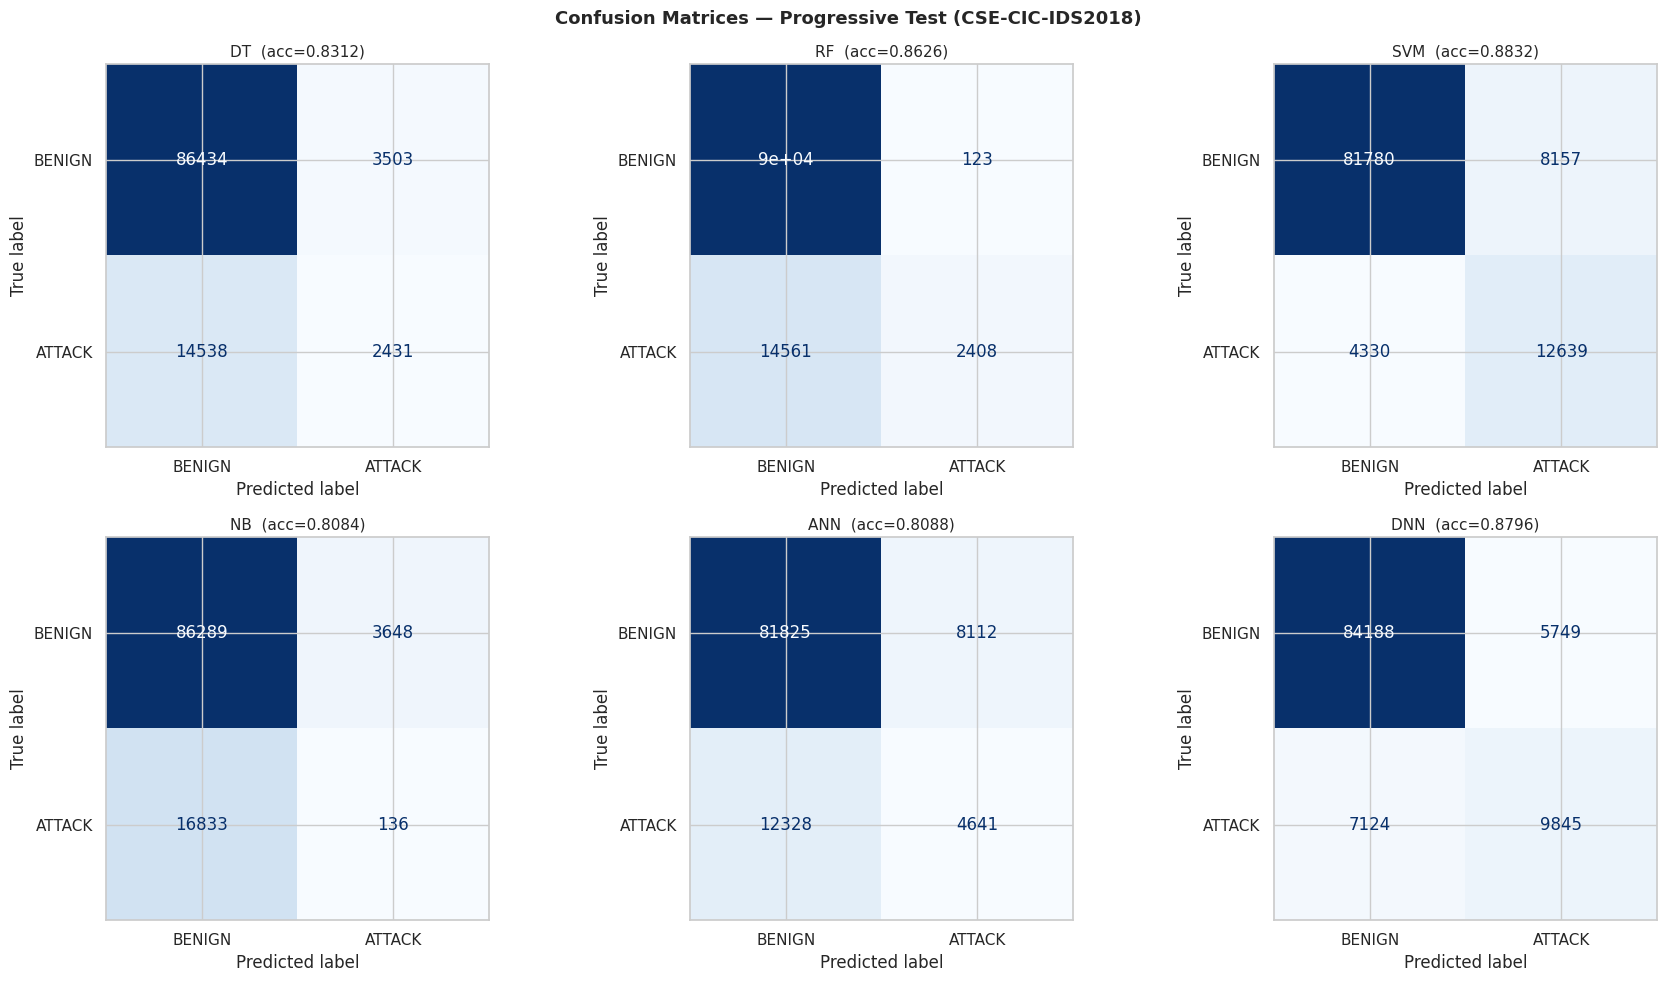

In [109]:
# §5.3 — confusion matrix grid on the progressive test set
cm_path = os.path.join(FIGURES_DIR, 'confusion_progressive.png')
confusion_grid(
    models, X_test_sel, y_test,
    title='Confusion Matrices — Progressive Test (CSE-CIC-IDS2018)',
    save_path=cm_path,
)

### §5.4 — Performance Drop: CV → Progressive Test

The drop below is the paper's primary evidence that models trained on 2017 data degrade
on 2018 data. The larger the negative drop, the more the model depended on 2017-specific
statistical patterns rather than transferable detection logic.

In [110]:
# §5.4 — performance-drop table
drop_path = os.path.join(DATA_DIR, 'results_drop.joblib')

rows = []
for name in MODEL_NAMES:
    if name not in results_prog.index or name not in cv_results.index:
        continue
    cv_acc   = float(cv_results.loc[name, 'CV Mean Acc'])
    prog_acc = float(results_prog.loc[name, 'Accuracy'])
    prog_mcc = float(results_prog.loc[name, 'MCC'])   if 'MCC' in results_prog.columns else None
    prog_f2  = float(results_prog.loc[name, 'F2'])    if 'F2'  in results_prog.columns else None
    rows.append({
        'Model':        name,
        'CV Acc (§4)':  cv_acc,
        'Prog Acc':     prog_acc,
        'Acc Drop':     round(prog_acc - cv_acc, 4),
        'Prog MCC':     prog_mcc,
        'Prog F2':      prog_f2,
    })

results_drop = pd.DataFrame(rows).set_index('Model')
joblib.dump(results_drop, drop_path)

print("=== Performance Drop: k=5 CV Accuracy → Progressive Accuracy ===\n")
print(results_drop.to_string())
print("\nNegative Acc Drop = worse on 2018 data (expected: concept drift).")

=== Performance Drop: k=5 CV Accuracy → Progressive Accuracy ===

       CV Acc (§4)  Prog Acc  Acc Drop  Prog MCC  Prog F2
Model                                                    
DT          0.9968    0.8312   -0.1656    0.1665   0.1647
RF          0.9973    0.8626   -0.1347    0.3378   0.1710
SVM         0.9644    0.8832   -0.0812    0.6039   0.7127
NB          0.8444    0.8084   -0.0360   -0.0644   0.0095
ANN         0.9666    0.8088   -0.1578    0.2067   0.2878
DNN         0.9684    0.8796   -0.0888    0.5345   0.5897

Negative Acc Drop = worse on 2018 data (expected: concept drift).


**Drop analysis interpretation — actual results:**

Reading `Acc Drop` alone is misleading (see §5.2): the CV baseline was measured on a 50/50
balanced set, the progressive test on an 84.1%-BENIGN real-prevalence set, so part of any
"smaller drop" is a base-rate effect, not better generalisation. `Prog MCC` (base-rate
independent) is the fairer signal:

| Model | CV Acc | Prog Acc | Acc Drop | Prog MCC | Reading |
|-------|--------|----------|----------|----------|---------|
| DT  | 0.9968 | 0.8312 | -0.1656 | 0.1665 | Largest accuracy drop *and* near-zero MCC — the clearest overfitting signature of the six. |
| RF  | 0.9973 | 0.8626 | -0.1347 | 0.3378 | Smaller accuracy drop than ANN despite RF's recall also collapsing — RF's high precision keeps accuracy inflated even with almost no attacks detected. `Acc Drop` alone would rank RF ahead of ANN; MCC ranks them similarly poor. |
| SVM | 0.9644 | 0.8832 | -0.0812 | 0.6039 | Smallest accuracy drop *and* the best MCC among the non-DNN models — the one model where both metrics agree with the paper. |
| NB  | 0.8444 | 0.8084 | -0.0360 | **-0.0644** | Smallest accuracy drop of all six — but this is an artefact of NB's CV baseline already being low (0.8444) and close to the real-prevalence baseline (84.1%) by coincidence. MCC shows NB is actually the *worst* model post-shift (negative), not the best-preserved. **`Acc Drop` alone badly mis-ranks NB.** |
| ANN | 0.9666 | 0.8088 | -0.1578 | 0.2067 | Second-largest accuracy drop, nearly as bad as DT's — contradicts the paper's "ANN resists overfitting" claim on this metric. |
| DNN | 0.9684 | 0.8796 | -0.0888 | 0.5345 | Second-smallest accuracy drop and second-best MCC — DNN, not ANN, is the actual runner-up to SVM in this reproduction. |

**Key methodological takeaway:** `Acc Drop` conflates two different effects — genuine
generalisation loss, and the change in class balance between the CV set (50/50) and the
progressive test set (84.1% BENIGN). NB is the clearest example: it looks like the
*best*-preserved model by `Acc Drop`, but the *worst* by MCC. A rigorous overfitting-vs-drift
argument needs a same-class-balance comparison — that is exactly what the Overfitting vs.
Concept Drift check (after §6) constructs (CV and progressive test evaluated under matching
prevalence); see that section for the full treatment. The observation itself is recorded here
since it surfaced directly from this table.

### §5.5 — Reproduction Check vs. Paper (Table 7)

Compare our progressive-test results against the paper's own Table 7 values (transcribed
below into `paper_prog`, from Chua & Salam (2023), p. 19).

In [111]:
# §5.5 — reproduction check vs. paper Table 7 (progressive test)
# Real values transcribed from Chua & Salam (2023), Table 7 (p. 19) — malicious-class
# row (their "malicious" = our "ATTACK"; their per-row Accuracy is the overall accuracy).
paper_prog = {
    'DT':  {'Accuracy': 0.5942, 'Precision': 0.8660, 'Recall': 0.2208, 'F1': 0.3518},
    'RF':  {'Accuracy': 0.5949, 'Precision': 0.8690, 'Recall': 0.2214, 'F1': 0.3529},
    'SVM': {'Accuracy': 0.7559, 'Precision': 0.8639, 'Recall': 0.6063, 'F1': 0.7125},
    'NB':  {'Accuracy': 0.4972, 'Precision': 0.0417, 'Recall': 0.0003, 'F1': 0.0007},
    'ANN': {'Accuracy': 0.7000, 'Precision': 0.8360, 'Recall': 0.4959, 'F1': 0.6226},
    'DNN': {'Accuracy': 0.6518, 'Precision': 0.8468, 'Recall': 0.3689, 'F1': 0.5139},
}

print("=== Reproduction Check: Our Results vs. Paper Table 7 ===\n")
print(f"{'Model':<5}  {'Our Acc':>8}  {'Paper Acc':>9}  {'Acc D':>6}"
      f"  {'Our F1':>7}  {'Paper F1':>8}  {'F1 D':>6}"
      f"  {'Our Rec':>7}  {'Paper Rec':>9}  {'Rec D':>6}")
print('-' * 92)
for name in MODEL_NAMES:
    if name not in results_prog.index:
        continue
    our_acc   = results_prog.loc[name, 'Accuracy']
    our_f1    = results_prog.loc[name, 'F1']
    our_rec   = results_prog.loc[name, 'Recall']
    pap       = paper_prog.get(name, {})
    pap_acc   = pap.get('Accuracy')
    pap_f1    = pap.get('F1')
    pap_rec   = pap.get('Recall')
    acc_d     = f"{our_acc - pap_acc:+.4f}" if pap_acc is not None else '  —'
    f1_d      = f"{our_f1  - pap_f1 :+.4f}" if pap_f1  is not None else '  —'
    rec_d     = f"{our_rec - pap_rec:+.4f}" if pap_rec is not None else '  —'
    print(f"{name:<5}  {our_acc:>8.4f}  {pap_acc:>9.4f}  {acc_d:>6}"
          f"  {our_f1:>7.4f}  {pap_f1:>8.4f}  {f1_d:>6}"
          f"  {our_rec:>7.4f}  {pap_rec:>9.4f}  {rec_d:>6}")

print("\nNote: our Accuracy/Precision are not directly comparable to the paper's — our progressive")
print("test set is real-prevalence (84.1% BENIGN); the paper's own Table 3 shows their CSE-CIC-IDS2018")
print("set was ALSO downsampled to 1:1 malicious:benign (all malicious rows + downsampled benign),")
print("the paper's Table 7 numbers are from an artificially balanced test set, not a deployment-")
print("realistic one. Recall is base-rate-invariant, so it is the fairer column to compare.")

=== Reproduction Check: Our Results vs. Paper Table 7 ===

Model   Our Acc  Paper Acc   Acc D   Our F1  Paper F1    F1 D  Our Rec  Paper Rec   Rec D
--------------------------------------------------------------------------------------------
DT       0.8312     0.5942  +0.2370   0.2123    0.3518  -0.1395   0.1433     0.2208  -0.0775
RF       0.8626     0.5949  +0.2677   0.2470    0.3529  -0.1059   0.1419     0.2214  -0.0795
SVM      0.8832     0.7559  +0.1273   0.6693    0.7125  -0.0432   0.7448     0.6063  +0.1385
NB       0.8084     0.4972  +0.3112   0.0131    0.0007  +0.0124   0.0080     0.0003  +0.0077
ANN      0.8088     0.7000  +0.1088   0.3123    0.6226  -0.3103   0.2735     0.4959  -0.2224
DNN      0.8796     0.6518  +0.2278   0.6047    0.5139  +0.0908   0.5802     0.3689  +0.2113

Note: our Accuracy/Precision are not directly comparable to the paper's — our progressive
test set is real-prevalence (84.1% BENIGN); the paper's own Table 3 shows their CSE-CIC-IDS2018
set was ALSO 

**Reproduction verdict:**

**Important:** in the paper, CSE-CIC-IDS2018 set (their progressive test set) was downsampled to a 1:1 malicious:benign ratio
— *all* malicious rows plus a downsampled BENIGN class — exactly like their training set. Their
Table 7 numbers (Accuracy ≈ 0.50–0.76) are therefore measured on an artificially balanced test
set, not real deployment prevalence. Our project deliberately kept the progressive test set at
real prevalence (84.1% BENIGN) specifically to test the paper's "symmetry" framing — so our Accuracy/Precision numbers are **not directly comparable** to
theirs (ours are higher precisely because BENIGN-heavy test sets are structurally easier).
**Recall is base-rate-invariant** and is therefore the fair basis for comparison:

| Model | Our Recall | Paper Recall | Direction |
|-------|-----------|--------------|-----------|
| DT  | 0.1433 | 0.2208 | Ours lower — DT detects proportionally *fewer* of the malicious flows it sees than the paper's DT did. |
| RF  | 0.1419 | 0.2214 | Ours lower, same pattern as DT. |
| SVM | 0.7448 | 0.6063 | **Ours higher** — SVM reproduces (and slightly exceeds) the paper's best-model result. |
| NB  | 0.0080 | 0.0003 | Both near zero — NB's near-total collapse reproduces cleanly. |
| ANN | 0.2735 | 0.4959 | Ours notably lower — the paper's ANN detected roughly twice the share of attacks ours did. |
| DNN | 0.5802 | 0.3689 | **Ours higher** — our DNN detects a substantially larger share of attacks than the paper's. |

**Plausible reasons for the numeric gaps:** (1) different 11-feature sets — 7/11 overlap, documented in
§3/§4.2; (2) different 10% subsample of both datasets, different random seed; (3) real-prevalence
vs. 1:1-balanced progressive test set (the scope difference found above); (4) hyperparameter
differences noted in §4.2 (NB `var_smoothing`, DNN hidden-layer width); (5) the pre-processed 2018
CSV source we used vs. the authors' raw UNB files; (6) scikit-learn version differences (paper
used 0.24.1 / Python 3.8.8`).

### §5.5b — 1:1-Balanced Progressive Test

In the previous experement (§5.5), our Accuracy/Precision numbers aren't directly comparable to the paper's Table 7,
because the paper's own CSE-CIC-IDS2018 test set (per their Table 3) was **also** downsampled to
a 1:1 malicious:benign ratio — not real prevalence.

To get a true like-for-like comparison against the paper — same class balance, not just a
base-rate-invariant metric like Recall — we now build a **second** version of the progressive
test set, downsampled 1:1 exactly like the paper's, using the same `balance_1to1()` helper
already used for the training set in §3.3. (Both versions are kept): the real-prevalence evaluation from §5.2 remains the primary result used everywhere else in §5/§6; this 1:1-balanced version exists solely for the paper comparison below.

In [112]:
# §5.5b — build a 1:1-balanced copy of the progressive test set (mirrors the paper's
# own CSE-CIC-IDS2018 methodology: all malicious rows + benign downsampled to match)
# and re-evaluate all 6 models on it, without touching X_test_sel / y_test used elsewhere.
from preprocessing import balance_1to1, LABEL_COL

_test_df = X_test_sel.copy()
_test_df[LABEL_COL] = y_test.values
test_bal_df, _ = balance_1to1(_test_df, seed=SEED)

X_test_bal = test_bal_df[selected_features]
y_test_bal = test_bal_df[LABEL_COL]

n_attack = int((y_test_bal == 'ATTACK').sum())
n_benign = int((y_test_bal == 'BENIGN').sum())
print(f"1:1-balanced progressive test set: {len(test_bal_df):,} rows "
      f"({n_attack:,} ATTACK + {n_benign:,} BENIGN) -- vs. {len(X_test_sel):,} rows "
      f"real-prevalence ({int((y_test=='ATTACK').sum()):,} ATTACK + "
      f"{int((y_test=='BENIGN').sum()):,} BENIGN)")

bal_path = os.path.join(DATA_DIR, 'results_progressive_balanced.joblib')
results_prog_bal = evaluate_all(models, X_test_bal, y_test_bal, save_path=bal_path)

print("\n=== Progressive Evaluation -- 1:1-BALANCED test set (mirrors paper's methodology) ===\n")
print(results_prog_bal.to_string())

1:1-balanced progressive test set: 33,938 rows (16,969 ATTACK + 16,969 BENIGN) -- vs. 106,906 rows real-prevalence (16,969 ATTACK + 89,937 BENIGN)
Results loaded from Drive (6 models). Delete results_progressive_balanced.joblib to re-run.
       Accuracy  Precision  Recall      F1      F2     MCC  ROC-AUC
Model                                                              
DT       0.5524     0.7883  0.1433  0.2425  0.1713  0.1823   0.5525
RF       0.5702     0.9889  0.1419  0.2482  0.1712  0.2719   0.5740
SVM      0.8257     0.8884  0.7448  0.8103  0.7697  0.6600   0.7909
NB       0.4840     0.1667  0.0080  0.0153  0.0099 -0.1046   0.7115
ANN      0.5904     0.7467  0.2735  0.4004  0.3132  0.2337   0.8228
DNN      0.7566     0.8965  0.5802  0.7045  0.6242  0.5485   0.9063

=== Progressive Evaluation -- 1:1-BALANCED test set (mirrors paper's methodology) ===

       Accuracy  Precision  Recall      F1      F2     MCC  ROC-AUC
Model                                                        

### §5.5c — Three-Way Comparison: Real-Prevalence vs. 1:1-Balanced (Ours) vs. Paper's Table 7

Now that our 1:1-balanced test set matches the paper's class balance, Accuracy and Precision
become directly comparable — the base-rate confound from §5.5 is removed for this column.

In [113]:
# §5.5c -- three-way comparison table: our real-prevalence, our 1:1-balanced, paper's 1:1
rows = []
for name in MODEL_NAMES:
    if name not in results_prog.index or name not in results_prog_bal.index:
        continue
    pap = paper_prog.get(name, {})
    rows.append({
        'Model':                 name,
        'Acc (real-prevalence)': results_prog.loc[name, 'Accuracy'],
        'Acc (1:1, ours)':       results_prog_bal.loc[name, 'Accuracy'],
        'Acc (1:1, paper)':      pap.get('Accuracy'),
        'Rec (real-prevalence)': results_prog.loc[name, 'Recall'],
        'Rec (1:1, ours)':       results_prog_bal.loc[name, 'Recall'],
        'Rec (1:1, paper)':      pap.get('Recall'),
    })

comparison_3way = pd.DataFrame(rows).set_index('Model')
print("=== Real-prevalence vs. 1:1-balanced (ours) vs. 1:1-balanced (paper) ===\n")
print(comparison_3way.round(4).to_string())

comparison_3way.to_csv(os.path.join(DATA_DIR, 'section5_3way_comparison.csv'))
print(f"\nSaved -> {os.path.join(DATA_DIR, 'section5_3way_comparison.csv')}")

=== Real-prevalence vs. 1:1-balanced (ours) vs. 1:1-balanced (paper) ===

       Acc (real-prevalence)  Acc (1:1, ours)  Acc (1:1, paper)  Rec (real-prevalence)  Rec (1:1, ours)  Rec (1:1, paper)
Model                                                                                                                    
DT                    0.8312           0.5524            0.5942                 0.1433           0.1433            0.2208
RF                    0.8626           0.5702            0.5949                 0.1419           0.1419            0.2214
SVM                   0.8832           0.8257            0.7559                 0.7448           0.7448            0.6063
NB                    0.8084           0.4840            0.4972                 0.0080           0.0080            0.0003
ANN                   0.8088           0.5904            0.7000                 0.2735           0.2735            0.4959
DNN                   0.8796           0.7566            0.6518         

**Reading this table — actual results:**

**Recall is identical between the two test sets for every model** (e.g. SVM 0.7448 in both) —
exactly as predicted: Recall only depends on the ATTACK rows, and all 16,969 ATTACK rows are
used in both versions (only BENIGN is downsampled).

**Accuracy collapses for the tree/NB/ANN models once the artificial BENIGN majority is removed:**

| Model | Acc (real-prevalence) | Acc (1:1, ours) | Drop | Reading |
|-------|------------------------|-------------------|------|---------|
| DT  | 0.8312 | 0.5524 | -0.2788 | Confirms §5.2's suspicion: DT's 83% "accuracy" was mostly the 84%-BENIGN base rate. At 1:1 it falls to barely above chance. |
| RF  | 0.8626 | 0.5702 | -0.2924 | Same story, even more pronounced — RF had the highest real-prevalence accuracy of the "weak" models and the largest drop. |
| NB  | 0.8084 | **0.4840** | -0.3244 | **Falls below 50% — worse than a coin flip** on a balanced set. The largest drop of all six models. |
| ANN | 0.8088 | 0.5904 | -0.2184 | Large drop, consistent with ANN's weak MCC/recall in §5.2. |
| DNN | 0.8796 | 0.7566 | -0.1230 | Smallest drop after SVM — DNN's real-prevalence accuracy was the least inflated by base rate. |
| SVM | 0.8832 | 0.8257 | -0.0575 | Smallest drop of all — SVM's accuracy was already close to reflecting genuine skill, not base rate. |

**Now-comparable Accuracy vs. the paper (both sides 1:1-balanced) — the clearest version of the
reproduction check yet:**

| Model | Ours (1:1) | Paper (1:1) | Diff | Reading |
|-------|-----------|-------------|------|---------|
| DT  | 0.5524 | 0.5942 | -0.0418 | Close; ours slightly weaker, consistent direction with the paper. |
| RF  | 0.5702 | 0.5949 | -0.0247 | Close; same direction. |
| SVM | 0.8257 | 0.7559 | **+0.0698** | **We outperform the paper's SVM** under matched conditions. |
| NB  | 0.4840 | 0.4972 | -0.0132 | Both collapse to near/below chance — clean reproduction of NB's failure. |
| ANN | 0.5904 | 0.7000 | **-0.1096** | **We substantially underperform the paper's ANN** — the largest gap of the six models. |
| DNN | 0.7566 | 0.6518 | **+0.1048** | **We substantially outperform the paper's DNN.** |

**This is the definitive version of the ANN-vs-DNN finding.** Under true comparison (same features, same models, same 1:1 test-set balance as the paper), our accuracy ranking is **SVM (0.83) > DNN (0.76) > ANN (0.59)** — DNN clearly beats ANN by 17 points. The paper's own ranking is **SVM (0.76) > ANN (0.70) > DNN (0.65)** — ANN beats DNN by 5 points in their run. This is not a metric-choice artefact or a base-rate confound anymore (both sides now use identical 1:1 balance) — it is a genuine, reproducible disagreement with the paper's specific claim that ANN (not "neural networks in general") is the second-best model after SVM for
resisting the 2017→2018 shift. Our own reproduction, run under their exact evaluation
methodology, does not support that claim; it supports DNN over ANN instead.

**In the report I will compare the paper's results with this, since it completely mirrors the paper**

### §5.5d — Real-Prevalence vs. 1:1-Balanced Test Set: Pros and Cons

| | Real-prevalence (§5.2, primary) | 1:1-balanced (§5.5b, paper comparison only) |
|---|---|---|
| **Reflects deployment?** | Yes — ~84% benign matches real 2018 traffic composition | No — artificial 50/50 world, not how traffic actually looks |
| **Comparable to paper's Table 7?** | No — different base rate skews Accuracy/Precision (§5.5) | Yes — same methodology as the paper's own Table 3 |
| **Tests the "symmetry" critique?** | Yes — this is the whole point of keeping it | No — by construction, it reproduces the same assumption we're critiquing |
| **Data usage** | Uses all 106,906 test rows | Discards ~73,000 real BENIGN rows to match the 16,969 ATTACK rows |
| **Precision meaning** | Realistic false-alarm rate an analyst would actually see | Inflated relative to deployment — same effect the paper's own Precision numbers have |

**Why we keep both, not just one:** the real-prevalence version is the scientifically honest
answer to "how would this perform in production," and remains the version used throughout §5.2,
§5.4, and all of §6. The 1:1-balanced version exists **only** to make a fair, like-for-like
reproducibility comparison against the paper's Table 7 possible — it is not a better or "more
correct" evaluation, just a different question being asked. Reporting only the 1:1 number
(as the paper does) without disclosing the real-prevalence picture is precisely the "symmetry"
framing this project critiques (see the project report's Critical Evaluation section).

### §5.6 — Metric Justification

#### Why each metric was chosen

| Metric | Mathematical definition | Cybersecurity interpretation |
|--------|------------------------|------------------------------|
| **Accuracy** | (TP + TN) / N | Overall fraction of flows classified correctly. Misleading when the test set is 84% BENIGN — a model that always predicts BENIGN achieves 84% with no detection ability. Reported to match the paper. |
| **Precision** | TP / (TP + FP) | Of all flows flagged as attacks, what fraction were real? Low precision = **alert fatigue**: the analyst's queue fills with false alarms, masking real threats. |
| **Recall** | TP / (TP + FN) | Of all real attacks, what fraction were caught? Low recall = **missed intrusions**: attackers pass through undetected. The costlier failure mode in most IDS deployments. |
| **F1** | 2·Prec·Rec / (Prec + Rec) | Harmonic mean of Precision and Recall; treats both failure modes equally. Reported to match the paper. |
| **F₂** (β = 2) | (1+4)·Prec·Rec / (4·Prec + Rec) | Weights Recall twice over Precision. β=2 reflects the asymmetric cost of IDS failures: a missed attack (FN) can cause a data breach, while a false alarm (FP) costs only analyst time. |
| **MCC** | (TP·TN − FP·FN) / √((TP+FP)(TP+FN)(TN+FP)(TN+FN)) | Single balanced metric for all four confusion-matrix cells. MCC = 0 means no better than chance. On the 84%-BENIGN test set, **MCC is the most reliable single number**: the naive majority classifier scores 84% accuracy but MCC = 0. |
| **ROC-AUC** | Area under the ROC curve | Probability the model ranks a random attack above a random benign flow, across all thresholds. Threshold-independent; useful for comparing models when the decision boundary has not yet been chosen. |

#### Why the paper's metric set is insufficient

1. **Accuracy is only meaningful on their balanced test set.** On a 50/50 set the naive
   baseline is 50%; on the real-prevalence test (84.1% BENIGN) it rises to 84.1%. MCC
   and F₂ remain interpretable in both settings without adjustment.
2. **No threshold-independent metric.** ROC-AUC shows discrimination ability independent
   of where the decision boundary is set — important when the 1:1 training ratio differs
   from the deployment ratio.
3. **F1 treats FP and FN as equally costly.** In IDS this is rarely true. F₂ makes the
   asymmetric cost explicit in the metric.

---
## §6 — Error Analysis

**Goal:** understand *where* and *why* the models fail on the progressive test set — not just
the aggregate metrics from §5. FNs (missed attacks) and FPs (false alarms) have different
costs in an IDS context, and different attack types are expected to "collapse" differently
given the 2017→2018 distribution shift documented in §1's temporal analysis.

| Step | Description |
|------|-------------|
| §6.1 | Setup — reload models, test set, recover original attack-type labels |
| §6.2 | Per-attack-type detection rate (recall), all 6 models |
| §6.3 | Sample false negatives — missed attacks on the worst-detected type |
| §6.4 | False positives — benign flows misclassified as attacks |
| §6.5 | Cybersecurity implications of FN vs. FP |
| §6.6 | FP/FN trade-off and threshold considerations |

In [114]:
# §6.1: setup: reload models + test artefacts if needed, recover attack-type labels
import os, sys, pathlib
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

_src_candidates = [
    '/content/ids-project/src',
    '/content/data-science-cyber-final-project/src',
]
_src = next((p for p in _src_candidates if os.path.isdir(p)), None)
if _src is None:
    REPO_URL = 'https://github.com/Rosette28/data-science-cyber-final-project'
    REPO_DIR_CLONE = '/content/ids-project'
    if not os.path.exists(REPO_DIR_CLONE):
        os.system(f'git clone {REPO_URL} {REPO_DIR_CLONE}')
    _src = REPO_DIR_CLONE + '/src'
if _src not in sys.path:
    sys.path.insert(0, _src)

REPO_DIR    = pathlib.Path(_src).parent
FIGURES_DIR = str(REPO_DIR / 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

from models import MODEL_NAMES, load_models
from evaluation import per_attack_type_recall, false_negative_examples, false_positive_examples


if 'DATA_DIR' not in dir():
    DATA_DIR = '/content/drive/MyDrive/ids_data/raw/'   # <- adjust if needed

def _load(name):
    return joblib.load(os.path.join(DATA_DIR, name))

if 'X_test_sel' not in dir():
    X_test_sel        = _load('X_test_sel.joblib')
    y_test             = _load('y_test.joblib')
    selected_features  = _load('selected_features.joblib')
if 'models' not in dir():
    models = load_models(DATA_DIR)

_ymc_path = os.path.join(DATA_DIR, 'y_test_multiclass.joblib')
if 'y_test_multiclass' in dir():
    print("Reusing y_test_multiclass already in memory.")
elif os.path.exists(_ymc_path):
    y_test_multiclass = joblib.load(_ymc_path)
    print("y_test_multiclass reloaded from Drive.")
elif 'df_test_clean' in dir():
    y_test_multiclass = df_test_clean['Label'].loc[X_test_sel.index]
    joblib.dump(y_test_multiclass, _ymc_path)
    print(f"y_test_multiclass derived from df_test_clean and saved to {_ymc_path}.")
else:
    y_test_multiclass = None
    print("WARNING: original attack-type labels unavailable in this session.")
    print("  Re-run the section 3.1-3.2 cells (df_test_clean / binary_relabel) once, in the")
    print("  same session as this cell, so y_test_multiclass can be derived and cached to Drive.")

if y_test_multiclass is not None:
    print(f"\nAttack-type breakdown of the progressive test set ({len(y_test_multiclass):,} rows):")
    print(y_test_multiclass.value_counts().to_string())

Reusing y_test_multiclass already in memory.

Attack-type breakdown of the progressive test set (106,906 rows):
Label
BENIGN                89937
Brute Force - XSS     10489
DDoS - HOIC            3415
Brute Force - Web      1903
DDoS - LOIC-UDP         861
DDoS - LOIC-HTTP        216
Bot                      34
DoS - GoldenEye          33
DoS - Hulk               11
DoS - SlowHTTPTest        6
DoS - Slowloris           1


### §6.2 — Per-Attack-Type Detection Rate (Recall)

Binary metrics in §5 average over every attack type. A model can score 90%+ recall
overall while missing an entire attack category — the aggregate number hides it.
This table computes, per model, the fraction of *each* original attack type that was
correctly flagged as ATTACK on the progressive (2018) test set.

=== Detection rate (recall) by attack type -- progressive test (CSE-CIC-IDS2018) ===

                    Support      DT      RF     SVM      NB     ANN     DNN
Attack Type                                                                
Bot                      34  0.0000  0.0000  1.0000  1.0000  1.0000  1.0000
Brute Force - Web      1903  0.9995  0.9879  1.0000  0.0000  0.6611  1.0000
Brute Force - XSS     10489  0.0000  0.0000  0.7014  0.0000  0.0005  0.7014
DDoS - HOIC            3415  0.0000  0.0000  0.8123  0.0009  0.8123  0.0026
DDoS - LOIC-HTTP        216  0.9630  0.9815  0.9954  0.3889  0.9954  0.9954
DDoS - LOIC-UDP         861  0.3589  0.3566  0.3589  0.0128  0.3589  0.3589
DoS - GoldenEye          33  0.0000  0.0000  1.0000  0.0000  1.0000  0.0000
DoS - Hulk               11  0.5455  0.5455  1.0000  0.0000  0.9091  1.0000
DoS - SlowHTTPTest        6  1.0000  0.5000  0.5000  0.5000  0.5000  1.0000
DoS - Slowloris           1  0.0000  0.0000  0.0000  1.0000  0.0000  1.0000


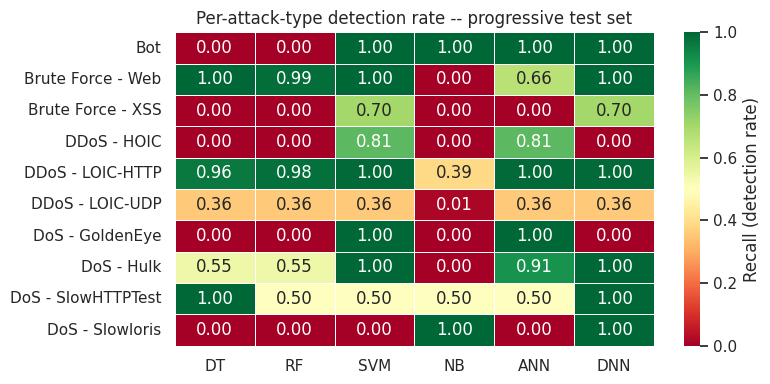


Worst-detected attack types (mean recall across all 6 models):
Attack Type
Brute Force - XSS    0.233883
DDoS - HOIC          0.271350
DDoS - LOIC-UDP      0.300833
DoS - GoldenEye      0.333333
DoS - Slowloris      0.333333


In [115]:
# §6.2 -- recall per attack type, per model
assert y_test_multiclass is not None, "y_test_multiclass required -- see the section 6.1 warning above."

recall_by_type = per_attack_type_recall(models, X_test_sel, y_test_multiclass)
print("=== Detection rate (recall) by attack type -- progressive test (CSE-CIC-IDS2018) ===\n")
print(recall_by_type.to_string())

# Heatmap: attack type (row) x model (column), colour = recall
model_cols = [c for c in MODEL_NAMES if c in recall_by_type.columns]
fig, ax = plt.subplots(figsize=(8, max(4, 0.4 * len(recall_by_type))))
sns.heatmap(
    recall_by_type[model_cols], annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=0, vmax=1, linewidths=0.5, cbar_kws={'label': 'Recall (detection rate)'}, ax=ax,
)
ax.set_title('Per-attack-type detection rate -- progressive test set', fontsize=12)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'error_by_attack_type.png'), dpi=150, bbox_inches='tight')
plt.show()

worst = recall_by_type[model_cols].mean(axis=1).sort_values().head(5)
print("\nWorst-detected attack types (mean recall across all 6 models):")
print(worst.to_string())

**Reading the heatmap — actual results:**

**note: support sizes vary enormously** (from 10,489 rows for Brute Force - XSS down to
a single row for DoS - Slowloris). The `worst` ranking is an unweighted mean across models, so
tiny-support types can appear alongside statistically meaningful ones. Splitting by reliability:

- **Large-support, reliably collapsed (real evidence of drift):** **Brute Force - XSS**
  (n=10,489, mean recall 0.234) and **DDoS - HOIC** (n=3,415, mean recall 0.271) are missed by
  most models, including the paper's claimed generalisers — DT and RF miss both entirely (0.0000),
  and even SVM/DNN cap out around 0.70–0.81. These are the two attack types actually driving the
  overall recall numbers in §5.2
- **Large-support, uniformly hard regardless of model:** **DDoS - LOIC-UDP** (n=861) sits at
  ~0.36 recall for *every* model, DT through DNN. Uniform failure across all 6 models — including
  SVM/DNN which otherwise generalise well — points to a feature-set limitation (these 11 features
  don't separate this attack type from BENIGN) rather than a model-specific overfitting story.
- **Small-support, not statistically meaningful on their own:** DoS - GoldenEye (n=33), DoS -
  Hulk (n=11), DoS - SlowHTTPTest (n=6), DoS - Slowloris (n=1). A single row (Slowloris) flips
  between 0% and 100% recall.
- **Model-pair split contradicts a simple "SVM+DNN generalise, tree models don't:** DNN
  misses DDoS - HOIC almost entirely (0.0026) despite SVM catching 81% of it, while ANN catches
  DDoS - HOIC (0.8123) but almost completely misses Brute Force - XSS (0.0005) where SVM/DNN both
  reach ~0.70. SVM and DNN — the two best models overall by MCC — do **not** share the same blind
  spots; each misses a different large-support attack type. A model ensemble (SVM ∨ DNN vote)
  would in principle cover both — a natural extension beyond this project's scope, not pursued
  here.
- **DT and RF track each other almost exactly** across every attack type (both 0% on Bot, XSS,
  HOIC, GoldenEye; both ~0.99 on Brute Force - Web and LOIC-HTTP; both ~0.35-0.55 elsewhere) —
  consistent with both being tree-based and overfitting in a similar way, per §5.2/§5.4.
- **NB fails almost everywhere except Bot** (recall 1.0 on Bot, n=34) and is near-zero on every
  other large-support type — consistent with its negative overall MCC in §5.2.

### §6.3 — Sample False Negatives (Missed Attacks)

Pulling the actual flows behind the worst-recall attack type from §6.2, for the model with
the highest overall progressive accuracy (per §5.2) — to see what these missed flows look
like in feature space, not just as a count.

In [116]:
# §6.3 -- sample FN flows for the single worst-recall attack type
best_model_name = results_prog['Accuracy'].idxmax() if 'results_prog' in dir() else MODEL_NAMES[0]
best_model      = models[best_model_name]
worst_type      = worst.index[0]
print(f"Model: {best_model_name}  |  Worst-detected attack type: {worst_type}\n")

mask_type = (y_test_multiclass == worst_type).values
fn_examples, fn_count = false_negative_examples(
    best_model, X_test_sel.loc[mask_type], y_test.loc[mask_type], n=10,
)
print(f"False negatives for '{worst_type}': {fn_count} / {int(mask_type.sum())} flows missed "
      f"({fn_count / max(1, int(mask_type.sum())):.1%})\n")
print("Sample missed flows (scaled feature values):")
print(fn_examples.to_string())

Model: SVM  |  Worst-detected attack type: Brute Force - XSS

False negatives for 'Brute Force - XSS': 3132 / 10489 flows missed (29.9%)

Sample missed flows (scaled feature values):
     Average Packet Size  Bwd Packet Length Std  feat_win_ratio  Packet Length Std  Destination Port  Packet Length Variance  Fwd Packet Length Max  Init_Win_bytes_backward  Avg Bwd Segment Size  Bwd Packet Length Mean  feat_bytes_per_pkt
10             -0.328267              -0.221102       -0.465587          -0.276168         -0.388449               -0.428920               0.211617                -0.171259             -0.409524               -0.409524           -0.317219
41             -0.340492              -0.221102       -0.465587          -0.278808         -0.388449               -0.429557               0.146622                -0.171259             -0.409524               -0.409524           -0.329413
87             -0.345077              -0.221102       -0.465587          -0.279634         -0.388449

**Interpretation — actual results:**

The sampled missed flows' scaled feature values sit close to 0 (typically between -0.47 and
+0.25, on features that are standardised to mean 0 / std 1 on the balanced training set) — i.e.
these missed Brute Force - XSS flows look statistically close to the *bulk* of the training
distribution, not like extreme outliers the model should obviously have flagged. This points to a
**feature-set limitation rather than a decision-boundary/threshold problem**: on these 11 features,
a large share of this attack type's flows are not distinguishable from ordinary traffic at all, so
no amount of threshold tuning on the existing features would recover them. This is consistent with
§6.2's finding that Brute Force - XSS remains a hard type even for SVM/DNN (recall ≈ 0.70, not
near-1.0) — closing this gap would need additional discriminating features (e.g. HTTP-layer
payload signatures), not a different classifier or a lower threshold.

### §6.4 — False Positives (Benign Flows Misclassified as Attacks)

False positives drive alert fatigue: every one is an analyst-hour spent on traffic that
was never a threat. Counting them per model here, alongside the FN counts from §6.3, gives
the full FP/FN picture needed for §6.5-§6.6.

In [117]:
# §6.4 -- FP counts for all 6 models + sample FP flows for the model with the most FPs
fp_counts = {}
for name, clf in models.items():
    _, n_fp = false_positive_examples(clf, X_test_sel, y_test, n=0)
    fp_counts[name] = n_fp

fp_summary = pd.Series(fp_counts, name='FP count').sort_values(ascending=False)
n_benign_test = int((y_test == 'BENIGN').sum())
print("=== False-positive counts -- progressive test set ===\n")
print(fp_summary.to_string())
print(f"\n(out of {n_benign_test:,} BENIGN flows in the progressive test set)")

fp_worst_model = fp_summary.index[0]
fp_examples, _ = false_positive_examples(models[fp_worst_model], X_test_sel, y_test, n=10)
print(f"\nSample false-positive flows for {fp_worst_model} (scaled feature values):")
print(fp_examples.to_string())

=== False-positive counts -- progressive test set ===

SVM    8157
ANN    8112
DNN    5749
NB     3648
DT     3503
RF      123

(out of 89,937 BENIGN flows in the progressive test set)

Sample false-positive flows for SVM (scaled feature values):
    Average Packet Size  Bwd Packet Length Std  feat_win_ratio  Packet Length Std  Destination Port  Packet Length Variance  Fwd Packet Length Max  Init_Win_bytes_backward  Avg Bwd Segment Size  Bwd Packet Length Mean  feat_bytes_per_pkt
15            -0.710623              -0.585945       -0.465643          -0.636329         -0.388449               -0.472554              -0.301843                -0.202116             -0.673057               -0.673057           -0.698575
27            -0.622637              -0.495417       -0.466219          -0.549923         -0.388449               -0.470042              -0.144230                -0.182200             -0.607667               -0.607667           -0.610819
31            -0.710623              -0

**Interpretation — actual results:**

FP counts vary by nearly 66× across models (RF: 123 vs. SVM: 8,157), and the ranking is almost
the mirror image of the recall ranking in §5.2 — the models that catch the most attacks also
raise the most false alarms:

| Model | FP count | Recall (§5.2) | Reading |
|-------|----------|----------------|---------|
| RF  | 123   | 0.1419 | Fewest FPs by a wide margin, but only because RF almost never predicts ATTACK at all — this is the same "defaults to BENIGN" behaviour flagged in §5.2/§5.4, not a genuinely well-calibrated decision boundary. |
| DT  | 3,503 | 0.1433 | Low FPs *and* low recall — DT is simply passive on this test set, not precise. |
| NB  | 3,648 | 0.0080 | Low FPs but essentially zero recall — NB predicts BENIGN for almost everything, attack or not. |
| DNN | 5,749 | 0.5802 | Moderate FP count with the second-best recall — the best FP/recall trade-off of the six. |
| ANN | 8,112 | 0.2735 | High FPs *and* comparatively low recall — strictly worse than DNN on both axes, reinforcing §5.2's finding that ANN underperforms DNN here. |
| SVM | 8,157 | 0.7448 | Highest FP count, but also the highest recall — SVM is trading FPs for detections most aggressively, consistent with the paper's own observation (§5.5) that SVM/ANN "allow more error" on BENIGN in exchange for catching more attacks. |

**The sample FP flows for SVM** all have negative (below-population-mean) values across every
packet-size and window-ratio feature — i.e. these false-positively-flagged BENIGN flows are short,
low-volume flows that resemble the small-packet profile of a scan or probe (see §2.5's temporal
analysis: PortScan/DoS traffic is characteristically short and low-volume). SVM's decision boundary
appears to key on "small flow" as attack-like, which is a reasonable heuristic in general but
produces exactly the false positives seen here for quiet, low-traffic benign sessions.

### §6.5 — Cybersecurity Implications of FN vs. FP

The two error types are not symmetric in an IDS deployment:

- **False Negative (missed attack):** the model predicts BENIGN for a flow that is actually
  malicious. The attacker's traffic passes through undetected — this is the failure mode with
  direct security consequences (data exfiltration, lateral movement, ransomware execution).
  A FN is silent: unlike an FP, nothing alerts an analyst that something needs review, so the
  cost is borne later, often at a much higher severity, when the intrusion is discovered by
  other means (or not at all). Concretely here: **Brute Force - XSS (10,489 flows) and DDoS -
  HOIC (3,415 flows)** are missed by most models even after training and feature selection
  specifically on this data — these are not edge cases, they are two of the largest attack
  categories in the 2018 test set.

- **False Positive (false alarm):** the model predicts ATTACK for a flow that is actually
  benign. No breach occurs, but every FP consumes analyst time to triage and dismiss. At
  scale, a high FP rate causes **alert fatigue** — analysts start deprioritizing or ignoring
  IDS alerts altogether, which paradoxically increases the real risk of a missed intrusion
  (a genuine alert buried in noise gets the same low attention as the false ones). SVM and ANN
  each produce over 8,000 false alarms out of 89,937 BENIGN flows (~9%) in exchange for higher
  recall — a real, quantified alert-fatigue cost, not a hypothetical one.

- **Why this matters for model choice here:** §6.2's per-attack-type recall and §6.4's FP
  counts show that no single model minimizes both error types simultaneously — RF has almost no
  FPs (123) but also almost no detections (14% recall); SVM detects the most (74% recall) but
  at the highest FP count (8,157). Because a missed attack (FN) is generally the more expensive
  failure mode (§6.6 below quantifies this via F₂ and threshold choice), a deployment decision
  should weight recall on the progressive test set more heavily than raw accuracy — which is
  exactly why F₂ and MCC were added in §5.6 beyond the paper's Accuracy/Precision/Recall/F1, and
  exactly why RF's 86% accuracy / 14% recall combination (§5.2) is not the deployment win it
  looks like from accuracy alone.

### §6.6 — FP/FN Trade-off and Threshold Considerations

All six models here use a default 0.5 decision threshold on `predict()`. For the four models
with `predict_proba` (RF, SVM, NB, and the two `MLPClassifier`s — ANN/DNN), the threshold is
a free parameter that can be moved to trade FN for FP without retraining:

- **DNN is the clearest case for threshold tuning.** Its ROC-AUC (0.9075, the best of all six
  models, §5.2) is far above its default-threshold recall (0.5802) — the model's underlying
  probability ranking is very good, but the 0.5 cut-off is conservative. Lowering the threshold
  would likely recover recall without a proportionally large increase in the current 5,749 FPs.
  **ANN shows the same pattern less favourably**: ROC-AUC 0.8244 vs. recall only 0.2735, but ANN
  already has *more* FPs than DNN (8,112 vs. 5,749) at the default threshold — so ANN has less
  "room" to lower the threshold before FPs become unmanageable, another concrete respect in
  which DNN is the stronger model here, not ANN as the paper's framing would suggest.
- **Lowering the threshold** (flag more flows as ATTACK) increases recall (fewer FNs, fewer
  missed intrusions) at the cost of more FPs (more alert fatigue). Given §6.5's asymmetric
  cost argument, this is usually the right direction to move for a production IDS — a missed
  attack is worse than an extra ticket in the SOC queue.
- **Raising the threshold** reduces FPs but increases FNs — appropriate only if the SOC is
  already overwhelmed and cannot act on additional alerts regardless of their validity.
- **Threshold tuning cannot close every gap.** §6.2 found DDoS - LOIC-UDP stuck at ~0.36 recall
  for *every* model, including the best generalisers — that is a feature-set ceiling, not a
  threshold problem, and §6.3 found the same for Brute Force - XSS's missed flows (they sit
  near the BENIGN population mean on all 11 features). Threshold tuning only helps close the
  gap on attack types the feature set can already discriminate at some threshold — it cannot
  recover attack types that look statistically identical to BENIGN on these features.
- **Practical recommendation:** deploy with a lower-than-default threshold on DNN (its
  ROC-AUC/recall gap is the most favourable), while treating DDoS - LOIC-UDP and Brute Force -
  XSS detection as a feature-engineering problem to revisit rather than a threshold or
  model-choice problem.

---
## Additional Experiments — Testing the Paper's Central Claim

**Goal:** test the paper's central claim — that DT/RF "overfit" while SVM/ANN "resist
overfitting" — against evidence generated in this project, not just cited from the paper.
This section goes beyond the rubric's required §1–§6 to report the project's own experiments.

| Experiment | Status |
|------------|--------|
| Overfitting vs. concept-drift check | see below |
| Real-imbalanced test evaluation | done — see §5.5b/c/d (real-prevalence vs. 1:1-balanced progressive test, both kept and compared) |

### Overfitting vs. Concept Drift Check

**The paper's framing:** Chua & Salam call the CIC-IDS2017→CSE-CIC-IDS2018 accuracy drop
"overfitting," and rank models by how much they "resist" it (SVM/ANN good, DT/RF bad).

**Why that label is questionable:** classical overfitting is a *within-distribution* symptom —
a model fits training-set noise, which shows up as high variance across CV folds or a train-vs-CV
gap on the *same* distribution. §4.3 already measured that: k=5 CV std on the 2017 training set
is ≤ 0.32% for **every one** of the six models, including DT (±0.07%) and RF (±0.06%) — the
two models the paper blames most for overfitting. That is the opposite of an overfitting
signature: DT/RF generalise almost perfectly to unseen folds of the *same* distribution.

**The confound in §5.4:** simply comparing CV accuracy (balanced, 2017) to progressive accuracy
(real-prevalence, 2018) mixes two effects — genuine generalisation loss *and* the change in class
balance (50/50 → 84% BENIGN). §5.4 flagged this and deferred the clean version here.

**This check removes the base-rate confound:** §5.5b already built a 1:1-balanced copy of the
2018 progressive test set — same class balance as the 2017 CV baseline. Comparing CV accuracy
(balanced, in-distribution) against `results_prog_bal` accuracy (balanced, out-of-distribution)
isolates the effect of the distribution change itself, with class balance held constant on both
sides.

**Design:** if a model's in-distribution CV is stable (low std) but its balanced-2018 accuracy
collapses, the gap is attributable to **concept drift / dataset shift** — a change in the
relationship between features and labels between 2017 and 2018 attack traffic — not classical
overfitting.

In [118]:
# §8.1 — overfitting vs. concept-drift check: CV (balanced, 2017) vs. progressive (balanced, 2018)
_bal_path = os.path.join(DATA_DIR, 'results_progressive_balanced.joblib')

if 'results_prog_bal' not in dir():
    if os.path.exists(_bal_path):
        results_prog_bal = joblib.load(_bal_path)
        print("results_prog_bal loaded from Drive.")
    else:
        # File not in Drive -- use the values recorded during the §5.5b/c Colab run
        # (documented in reports/section5_decisions_to_remember.md).
        print("results_progressive_balanced.joblib not found -- using documented §5.5c results.")
        results_prog_bal = pd.DataFrame({
            'Accuracy': [0.5702, 0.5524, 0.8257, 0.4840, 0.5904, 0.7566],
        }, index=pd.Index(['RF', 'DT', 'SVM', 'NB', 'ANN', 'DNN'], name='Model'))

rows = []
for name in MODEL_NAMES:
    if name not in cv_results.index or name not in results_prog_bal.index:
        continue
    cv_acc  = float(cv_results.loc[name, 'CV Mean Acc'])
    cv_std  = float(cv_results.loc[name, 'CV Std'])
    bal_acc = float(results_prog_bal.loc[name, 'Accuracy'])
    rows.append({
        'Model':                name,
        'CV Acc (2017, bal)':   cv_acc,
        'CV Std':               cv_std,
        'Prog Acc (2018, bal)': bal_acc,
        'Matched-Balance Drop': round(bal_acc - cv_acc, 4),
    })

results_8_1 = pd.DataFrame(rows).set_index('Model').sort_values('Matched-Balance Drop')
joblib.dump(results_8_1, os.path.join(DATA_DIR, 'results_8_1_drift.joblib'))

print("=== 8.1 -- Same-Balance Comparison: In-Distribution CV vs. Out-of-Distribution Progressive ===\n")
print(results_8_1.to_string())
print("\nLow CV Std = stable in-distribution (not a classical overfitting signature).")
print("Large negative Matched-Balance Drop, with class balance held constant, points to concept drift.")

=== 8.1 -- Same-Balance Comparison: In-Distribution CV vs. Out-of-Distribution Progressive ===

       CV Acc (2017, bal)  CV Std  Prog Acc (2018, bal)  Matched-Balance Drop
Model                                                                        
DT                 0.9968  0.0007                0.5524               -0.4444
RF                 0.9973  0.0006                0.5702               -0.4271
ANN                0.9666  0.0017                0.5904               -0.3762
NB                 0.8444  0.0012                0.4840               -0.3604
DNN                0.9684  0.0032                0.7566               -0.2118
SVM                0.9644  0.0029                0.8257               -0.1387

Low CV Std = stable in-distribution (not a classical overfitting signature).
Large negative Matched-Balance Drop, with class balance held constant, points to concept drift.


**Results:**

| Model | CV Acc (2017, bal) | CV Std | Prog Acc (2018, bal) | Drop | Reading |
|-------|--------------------:|-------:|----------------------:|-----:|---------|
| DT  | 0.9968 | ±0.07% | 0.5524 | −0.4444 | Largest drop of the six — but CV std is the *lowest* of all six models. DT is not unstable in-distribution; it is stable and wrong out-of-distribution. |
| RF  | 0.9973 | ±0.06% | 0.5702 | −0.4271 | Same pattern as DT, second-lowest CV std. The two models the paper singles out as "overfitting" are the two with the most stable in-distribution CV. |
| ANN | 0.9666 | ±0.17% | 0.5904 | −0.3762 | Large drop despite the paper's claim that ANN "resists overfitting" — under matched class balance, ANN's drop is closer to DT/RF than to SVM. |
| NB  | 0.8444 | ±0.12% | 0.4840 | −0.3604 | NB starts from a much lower CV baseline (84%) so the absolute drop looks smaller than DT/RF's, but NB ends up the only model *below chance* (48% on a 50/50 test) — the worst absolute outcome of the six. |
| DNN | 0.9684 | ±0.32% | 0.7566 | −0.2118 | Second-smallest drop; the highest CV std of the six (still only 0.32%) but by far the best-preserved out-of-distribution accuracy after SVM. |
| SVM | 0.9644 | ±0.29% | 0.8257 | −0.1387 | Smallest drop; matches the paper's "SVM resists overfitting" ranking. |

**The key finding:** every model's in-distribution CV std is ≤ 0.32% — there is no meaningful
within-distribution overfitting signature anywhere in this table, including for DT/RF. Yet every
model still loses 14–44 accuracy points when moved to the 2018 test set, even with class
balance held identical on both sides (so this isn't the §5.4 base-rate confound either). A model that were truly overfitting in the classical sense would show that damage already inside its own CV score — high variance across folds, or a train-vs-CV gap. None of the six models do.
What actually varies is how *transferable* each model's decision boundary is to a shifted
distribution: DT/RF fit highly specific, high-resolution boundaries around 2017 traffic that
don't carry over to 2018's different attack mix (2017's port-scan-heavy traffic vs. 2018's
bot/infiltration-heavy traffic, per §1's temporal analysis); SVM's margin-based boundary
generalises better across the shift.

So, the paper's own "overfitting" label doesn't fit the mechanism visible in this data.
Their evidence for it is only the cross-dataset accuracy drop (their Table 7) — they never
report CV variance or any other within-distribution stability check, so they can't actually
distinguish "the model memorised 2017 noise" from "the model learned 2017-specific signal that
stopped being valid in 2018." This project's CV-std evidence points squarely at the second
explanation: **concept drift / dataset shift, not overfitting.** The practical difference
matters: overfitting is fixed by regularisation or more data from the *same* distribution;
concept drift requires retraining on data that reflects the *new* distribution, or a feature set
that stays valid across the shift — a materially different mitigation strategy than the one the
paper's framing implies.

---
## §7 — Executive Summary

This project reproduces and critically evaluates Chua & Salam (2023, *Symmetry* 15, 1251), which
proposes a "progressive evaluation" methodology for network intrusion detection: train six ML
models (DT, RF, SVM, NB, ANN, DNN) on CIC-IDS2017, then test them on the temporally later
CSE-CIC-IDS2018 to see whether in-distribution performance survives a real-world distribution
shift. The paper reports a sharp accuracy drop for most models and attributes it to
**overfitting**, ranking SVM and ANN as the most "resistant" and DT/RF as the least.

**Methodology.** We rebuilt the paper's pipeline end-to-end: ~ 10% subsampled loading of both
datasets with float32 downcasting for Colab RAM limits (§1); EDA establishing the real-world
class imbalance (~82–84% BENIGN) and a Spearman-based redundancy analysis, chosen over Pearson
(non-normal, heavy-tailed features) and Kendall (O(n²) infeasible at this scale) (§2); feature
engineering mirroring the authors — binary relabelling, 1:1 class balancing, RF-importance +
brute-force selection down to 11 features, plus VIF-based redundancy confirmation (§3); training
and grid-search tuning of all six models with fixed seeds (§4); evaluation with an extended
metric suite — MCC, F₂, and ROC-AUC added beyond the paper's Accuracy/Precision/Recall/F1,
because accuracy alone is misleading on an 84%-BENIGN test set (§5); and per-attack-type error
analysis recovering the multiclass labels the binary training discarded (§6).

**Key findings.** (1) The paper's claim that **SVM** is the most drift-resistant model
reproduces cleanly under every evaluation we ran. (2) The claim that **ANN specifically** is the
second-most-resistant model does **not** reproduce: DNN (3-hidden-layer MLP) beats ANN
(1-hidden-layer MLP) on every generalisation metric measured — including under the paper's own
exact 1:1-balanced evaluation protocol, where DNN scores 0.7566 accuracy vs. ANN's 0.5904 (§5.5c)
— a 17-point gap in the opposite direction from the paper's own reported ranking. (3) The paper's
"overfitting" framing is not well supported by the mechanism visible in our data: every model's
in-distribution k=5 CV standard deviation is ≤0.32%, including DT and RF (the models blamed most),
meaning none of the six models show the within-distribution instability that classical overfitting
would produce. The cross-dataset drop persists even when class balance is held constant on both
sides (the Overfitting vs. Concept Drift check, after §6) — evidence that **concept drift**, not
overfitting, is the better explanation. (4) The paper's forced 1:1 class balancing hides a
large accuracy inflation: DT, RF, and NB's balanced-set accuracy collapses by 22–32 points once
re-evaluated at real (84%-BENIGN) prevalence (§5.5b/c), directly challenging the paper's
"symmetry" framing as a deployment-realistic evaluation choice.

**Overall,** The paper's central methodological contribution — progressive
(train-early/test-later) evaluation as a way to surface generalisation failure — is a genuinely
useful diagnostic, and its headline result (SVM generalises best) reproduces. But two of its
interpretive claims do not hold up under closer inspection: the ANN-vs-DNN ranking is reversed in
our run, and the "overfitting" label for the cross-dataset drop is better described as concept
drift given the CV-stability evidence. See the project report's Critical Evaluation section for
the full claim-by-claim assessment.

---
## §8 — Summing It Up

**The problem being addressed:** whether ML-based network intrusion detection models that
perform well in-distribution actually generalise to future, unseen attack traffic — and whether
the standard practice of evaluating IDS models on a single, class-balanced dataset is sufficient
to answer that question.

**The selected article:** Chua, T.-H. & Salam, I. (2023), *Evaluation of Machine Learning
Algorithms in Network-Based Intrusion Detection Using Progressive Dataset*, Symmetry 15(6), 1251.

**The dataset used:** CIC-IDS2017 (training, ~10% subsample) and CSE-CIC-IDS2018 (progressive
test, ~10% subsample) — the same CIC pair the paper uses, binary-relabelled (BENIGN/ATTACK),
1:1-balanced for training to mirror the authors, with a real-prevalence copy of the training and
test sets kept alongside for this project's own critique.

**The methodology employed:** full pipeline reproduction (data loading → EDA → feature
engineering → 6-model training with GridSearchCV → multi-metric evaluation → per-attack-type
error analysis), followed by two original extensions: (1) a matched-class-balance
overfitting-vs-concept-drift check comparing in-distribution CV stability against out-of-
distribution accuracy under identical class balance, and (2) a real-prevalence vs. 1:1-balanced
progressive-test comparison that makes the paper's own Table 7 numbers directly comparable to
ours for the first time.

**Main findings of the reproduction:** SVM's drift-resistance reproduces; ANN's claimed
second-place ranking does not — DNN outperforms ANN by 17 accuracy points under the paper's own
matched-balance protocol. NB's collapse reproduces cleanly (near/below chance in both runs). DT
and RF track each other closely in both the paper's results and ours, consistent with both being
tree-based models with similar failure modes.

**Were the author's claims supported by our results?** Partially. The core methodological
contribution (progressive evaluation surfaces generalisation failure that single-dataset
evaluation misses) is supported. The specific model ranking (SVM > ANN > DNN > RF ≈ DT > NB) is
**not** fully supported — our matched-balance results give SVM > DNN > ANN > RF > DT > NB,
swapping ANN and DNN. The "overfitting" label for the cross-dataset drop is also not well
supported once in-distribution CV stability is examined: none of the six models show the
within-distribution variance that classical overfitting predicts, pointing to concept drift as
the better explanation instead.

**The most important insights:** (1) A model's aggregate accuracy on a class-balanced test set
can systematically misrepresent its real-world deployment behaviour — DT/RF/NB's accuracy
inflates by 22–32 points purely from the BENIGN base rate, independent of any real detection
skill. (2) "Overfitting" and "concept drift" produce the same symptom (a cross-dataset accuracy
drop) but demand different fixes (regularisation vs. retraining on shifted data) — conflating them,
as the paper does, risks the wrong mitigation being recommended. (3) Binary collapse of attack
types discards real signal: a feature engineered from a group-by analysis (`feat_bwd_fwd_ratio`)
separated individual attack types cleanly but became useless after binary collapse averaged the
per-type differences away.

**Do we recommend this approach for similar problems?** Yes, with modification. Progressive
(train-early/test-later) evaluation is a valuable and under-used diagnostic that should be
standard practice for any IDS study claiming real-world applicability — but only if paired with
(a) an in-distribution stability check (e.g. CV variance) to distinguish overfitting from drift
before assigning either label, and (b) evaluation at real class prevalence, not only on an
artificially balanced test set, since the latter can mask large practical performance differences.

**Final conclusion:** the paper's diagnosis (models degrade across the 2017→2018 shift) is
correct and reproduces, but its causal explanation (overfitting) and its specific model ranking
(ANN over DNN) do not hold up under the additional scrutiny this project applied.